# NCXplain — Mutable Generator Costs
## Applied to 14-bus, IEEE 39-bus and IEEE 57-bus

**Structure**
- Section 0 — Imports and helpers
- Section 1 — Dataset loading
- Section 2 — Factual UC solve and foil candidate scan
- Section 3 — NCXplain for each grid with plots
- Section 4 — Cross-grid comparison


## 0 · Imports and helpers

In [1]:
import os, importlib, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import gurobipy as gp
from gurobipy import GRB

#os.environ["GRB_LICENSE_FILE"] = r"C:\Users\tomas\Desktop\gurobi.lic"
os.environ["GRB_LICENSE_FILE"] = r"C:\Users\PC3\Desktop\gurobi.lic"

import uc_pipeline, uc_master_relax_4b, uc_data_loader
importlib.reload(uc_pipeline)
importlib.reload(uc_data_loader)

from uc_pipeline import (
    NetworkUCData, IndexMap,
    build_index_map_network_uc,
    build_cost_vector_network_uc,
    default_initial_conditions,
    solve_uc_with_cost_4b,
)
from uc_data_loader import quick_setup
from b3_ncxplain import run_ncxplain_uc

# ── Data folder ───────────────────────────────────────────────────────────
#DATA_DIR = r"C:\Users\tomas\Documents\GitHub\Counterfactual-Explanations-for-optimization-problems\Mixed\UC-Experiments\Data"
DATA_DIR = r"C:\Users\PC3\Desktop\Counterfactual-Explanations-for-optimization-problems\Mixed\UC-Experiments\Data"
warnings.filterwarnings("ignore")
print("Imports OK")
print(f"Data directory: {DATA_DIR}")


Imports OK
Data directory: C:\Users\PC3\Desktop\Counterfactual-Explanations-for-optimization-problems\Mixed\UC-Experiments\Data


### Foil helpers and scanning utilities

In [2]:
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

from uc_pipeline import (
    solve_uc_with_cost_4b,
    build_cost_vector_network_uc,
    build_index_map_network_uc,
    default_initial_conditions,
)

# ── Foil helpers ──────────────────────────────────────────────────────────
def _as_list(x):
    if x is None: return []
    return list(x) if isinstance(x,(list,tuple,set)) else [x]

def _get_var(var, names):
    for n in names:
        if isinstance(var,dict) and n in var: return var[n]
        if hasattr(var,n): return getattr(var,n)
    raise KeyError(f"Could not find any of {names}")

def foil_force_on(g, times):
    times = _as_list(times)
    def _f(m, var, *a, **k):
        u = _get_var(var, ["u","U"])
        for t in times:
            m.addConstr(u[g,t]==1, name=f"foil_on_g{g}_t{t}")
    return _f

def foil_force_off(g, times):
    times = _as_list(times)
    def _f(m, var, *a, **k):
        u = _get_var(var, ["u","U"])
        for t in times:
            m.addConstr(u[g,t]==0, name=f"foil_off_g{g}_t{t}")
    return _f

def compose_foils(*foils):
    foils = [f for f in foils if f is not None]
    if not foils: return None
    def _all(m, var, *a, **k):
        for f in foils: f(m,var,*a,**k)
    return _all


# ── Foil candidate scanner ────────────────────────────────────────────────
# ── Cell: scan_foil_candidates (option 2: per-gen block length) ────────────

def scan_foil_candidates(data, idx, cvec, solF, zF,
                         window_size, per_bus_neutrality,
                         u_init, p_init, on_t, off_t,
                         min_gap=100, max_gap=1e7,
                         block_len_extra: int = 2,      # L in [UT, UT+block_len_extra]
                         min_pmin: float | None = None,
                         min_dispatch_mw: float | None = None,
                         max_ut: int = 8,
                         max_dt: int = 8):
    """
    Foil candidate scanner with per-generator minimum block length.

    For each generator g, the forced commitment window must be at least
    gen.UT periods long (minimum up-time) so the foil is physically feasible.
    Window lengths explored: [gen.UT, gen.UT + block_len_extra].

    This respects UC physical constraints and makes the foil academically
    defensible: every candidate corresponds to the shortest legally
    committable block for that generator.
    """
    # ── grid-specific floors ───────────────────────────────────────────────
    _pmin_floor = min((float(g.Pmin) for g in data.gens if float(g.Pmin) > 0), default=0.0)
    _all_pmin_zero = _pmin_floor == 0.0

    if min_pmin is None:
        min_pmin = 0.0 if _all_pmin_zero else _pmin_floor

    if min_dispatch_mw is None:
        if _all_pmin_zero:
            pmax_vals = [float(g.Pmax) for g in data.gens]
            min_dispatch_mw = 0.10 * float(np.median(pmax_vals))
        else:
            min_dispatch_mw = _pmin_floor

    nG = len(data.gens)
    T  = int(data.T)
    factual_obj = float(np.dot(cvec, zF))
    candidates  = []

    print(f"Scanning foil candidates  (factual obj={factual_obj:.0f})")
    print(f"  Pmin floor={min_pmin:.1f} MW  dispatch floor={min_dispatch_mw:.1f} MW"
          f"  max_ut={max_ut}  max_dt={max_dt}  block_len_extra={block_len_extra}")
    print(f"  {'g':>3}  {'Pmin':>6}  {'Pmax':>6}  {'UT':>3}  {'times':>17}"
          f"  {'gap':>8}  {'dispatch':>9}  {'type':>4}  verdict")
    print("  " + "-"*78)

    def get_blocks(hrs):
        blocks = []
        if hrs:
            s = p = hrs[0]
            for t in hrs[1:]:
                if t != p + 1: blocks.append((s, p)); s = t
                p = t
            blocks.append((s, p))
        return blocks

    for g in range(nG):
        gen = data.gens[g]
        pmin = float(gen.Pmin)
        pmax = float(gen.Pmax)
        ut   = int(gen.UT)
        dt   = int(gen.DT)

        if ut > max_ut or dt > max_dt:
            print(f"  {g:>3}  Pmin={pmin:>5.1f}  Pmax={pmax:>6.1f}  UT={ut:>3}"
                  f"  [skipped: UT={ut} > max_ut={max_ut} or DT={dt} > max_dt={max_dt}]")
            continue
        if pmin < min_pmin:
            print(f"  {g:>3}  Pmin={pmin:>5.1f}  Pmax={pmax:>6.1f}  UT={ut:>3}"
                  f"  [skipped: Pmin < {min_pmin:.1f}]")
            continue

        # per-generator window range: [UT, UT + block_len_extra]
        L_min = max(ut, 1)
        L_max = L_min + block_len_extra

        uF_g    = solF["u"][g]
        on_hrs  = [t for t in range(T) if int(round(uF_g[t])) == 1]
        off_hrs = [t for t in range(T) if int(round(uF_g[t])) == 0]

        for (t0, t1), ftype in ([(b, "ON")  for b in get_blocks(off_hrs)] +
                                 [(b, "OFF") for b in get_blocks(on_hrs)]):
            for L in range(L_min, L_max + 1):
                if t0 + L - 1 > t1:
                    continue
                times = list(range(t0, t0 + L))
                foil  = foil_force_on(g, times) if ftype == "ON" else foil_force_off(g, times)

                _, solT, zT = solve_uc_with_cost_4b(
                    data=data, idx=idx, cvec=cvec,
                    window_size=window_size, per_bus_neutrality=per_bus_neutrality,
                    u_init=u_init, p_init=p_init,
                    on_time_init=on_t, off_time_init=off_t,
                    extra_constr_fn=foil, output_flag=0,
                )
                if solT is None:
                    continue

                gap = float(np.dot(cvec, zT)) - factual_obj

                if ftype == "ON":
                    dispatch_check = sum(float(solT["p"][g, t]) for t in times)
                else:
                    dispatch_check = sum(float(solF["p"][g, t]) for t in times)

                meaningful = dispatch_check >= min_dispatch_mw
                ok = (min_gap < gap < max_gap) and meaningful

                verdict = ("good"      if ok             else
                           "hollow"    if not meaningful  else
                           "trivial"   if gap <= min_gap  else
                           "too large")

                print(f"  {g:>3}  {pmin:>6.1f}  {pmax:>6.1f}  {ut:>3}"
                      f"  t={str(times):>15}  {gap:>8.0f}"
                      f"  {dispatch_check:>9.1f}  {ftype:>4}  {verdict}")

                if ok:
                    candidates.append((gap, g, times, ftype))

    candidates.sort()
    if candidates:
        print(f"\n  Best: G{candidates[0][1]} {candidates[0][3]} "
              f"t={candidates[0][2]} gap={candidates[0][0]:.0f}")
    else:
        print("\n  No good candidates found.")
    return candidates                 


# ── Colour palette ────────────────────────────────────────────────────────
TECH_COLORS = ["#73726c","#378ADD","#BA7517","#7F77DD","#1D9E75",
               "#D85A30","#639922","#5DCAA5","#EF9F27","#E24B4A"]


# ── Commitment heatmap ────────────────────────────────────────────────────
def plot_commitment_heatmap(solF, solCF, DATA,
                             foil_g=None, foil_times=None, foil_type=None,
                             label=""):
    """
    Side-by-side commitment heatmap.
    solF  = sol_factual   (original costs, no foil)
    solCF = sol_foil      (original costs + foil constraint)
    Orange borders mark cells changed by the counterfactual.
    """
    nG = len(DATA.gens)
    T  = int(DATA.T)
    uF  = np.round(solF["u"]).astype(int)
    uCF = np.round(solCF["u"]).astype(int)

    fig, axes = plt.subplots(1, 2, figsize=(16, max(4, nG*0.65+2)), sharey=True)
    fig.suptitle(f"Unit Commitment — Factual vs Counterfactual   [{label}]",
                 fontsize=12, fontweight="bold")

    color_on   = plt.cm.Blues(0.55)
    color_off  = (0.94, 0.94, 0.97, 1.0)
    changed_ec = "#E86E00"

    for ax, u_mat, title, tcol in [
        (axes[0], uF,  "Factual",        "royalblue"),
        (axes[1], uCF, "Counterfactual", "crimson"),
    ]:
        ax.set_facecolor("white")
        for g in range(nG):
            for t in range(T):
                fc = color_on if u_mat[g,t] else color_off
                rect = mpatches.FancyBboxPatch(
                    (t-0.48, nG-g-1-0.48), 0.96, 0.96,
                    boxstyle="square,pad=0", lw=0.3,
                    edgecolor="#cccccc", facecolor=fc)
                ax.add_patch(rect)
                # Orange border for changed cells
                if uCF[g,t] != uF[g,t]:
                    brd = mpatches.FancyBboxPatch(
                        (t-0.48, nG-g-1-0.48), 0.96, 0.96,
                        boxstyle="square,pad=0", lw=2.2,
                        edgecolor=changed_ec, facecolor="none")
                    ax.add_patch(brd)
        # On-hour count on right
        for g in range(nG):
            ax.text(T+0.15, nG-g-1, f"{u_mat[g].sum()}h",
                    va="center", ha="left", fontsize=8, color="#444")
        ax.set_xlim(-0.5, T+2)
        ax.set_ylim(-0.5, nG-0.5)
        ax.set_yticks(range(nG))
        ax.set_yticklabels([f"Gen {nG-1-g}" for g in range(nG)], fontsize=8)
        ax.set_xlabel("Hour"); ax.set_xticks(range(0, T, 2))
        ax.set_title(title, fontsize=11, fontweight="bold", color=tcol)
        for sp in ax.spines.values(): sp.set_visible(False)
        ax.grid(False)

    patch_on  = mpatches.Patch(color=color_on,  label="ON")
    patch_off = mpatches.Patch(color=color_off, label="OFF",
                                edgecolor="#aaa", lw=0.5)
    patch_chg = mpatches.Patch(color="none", edgecolor=changed_ec,
                                lw=2, label="Changed by CE")
    axes[1].legend(handles=[patch_on, patch_off, patch_chg],
                   loc="lower right", fontsize=8, framealpha=0.9)

    n_changed = int(np.sum(uCF != uF))
    n_on2off  = int(np.sum((uF==1)&(uCF==0)))
    n_off2on  = int(np.sum((uF==0)&(uCF==1)))
    fig.text(0.5, 0.01,
             f"{n_changed} commitment cell(s) changed  "
             f"({n_off2on} OFF→ON, {n_on2off} ON→OFF)",
             ha="center", fontsize=9, color="#555")
    plt.tight_layout(rect=[0,0.04,1,0.96])
    plt.show()


# ── Full NCXplain results figure ─────────────────────────────────────────
def plot_ncxplain_results(DATA, out, label="",
                           foil_g=None, foil_times=None, foil_type=None):
    if out is None:
        print(f"[{label}] out is None"); return
    status = str(out.get("status","")).upper()
    if status != "OPTIMAL":
        print(f"[{label}] status={out.get('status')} — nothing to plot"); return

    solF    = out.get("sol_factual")
    # sol_foil = UC under original costs + foil constraint (the CE commitment)
    # sol_opt  = UC under new costs, no foil (the new optimal)
    solFoil = out.get("sol_foil")
    solOpt  = out.get("sol_opt")
    if solF is None:
        print(f"[{label}] missing sol_factual"); return

    nG  = len(DATA.gens)
    nR  = len(DATA.rens)
    T   = int(DATA.T)
    hrs = np.arange(T)
    foil_desc = (f"G{foil_g} {foil_type} at t={foil_times}"
                 if foil_g is not None else "")

    # ── Figure 1: dispatch + curtailment + shedding + cost changes ───────
    fig = plt.figure(figsize=(18, 12))
    fig.suptitle(f"NCXplain — {label}   [foil: {foil_desc}]",
                 fontsize=13, fontweight="bold")
    gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.52, wspace=0.30)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[1, 0])
    ax4 = fig.add_subplot(gs[1, 1])
    ax5 = fig.add_subplot(gs[2, :])

    # Dispatch panels — factual and foil (CE commitment)
    sol_cf_dispatch = solFoil if solFoil is not None else solOpt
    for ax, sol, title in [(ax1, solF, "Factual dispatch"),
                            (ax2, sol_cf_dispatch, "Counterfactual dispatch")]:
        if sol is None: ax.set_title(f"{title} (N/A)"); continue
        bottom = np.zeros(T)
        for g in range(nG):
            col = TECH_COLORS[g % len(TECH_COLORS)]
            ax.fill_between(hrs, bottom, bottom+sol["p"][g],
                            color=col, alpha=0.75, label=f"G{g}", step="mid")
            bottom += sol["p"][g]
        # Add renewable injection on top
        if nR > 0 and "curt" in sol:
            ren_inj = np.array([
                sum(float(DATA.rens[r].avail[t]) - sol["curt"][r,t]
                    for r in range(nR))
                for t in range(T)
            ])
            ax.fill_between(hrs, bottom, bottom+ren_inj,
                            color="#1D9E75", alpha=0.5, label="Renewable", step="mid")
            bottom += ren_inj
        # Total production line
        ax.plot(hrs, bottom, color="orange", lw=1.8, ls="-",
                label="Total production", zorder=5)
        ax.plot(hrs, DATA.demand.sum(axis=0), "k--", lw=1.5, label="Demand")
        ax.set_title(title, fontsize=10)
        ax.set_xlabel("Hour"); ax.set_ylabel("MW")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7, ncol=4, loc="upper left")

    # Curtailment
    curtF  = solF["curt"].sum(axis=0)  if nR>0 and "curt" in solF  else np.zeros(T)
    curtCF = (sol_cf_dispatch["curt"].sum(axis=0)
              if sol_cf_dispatch is not None and nR>0 and "curt" in sol_cf_dispatch
              else np.zeros(T))
    ax3.bar(hrs-0.2, curtF,  0.38, color="#D85A30", alpha=0.8, label="Factual")
    ax3.bar(hrs+0.2, curtCF, 0.38, color="#378ADD", alpha=0.8, label="Counterfactual")
    ax3.set_title("Curtailment per hour (MWh)", fontsize=10)
    ax3.set_xlabel("Hour"); ax3.set_ylabel("MWh")
    ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3, axis="y")
    ax3.text(0.98,0.97, f"F:{curtF.sum():.1f}  CF:{curtCF.sum():.1f} MWh",
             transform=ax3.transAxes, ha="right", va="top", fontsize=8)

    # Shedding
    shedF  = solF["shed"].sum(axis=0)  if "shed" in solF  else np.zeros(T)
    shedCF = (sol_cf_dispatch["shed"].sum(axis=0)
              if sol_cf_dispatch is not None and "shed" in sol_cf_dispatch
              else np.zeros(T))
    ax4.bar(hrs-0.2, shedF,  0.38, color="#BA7517", alpha=0.8, label="Factual")
    ax4.bar(hrs+0.2, shedCF, 0.38, color="#7F77DD", alpha=0.8, label="Counterfactual")
    ax4.set_title("Load shedding per hour (MWh)", fontsize=10)
    ax4.set_xlabel("Hour"); ax4.set_ylabel("MWh")
    ax4.legend(fontsize=8); ax4.grid(True, alpha=0.3, axis="y")
    ax4.text(0.98,0.97, f"F:{shedF.sum():.1f}  CF:{shedCF.sum():.1f} MWh",
             transform=ax4.transAxes, ha="right", va="top", fontsize=8)

    # Cost changes — capped to ±50% of original (no-load fix)
    fuel_orig = np.array([g.fuel_cost    for g in DATA.gens])
    nlod_orig = np.array([g.no_load_cost for g in DATA.gens])
    su_orig   = np.array([g.SU_cost      for g in DATA.gens])
    sd_orig   = np.array([g.SD_cost      for g in DATA.gens])
    fuel_new  = np.array(out.get("fuel_cost_new",    fuel_orig))
    nlod_new  = np.array(out.get("no_load_cost_new", nlod_orig))
    su_new    = np.array(out.get("su_cost_new",       su_orig))
    sd_new    = np.array(out.get("sd_cost_new",       sd_orig))

    x = np.arange(nG); w = 0.20
    df = (fuel_new - fuel_orig)/fuel_orig
    dn = (nlod_new - nlod_orig)/nlod_orig
    ds = (su_new   - su_orig)/su_orig
    dd = (sd_new   - sd_orig)/sd_orig
    ax5.bar(x-1.5*w, df, w, color="#D85A30", alpha=0.8, label="Fuel Δ% ($/MWh)")
    ax5.bar(x-0.5*w, dn, w, color="#378ADD", alpha=0.8, label="No-load Δ% ($/h)")
    ax5.bar(x+0.5*w, ds, w, color="#1D9E75", alpha=0.8, label="SU cost Δ% ($)")
    ax5.bar(x+1.5*w, dd, w, color="#BA7517", alpha=0.8, label="SD cost Δ% ($)")
    ax5.axhline(0, color="k", lw=0.8)
    ax5.set_title("Generator cost changes  (counterfactual − factual)/factual (%)", fontsize=10)
    ax5.set_xlabel("Generator"); ax5.set_ylabel("Δ cost")
    ax5.set_xticks(x)
    ax5.set_xticklabels(
        [f"G{g}\n${DATA.gens[g].fuel_cost:.0f}/MWh\nnl=${DATA.gens[g].no_load_cost:.0f}"
         for g in range(nG)], fontsize=7)
    ax5.legend(fontsize=8, ncol=4)
    ax5.grid(True, alpha=0.3, axis="y")
    plt.tight_layout(rect=[0,0,1,0.97])
    plt.show()

    # ── Figure 2: commitment heatmap (factual vs CE commitment=sol_foil) ─
    sol_for_heatmap = solFoil if solFoil is not None else sol_cf_dispatch
    if sol_for_heatmap is not None:
        plot_commitment_heatmap(solF, sol_for_heatmap, DATA,
                                 foil_g=foil_g, foil_times=foil_times,
                                 foil_type=foil_type, label=label)

    # ── Numeric summary ───────────────────────────────────────────────────
    print(f"\n{label} — cost changes:")
    print(f"  {'G':>3}  {'orig_fuel':>10}  {'Δfuel':>8}  {'orig_nlod':>10}  {'Δno-load':>10}  {'ΔSU':>10}  {'ΔSD':>10}")
    for g in range(nG):
        if abs(df[g])+abs(dn[g])+abs(ds[g])+abs(dd[g]) > 0.01:
            print(f"  {g:>3}  {fuel_orig[g]:>10.2f}  {df[g]:>8.2f}  "
                  f"{nlod_orig[g]:>10.2f}  {dn[g]:>10.2f}  {ds[g]:>10.2f}  {dd[g]:>10.2f}")

print("Plot functions defined")


def sanity_check(data, out, foil_g, foil_times, foil_type, label=""):
    from uc_pipeline import (
        solve_uc_with_cost_4b,
        build_cost_vector_network_uc,
        build_index_map_network_uc,
        default_initial_conditions,
    )

    print(f"\n  ── Sanity Check {label} ──────────────────────────────")

    nG  = len(data.gens)
    nR  = len(data.rens)
    nB  = int(data.nB)
    nL  = len(data.lines)
    T   = int(data.T)

    idx = build_index_map_network_uc(nG=nG, nR=nR, nB=nB, nL=nL, T=T, major="t")
    u_init, p_init, on_t, off_t = default_initial_conditions(data)

    fuel_new    = out["fuel_cost_new"]
    no_load_new = out["no_load_cost_new"]
    su_new      = out["su_cost_new"]
    sd_new      = out["sd_cost_new"]

    fuel_base    = np.array([float(g.fuel_cost)                       for g in data.gens])
    no_load_base = np.array([float(getattr(g, "no_load_cost",  0.0)) for g in data.gens])
    su_base      = np.array([float(getattr(g, "SU_cost",       0.0)) for g in data.gens])
    sd_base      = np.array([float(getattr(g, "SD_cost",       0.0)) for g in data.gens])

    # ── 1) Perturbation size ──────────────────────────────────────────────
    print(f"  {'g':>3}  {'param':>10}  {'base':>10}  {'new':>10}  {'Δabs':>10}  {'Δ%':>8}")
    print("  " + "-"*58)

    any_change = False
    for g in range(nG):
        for param, base_val, new_val in [
            ("fuel",    fuel_base[g],    fuel_new[g]),
            ("no_load", no_load_base[g], no_load_new[g]),
            ("SU",      su_base[g],      su_new[g]),
            ("SD",      sd_base[g],      sd_new[g]),
        ]:
            delta_abs = new_val - base_val
            delta_pct = (delta_abs / base_val * 100) if abs(base_val) > 1e-8 else float("nan")
            changed   = abs(delta_abs) > 1e-4
            marker    = " ◄" if changed else ""
            if changed:
                any_change = True
            print(f"  {g:>3}  {param:>10}  {base_val:>10.3f}  {new_val:>10.3f}"
                  f"  {delta_abs:>+10.3f}  {delta_pct:>7.2f}%{marker}")

    if not any_change:
        print("  (no parameters changed)")

    # ── 2) Optimality check ───────────────────────────────────────────────
    emission_rate = np.array([float(getattr(g, "emission_rate", 0.0)) for g in data.gens])
    curt_cost_mat = np.vstack([np.asarray(r.curt_cost, dtype=float)
                               for r in data.rens]) if nR > 0 else np.zeros((0, T))

    c_new = build_cost_vector_network_uc(
        idx=idx,
        fuel_cost=fuel_new,
        emission_rate=emission_rate,
        carbon_price=float(getattr(data, "carbon_price", 0.0)),
        no_load_cost=no_load_new,
        su_cost=su_new,
        sd_cost=sd_new,
        curt_cost=curt_cost_mat,
        pi_plus=np.asarray(data.pi_plus,  dtype=float),
        pi_minus=np.asarray(data.pi_minus, dtype=float),
        voll=float(getattr(data, "voll", 20000.0)),
    )

    # unconstrained solve under c_new
    _, solOpt_check, zOpt_check = solve_uc_with_cost_4b(
        data, idx, c_new,
        int(data.T), True,
        u_init, p_init, on_t, off_t,
        extra_constr_fn=None, output_flag=0,
    )

    if solOpt_check is None:
        print("  [OPTIMALITY] ✗  UC re-solve failed under perturbed costs.")
        return

    # check foil commitment is recovered
    u_opt = solOpt_check["u"]   # shape (nG, T) or dict
    recovered_on  = all(int(round(u_opt[foil_g, t])) == 1 for t in foil_times) if foil_type == "ON"  else True
    recovered_off = all(int(round(u_opt[foil_g, t])) == 0 for t in foil_times) if foil_type == "OFF" else True
    recovered     = recovered_on and recovered_off

    foil_cost = float(np.dot(c_new, out["z_foil"]))
    opt_cost  = float(np.dot(c_new, zOpt_check))
    gap       = foil_cost - opt_cost

    status_str = "✓  foil commitment recovered" if recovered else "✗  foil commitment NOT recovered"
    print(f"\n  [OPTIMALITY] {status_str}")
    print(f"               foil_cost={foil_cost:.2f}  opt_cost={opt_cost:.2f}  gap={gap:.4f}")
    if not recovered:
        for t in foil_times:
            print(f"               u[g={foil_g}, t={t}] = {u_opt[foil_g, t]:.3f}"
                  f"  (expected {'1' if foil_type=='ON' else '0'})")


Plot functions defined


In [3]:
import uc_pipeline, inspect
fns = [n for n in dir(uc_pipeline) if "solve" in n.lower() or "build" in n.lower() or "index" in n.lower()]
print(fns)

['IndexMap', 'build_cost_vector_network_uc', 'build_index_map_network_uc', 'build_network_uc_model', 'build_network_uc_model_4b', 'solve_uc_with_cost', 'solve_uc_with_cost_4b']


---
## Section 1 · Dataset loading

Load all seven IEEE benchmark grids from JSON files in `DATA_DIR`.
`quick_setup` returns `DATA, idx, cvec, b0, u_init, p_init, on_t, off_t` for each.

**Grids loaded:**

- IEEE 14-bus — primary  
- IEEE 39-bus (New England) — primary
- IEEE 57-bus — scaling



In [4]:
import os as _os
DATA_14, idx_14, cvec_14, b0_14, \
    u_init_14, p_init_14, on_t_14, off_t_14 = quick_setup(
    _os.path.join(DATA_DIR, "ieee14_enhanced.json"),
    carbon_price=0.0, curt_penalty=1000.0, voll=20_000.0, ren_scaling=0.5
)
print(f"Loaded [IEEE 14-bus]: {len(DATA_14.gens)} gens, "
      f"{len(DATA_14.lines)} lines, "
      f"peak={float(DATA_14.demand.sum(axis=0).max()):.0f} MW")


Loaded: ieee14_enhanced.json
  Buses: 14  |  Lines: 20  |  T: 24h
  Generators: 6  |  Renewables: 2
  System peak demand: 648.4 MW
  Total renewable capacity: 285.0 MW
  Carbon price: 0.0 $/tCO2
Loaded [IEEE 14-bus]: 6 gens, 20 lines, peak=648 MW


In [5]:
import os as _os
DATA_39, idx_39, cvec_39, b0_39, \
    u_init_39, p_init_39, on_t_39, off_t_39 = quick_setup(
    _os.path.join(DATA_DIR, "ieee39_newengland.json"),
    carbon_price=0.0, curt_penalty=1000.0, voll=20_000.0,ren_scaling=0.5
)
print(f"Loaded [IEEE 39-bus (New England)]: {len(DATA_39.gens)} gens, "
      f"{len(DATA_39.lines)} lines, "
      f"peak={float(DATA_39.demand.sum(axis=0).max()):.0f} MW")


Loaded: ieee39_newengland.json
  Buses: 39  |  Lines: 46  |  T: 24h
  Generators: 10  |  Renewables: 4
  System peak demand: 2656.4 MW
  Total renewable capacity: 950.0 MW
  Carbon price: 0.0 $/tCO2
Loaded [IEEE 39-bus (New England)]: 10 gens, 46 lines, peak=2656 MW


In [6]:
import os as _os
DATA_57, idx_57, cvec_57, b0_57, \
    u_init_57, p_init_57, on_t_57, off_t_57 = quick_setup(
    _os.path.join(DATA_DIR, "ieee57_uc_matpower.json"),
    carbon_price=0.0, curt_penalty=1000.0, voll=20_000.0,ren_scaling=0.5
)
print(f"Loaded [IEEE 57-bus]: {len(DATA_57.gens)} gens, "
      f"{len(DATA_57.lines)} lines, "
      f"peak={float(DATA_57.demand.sum(axis=0).max()):.0f} MW")


Loaded: ieee57_uc_matpower.json
  Buses: 57  |  Lines: 76  |  T: 24h
  Generators: 8  |  Renewables: 5
  System peak demand: 1000.0 MW
  Total renewable capacity: 488.0 MW
  Carbon price: 0.0 $/tCO2
Loaded [IEEE 57-bus]: 8 gens, 76 lines, peak=1000 MW


In [7]:
print(type(DATA_57.gens[0]))
print(DATA_57.gens[0].__dict__)
print(type(DATA_57.lines[0]))
print(DATA_57.lines[0].__dict__)

<class 'uc_pipeline.Generator'>
{'bus': 0, 'Pmin': 0.0, 'Pmax': 575.0, 'RU': 172.0, 'RD': 172.0, 'UT': 8, 'DT': 8, 'SU_cost': 5750.0, 'SD_cost': 1150.0, 'no_load_cost': 1265.0, 'fuel_cost': 61.0, 'emission_rate': 0.9}
<class 'uc_pipeline.Line'>
{'fr': 0, 'to': 1, 'b': 120.481928, 'fmax': 250.0}


In [8]:
for g, gen in enumerate(DATA_39.gens):
    print(f"g={g}  Pmin={gen.Pmin}  Pmax={gen.Pmax}  UT={gen.UT}  DT={gen.DT}")

g=0  Pmin=200.0  Pmax=1040.0  UT=24  DT=24
g=1  Pmin=100.0  Pmax=500.0  UT=8  DT=6
g=2  Pmin=80.0  Pmax=650.0  UT=8  DT=6
g=3  Pmin=50.0  Pmax=632.0  UT=3  DT=2
g=4  Pmin=50.0  Pmax=508.0  UT=3  DT=2
g=5  Pmin=40.0  Pmax=650.0  UT=3  DT=2
g=6  Pmin=100.0  Pmax=560.0  UT=6  DT=5
g=7  Pmin=0.0  Pmax=540.0  UT=1  DT=1
g=8  Pmin=0.0  Pmax=830.0  UT=1  DT=1
g=9  Pmin=400.0  Pmax=1100.0  UT=24  DT=24


In [9]:
for g, gen in enumerate(DATA_57.gens):
    print(f"g={g}  Pmin={gen.Pmin}  Pmax={gen.Pmax}  UT={gen.UT}  DT={gen.DT}")

g=0  Pmin=0.0  Pmax=575.0  UT=8  DT=8
g=1  Pmin=0.0  Pmax=100.0  UT=6  DT=6
g=2  Pmin=0.0  Pmax=140.0  UT=6  DT=6
g=3  Pmin=0.0  Pmax=100.0  UT=3  DT=3
g=4  Pmin=0.0  Pmax=60.0  UT=3  DT=3
g=5  Pmin=0.0  Pmax=50.0  UT=3  DT=3
g=6  Pmin=0.0  Pmax=155.0  UT=6  DT=6
g=7  Pmin=0.0  Pmax=250.0  UT=4  DT=4


---
## Section 2 · Factual UC solve and foil candidate scan

For each grid: solve the plain UC, then scan flexible generators
(UT=DT=1) to find the best foil — an OFF-block where forcing the
unit ON creates a non-trivial cost increase.

"Foil windows are constrained to a minimum length equal to the generator's minimum up-time UT, ensuring every candidate corresponds to a physically feasible commitment sequence under the UC constraints."


### 2.2 · IEEE 14-bus

In [10]:
# ── Factual solve — IEEE 14-bus ──────────────────────────────────────────
_, solF_14, zF_14 = solve_uc_with_cost_4b(
    data=DATA_14, idx=idx_14, cvec=cvec_14,
    window_size=int(DATA_14.T), per_bus_neutrality=True,
    u_init=u_init_14, p_init=p_init_14,
    on_time_init=on_t_14, off_time_init=off_t_14,
    output_flag=0,
)
assert solF_14 is not None, "Factual solve failed for IEEE 14-bus"

factual_obj_14 = float(np.dot(cvec_14, zF_14))
flexible_14 = [g for g,gen in enumerate(DATA_14.gens) if gen.UT<=1 and gen.DT<=1]
print(f"IEEE 14-bus  |  factual obj = {factual_obj_14:.0f}")
print(f"  Generators: {len(DATA_14.gens)}  "
      f"Flexible (UT=DT=1): {len(flexible_14)} -> {flexible_14}")
print("  On-hours per generator:")
for g, gen in enumerate(DATA_14.gens):
    on_h = int(np.sum(np.round(solF_14["u"][g])))
    print(f"    G{g}: {on_h:>3}h  UT={gen.UT} DT={gen.DT}  "
          f"Pmax={gen.Pmax:.0f} MW  fuel=${gen.fuel_cost}/MWh")


Set parameter Username
Set parameter LicenseID to value 2794356
Academic license - for non-commercial use only - expires 2027-03-18
IEEE 14-bus  |  factual obj = 522366
  Generators: 6  Flexible (UT=DT=1): 2 -> [3, 5]
  On-hours per generator:
    G0:  24h  UT=6 DT=5  Pmax=332 MW  fuel=$34.0/MWh
    G1:  17h  UT=3 DT=2  Pmax=140 MW  fuel=$52.0/MWh
    G2:  24h  UT=4 DT=3  Pmax=100 MW  fuel=$40.0/MWh
    G3:  24h  UT=1 DT=1  Pmax=80 MW  fuel=$85.0/MWh
    G4:   0h  UT=12 DT=12  Pmax=200 MW  fuel=$8.0/MWh
    G5:   3h  UT=1 DT=1  Pmax=50 MW  fuel=$130.0/MWh


In [11]:
# ── Cell: 14-bus scan ─────────────────────────────────────────────────────
# g=3: UT=1 → windows [1, 1+2] = lengths 1,2,3
# g=5: Pmin=0 → skipped by floor filter
candidates_14 = scan_foil_candidates(
    DATA_14, idx_14, cvec_14, solF_14, zF_14,
    window_size=int(DATA_14.T), per_bus_neutrality=True,
    u_init=u_init_14, p_init=p_init_14, on_t=on_t_14, off_t=off_t_14,
    max_ut=1, max_dt=1,
)
if candidates_14:
    _, foil_g_14, foil_times_14, foil_type_14 = candidates_14[0]
    foil_14 = foil_force_off(foil_g_14, foil_times_14) if foil_type_14 == "OFF" \
              else foil_force_on(foil_g_14, foil_times_14)
    print(f"Selected foil for IEEE 14-bus: G{foil_g_14} {foil_type_14}"
          f" at t={foil_times_14}  gap={candidates_14[0][0]:.0f}")
else:
    print("No suitable foil found for IEEE 14-bus")
    foil_14 = None

Scanning foil candidates  (factual obj=522366)
  Pmin floor=10.0 MW  dispatch floor=10.0 MW  max_ut=1  max_dt=1  block_len_extra=2
    g    Pmin    Pmax   UT              times       gap   dispatch  type  verdict
  ------------------------------------------------------------------------------
    0  Pmin= 60.0  Pmax= 332.0  UT=  6  [skipped: UT=6 > max_ut=1 or DT=5 > max_dt=1]
    1  Pmin= 30.0  Pmax= 140.0  UT=  3  [skipped: UT=3 > max_ut=1 or DT=2 > max_dt=1]
    2  Pmin= 25.0  Pmax= 100.0  UT=  4  [skipped: UT=4 > max_ut=1 or DT=3 > max_dt=1]
    3    10.0    80.0    1  t=            [0]    461456       80.0   OFF  good
    3    10.0    80.0    1  t=         [0, 1]    464513      157.0   OFF  good
    3    10.0    80.0    1  t=      [0, 1, 2]    466181      199.6   OFF  good
    4  Pmin= 80.0  Pmax= 200.0  UT= 12  [skipped: UT=12 > max_ut=1 or DT=12 > max_dt=1]
    5  Pmin=  0.0  Pmax=  50.0  UT=  1  [skipped: Pmin < 10.0]

  Best: G3 OFF t=[0] gap=461456
Selected foil for IEEE 14-b

### 2.3 · IEEE 39-bus

In [12]:
# ── Factual solve — IEEE 39-bus ──────────────────────────────────────────
_, solF_39, zF_39 = solve_uc_with_cost_4b(
    data=DATA_39, idx=idx_39, cvec=cvec_39,
    window_size=int(DATA_39.T), per_bus_neutrality=True,
    u_init=u_init_39, p_init=p_init_39,
    on_time_init=on_t_39, off_time_init=off_t_39,
    output_flag=0,
)
assert solF_39 is not None, "Factual solve failed for IEEE 39-bus"

factual_obj_39 = float(np.dot(cvec_39, zF_39))
flexible_39 = [g for g,gen in enumerate(DATA_39.gens) if gen.UT<=1 and gen.DT<=1]
print(f"IEEE 39-bus  |  factual obj = {factual_obj_39:.0f}")
print(f"  Generators: {len(DATA_39.gens)}  "
      f"Flexible (UT=DT=1): {len(flexible_39)} -> {flexible_39}")
print("  On-hours per generator:")
for g, gen in enumerate(DATA_39.gens):
    on_h = int(np.sum(np.round(solF_39["u"][g])))
    print(f"    G{g}: {on_h:>3}h  UT={gen.UT} DT={gen.DT}  "
          f"Pmax={gen.Pmax:.0f} MW  fuel=${gen.fuel_cost}/MWh")


IEEE 39-bus  |  factual obj = 13486642
  Generators: 10  Flexible (UT=DT=1): 2 -> [7, 8]
  On-hours per generator:
    G0:   0h  UT=24 DT=24  Pmax=1040 MW  fuel=$7.0/MWh
    G1:   0h  UT=8 DT=6  Pmax=500 MW  fuel=$32.0/MWh
    G2:  11h  UT=8 DT=6  Pmax=650 MW  fuel=$30.0/MWh
    G3:   0h  UT=3 DT=2  Pmax=632 MW  fuel=$48.0/MWh
    G4:   0h  UT=3 DT=2  Pmax=508 MW  fuel=$50.0/MWh
    G5:  12h  UT=3 DT=2  Pmax=650 MW  fuel=$46.0/MWh
    G6:  14h  UT=6 DT=5  Pmax=560 MW  fuel=$33.0/MWh
    G7:  24h  UT=1 DT=1  Pmax=540 MW  fuel=$2.0/MWh
    G8:  24h  UT=1 DT=1  Pmax=830 MW  fuel=$2.5/MWh
    G9:   0h  UT=24 DT=24  Pmax=1100 MW  fuel=$6.5/MWh


In [13]:
# ── Cell: 39-bus scan ─────────────────────────────────────────────────────
# g=3,4,5: UT=3,DT=2 → windows [3, 3+2] = lengths 3,4,5
# g=7,8:   Pmin=0 → skipped by floor filter
candidates_39 = scan_foil_candidates(
    DATA_39, idx_39, cvec_39, solF_39, zF_39,
    window_size=int(DATA_39.T), per_bus_neutrality=True,
    u_init=u_init_39, p_init=p_init_39, on_t=on_t_39, off_t=off_t_39,
    max_ut=3, max_dt=2,
)
if candidates_39:
    _, foil_g_39, foil_times_39, foil_type_39 = candidates_39[0]
    foil_39 = foil_force_off(foil_g_39, foil_times_39) if foil_type_39 == "OFF" \
              else foil_force_on(foil_g_39, foil_times_39)
    print(f"Selected foil for IEEE 39-bus: G{foil_g_39} {foil_type_39}"
          f" at t={foil_times_39}  gap={candidates_39[0][0]:.0f}")
else:
    print("No suitable foil found for IEEE 39-bus")
    foil_39 = None


Scanning foil candidates  (factual obj=13486642)
  Pmin floor=40.0 MW  dispatch floor=40.0 MW  max_ut=3  max_dt=2  block_len_extra=2
    g    Pmin    Pmax   UT              times       gap   dispatch  type  verdict
  ------------------------------------------------------------------------------
    0  Pmin=200.0  Pmax=1040.0  UT= 24  [skipped: UT=24 > max_ut=3 or DT=24 > max_dt=2]
    1  Pmin=100.0  Pmax= 500.0  UT=  8  [skipped: UT=8 > max_ut=3 or DT=6 > max_dt=2]
    2  Pmin= 80.0  Pmax= 650.0  UT=  8  [skipped: UT=8 > max_ut=3 or DT=6 > max_dt=2]
    3    50.0   632.0    3  t=      [0, 1, 2]      1369      249.3    ON  good
    3    50.0   632.0    3  t=   [0, 1, 2, 3]      4844      299.3    ON  good
    3    50.0   632.0    3  t=[0, 1, 2, 3, 4]      8319      349.3    ON  good
    4    50.0   508.0    3  t=      [0, 1, 2]        67      249.3    ON  trivial
    4    50.0   508.0    3  t=   [0, 1, 2, 3]      3442      299.3    ON  good
    4    50.0   508.0    3  t=[0, 1, 2, 3, 4] 

### 2.5 · IEEE 57-bus

In [14]:
# ── Factual solve — IEEE 57-bus ──────────────────────────────────────────
_, solF_57, zF_57 = solve_uc_with_cost_4b(
    data=DATA_57, idx=idx_57, cvec=cvec_57,
    window_size=int(DATA_57.T), per_bus_neutrality=True,
    u_init=u_init_57, p_init=p_init_57,
    on_time_init=on_t_57, off_time_init=off_t_57,
    output_flag=0,
)
assert solF_57 is not None, "Factual solve failed for IEEE 57-bus"

factual_obj_57 = float(np.dot(cvec_57, zF_57))
flexible_57 = [g for g,gen in enumerate(DATA_57.gens) if gen.UT<=1 and gen.DT<=1]
print(f"IEEE 57-bus  |  factual obj = {factual_obj_57:.0f}")
print(f"  Generators: {len(DATA_57.gens)}  "
      f"Flexible (UT=DT=1): {len(flexible_57)} -> {flexible_57}")
print("  On-hours per generator:")
for g, gen in enumerate(DATA_57.gens):
    on_h = int(np.sum(np.round(solF_57["u"][g])))
    print(f"    G{g}: {on_h:>3}h  UT={gen.UT} DT={gen.DT}  "
          f"Pmax={gen.Pmax:.0f} MW  fuel=${gen.fuel_cost}/MWh")


IEEE 57-bus  |  factual obj = 3794382
  Generators: 8  Flexible (UT=DT=1): 0 -> []
  On-hours per generator:
    G0:  24h  UT=8 DT=8  Pmax=575 MW  fuel=$61.0/MWh
    G1:   6h  UT=6 DT=6  Pmax=100 MW  fuel=$63.7/MWh
    G2:   6h  UT=6 DT=6  Pmax=140 MW  fuel=$63.7/MWh
    G3:  24h  UT=3 DT=3  Pmax=100 MW  fuel=$49.0/MWh
    G4:  24h  UT=3 DT=3  Pmax=60 MW  fuel=$49.0/MWh
    G5:   6h  UT=3 DT=3  Pmax=50 MW  fuel=$69.5/MWh
    G6:   6h  UT=6 DT=6  Pmax=155 MW  fuel=$63.7/MWh
    G7:  24h  UT=4 DT=4  Pmax=250 MW  fuel=$49.0/MWh


In [15]:
# ── Cell: 57-bus scan ─────────────────────────────────────────────────────
# All Pmin=0 → min_pmin disabled, min_dispatch_mw = 10% median Pmax (~12 MW)
# UT in [3,8] → windows start at gen.UT, solver rejects infeasible ones
candidates_57 = scan_foil_candidates(
    DATA_57, idx_57, cvec_57, solF_57, zF_57,
    window_size=int(DATA_57.T), per_bus_neutrality=True,
    u_init=u_init_57, p_init=p_init_57, on_t=on_t_57, off_t=off_t_57,
    max_ut=8, max_dt=8,
)
if candidates_57:
    _, foil_g_57, foil_times_57, foil_type_57 = candidates_57[0]
    foil_57 = foil_force_off(foil_g_57, foil_times_57) if foil_type_57 == "OFF" \
              else foil_force_on(foil_g_57, foil_times_57)
    print(f"Selected foil for IEEE 57-bus: G{foil_g_57} {foil_type_57}"
          f" at t={foil_times_57}  gap={candidates_57[0][0]:.0f}")
else:
    print("No suitable foil found for IEEE 57-bus")
    foil_57 = None

Scanning foil candidates  (factual obj=3794382)
  Pmin floor=0.0 MW  dispatch floor=12.0 MW  max_ut=8  max_dt=8  block_len_extra=2
    g    Pmin    Pmax   UT              times       gap   dispatch  type  verdict
  ------------------------------------------------------------------------------
    0     0.0   575.0    8  t=[0, 1, 2, 3, 4, 5, 6, 7]   4103704     1494.2   OFF  good
    0     0.0   575.0    8  t=[0, 1, 2, 3, 4, 5, 6, 7, 8]   4104733     1755.6   OFF  good
    0     0.0   575.0    8  t=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]   4106800     2035.8   OFF  good
    1     0.0   100.0    6  t=[6, 7, 8, 9, 10, 11]      3240        0.0    ON  hollow
    1     0.0   100.0    6  t=[6, 7, 8, 9, 10, 11, 12]      3780        0.0    ON  hollow
    1     0.0   100.0    6  t=[6, 7, 8, 9, 10, 11, 12, 13]      4320        0.0    ON  hollow
    1     0.0   100.0    6  t=[0, 1, 2, 3, 4, 5]    594333       30.0   OFF  good
    2     0.0   140.0    6  t=[6, 7, 8, 9, 10, 11]      4536        0.0    ON  ho

---
## Section 3 · NCXplain — minimum cost-change counterfactual

For each grid, NCXplain finds the **minimum change to generator
cost parameters** (fuel cost, no-load cost, SU/SD costs) such
that the foil becomes the cost-optimal commitment decision.


### 3.2 · IEEE 14-bus

In [16]:
# ── Cell: run NCXplain for all good 14-bus foil candidates ────────────────

assert candidates_14, "Run Section 2 first for IEEE 14-bus"

results_14 = []
for rank, (gap, foil_g, foil_times, foil_type) in enumerate(candidates_14):
    foil_fn = foil_force_off(foil_g, foil_times) if foil_type == "OFF" \
              else foil_force_on(foil_g, foil_times)

    print(f"\n{'='*60}")
    print(f"Rank {rank}  G{foil_g} {foil_type} t={foil_times}  gap={gap:.0f}")
    print(f"{'='*60}")

    out = run_ncxplain_uc(
        data=DATA_14,
        window_size=int(DATA_14.T),
        per_bus_neutrality=True,
        foil_fn=foil_fn,
        mutables={"gen_costs"},
        bounds={"fuel":    (0, 500),
                "no_load": (0, 5000),
                "su":      (0, 100_000),
                "sd":      (0, 100_000)},
        perturbation_beta=0.6,
        weights={"gen_costs": 1.0},
        verbose=True,
    )

    results_14.append({
        "rank": rank, "gap": gap,
        "foil_g": foil_g, "foil_times": foil_times, "foil_type": foil_type,
        "status": out["status"], "out": out,
    })
    print(f"  → status: {out['status']}")

    if str(out.get("status", "")).upper() == "OPTIMAL":
        sanity_check(
            DATA_14, out,
            foil_g=foil_g, foil_times=foil_times, foil_type=foil_type,
            label=f"Rank {rank}  G{foil_g} {foil_type} t={foil_times}",
        )
        print(f"\nIEEE 14-bus — output keys: {list(out.keys())}")
        plot_ncxplain_results(
            DATA_14, out,
            label=f"IEEE 14-bus  Rank {rank}  G{foil_g} {foil_type} t={foil_times}",
            foil_g=foil_g, foil_times=foil_times, foil_type=foil_type,
        )

# ── summary ───────────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"IEEE 14-bus  NCXplain summary  ({len(results_14)} foils)")
print(f"{'='*60}")
for r in results_14:
    print(f"  Rank {r['rank']}  G{r['foil_g']} {r['foil_type']}"
          f"  t={r['foil_times']}  gap={r['gap']:.0f}  →  {r['status']}")


Rank 0  G3 OFF t=[0]  gap=461456
  → status: MP_INFEASIBLE

Rank 1  G3 OFF t=[0, 1]  gap=464513
  → status: MP_INFEASIBLE

Rank 2  G3 OFF t=[0, 1, 2]  gap=466181
  → status: MP_INFEASIBLE

IEEE 14-bus  NCXplain summary  (3 foils)
  Rank 0  G3 OFF  t=[0]  gap=461456  →  MP_INFEASIBLE
  Rank 1  G3 OFF  t=[0, 1]  gap=464513  →  MP_INFEASIBLE
  Rank 2  G3 OFF  t=[0, 1, 2]  gap=466181  →  MP_INFEASIBLE


### 3.3 · IEEE 39-bus


Rank 0  G5 ON t=[17, 18, 19]  gap=1050
[NCX it=01] gap=3.72529e-09 | stop_tol=13.5 | MP_obj=4.77273 | foil_cost=13512523.70 | opt_cost=13512523.70
  → status: OPTIMAL

  ── Sanity Check Rank 0  G5 ON t=[17, 18, 19] ──────────────────────────────
    g       param        base         new        Δabs        Δ%
  ----------------------------------------------------------
    0        fuel       7.000       7.000      +0.000     0.00%
    0     no_load   15000.000   15000.000      +0.000     0.00%
    0          SU  150000.000  150000.000      +0.000     0.00%
    0          SD   30000.000   30000.000      +0.000     0.00%
    1        fuel      32.000      32.000      +0.000     0.00%
    1     no_load    3000.000    3000.000      +0.000     0.00%
    1          SU   25000.000   25000.000      +0.000     0.00%
    1          SD    5000.000    5000.000      +0.000     0.00%
    2        fuel      30.000      30.000      +0.000     0.00%
    2     no_load    3500.000    3500.000      +0.00

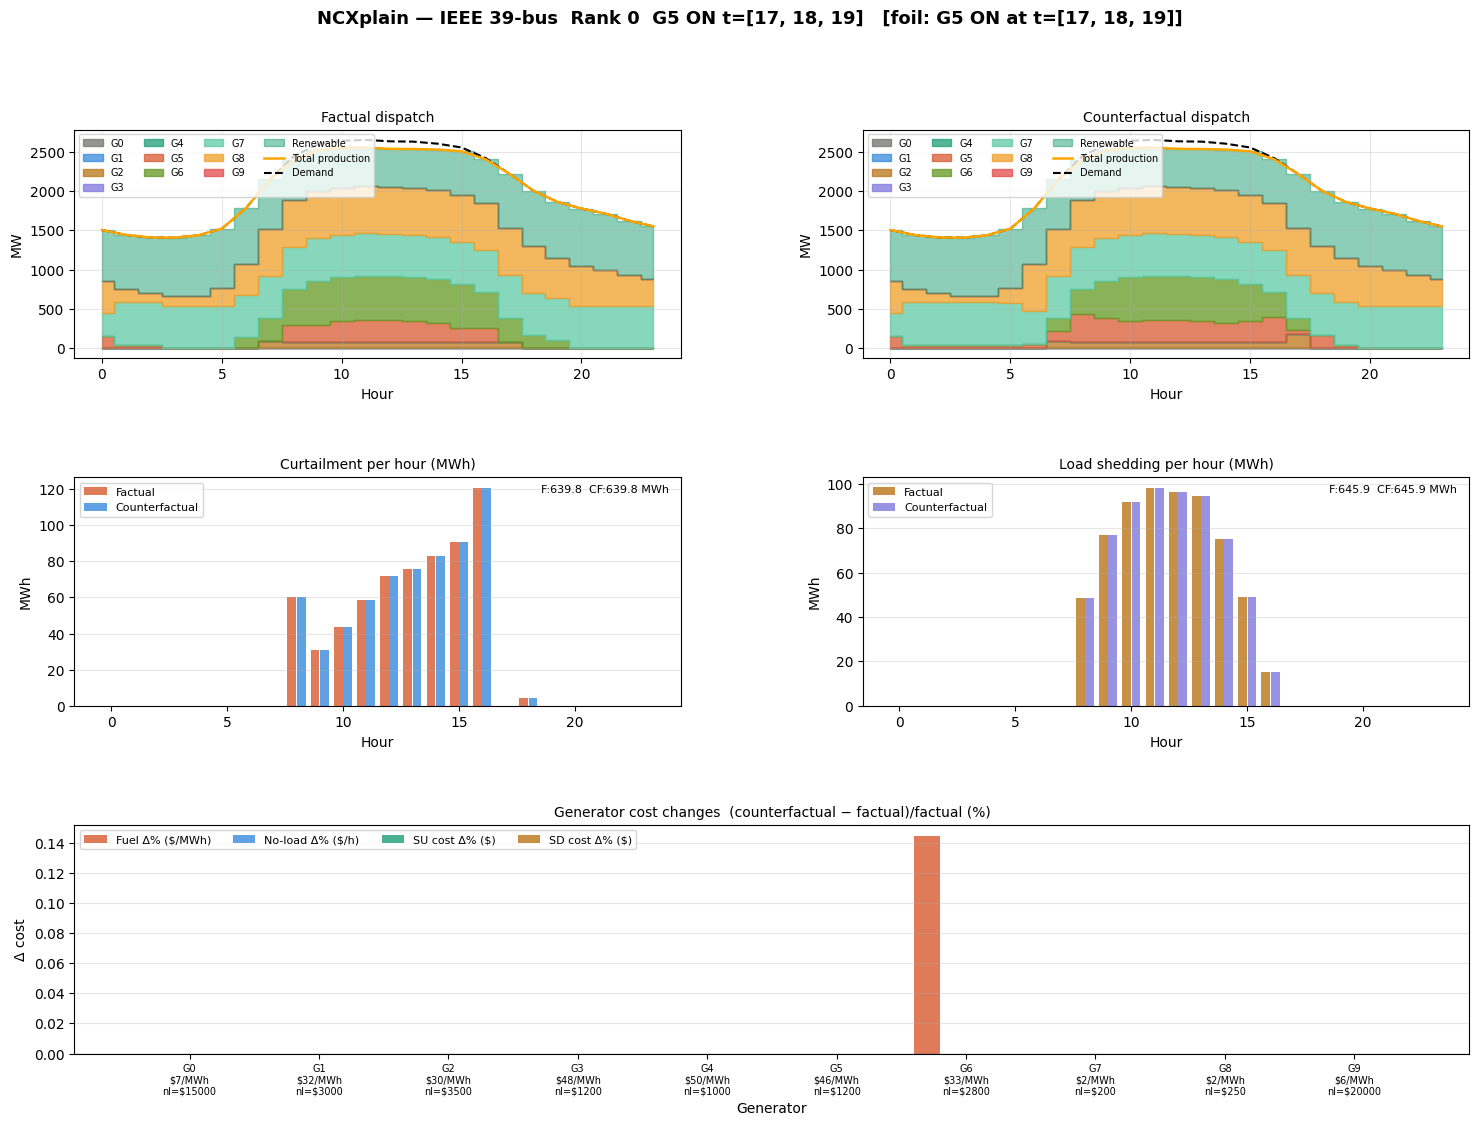

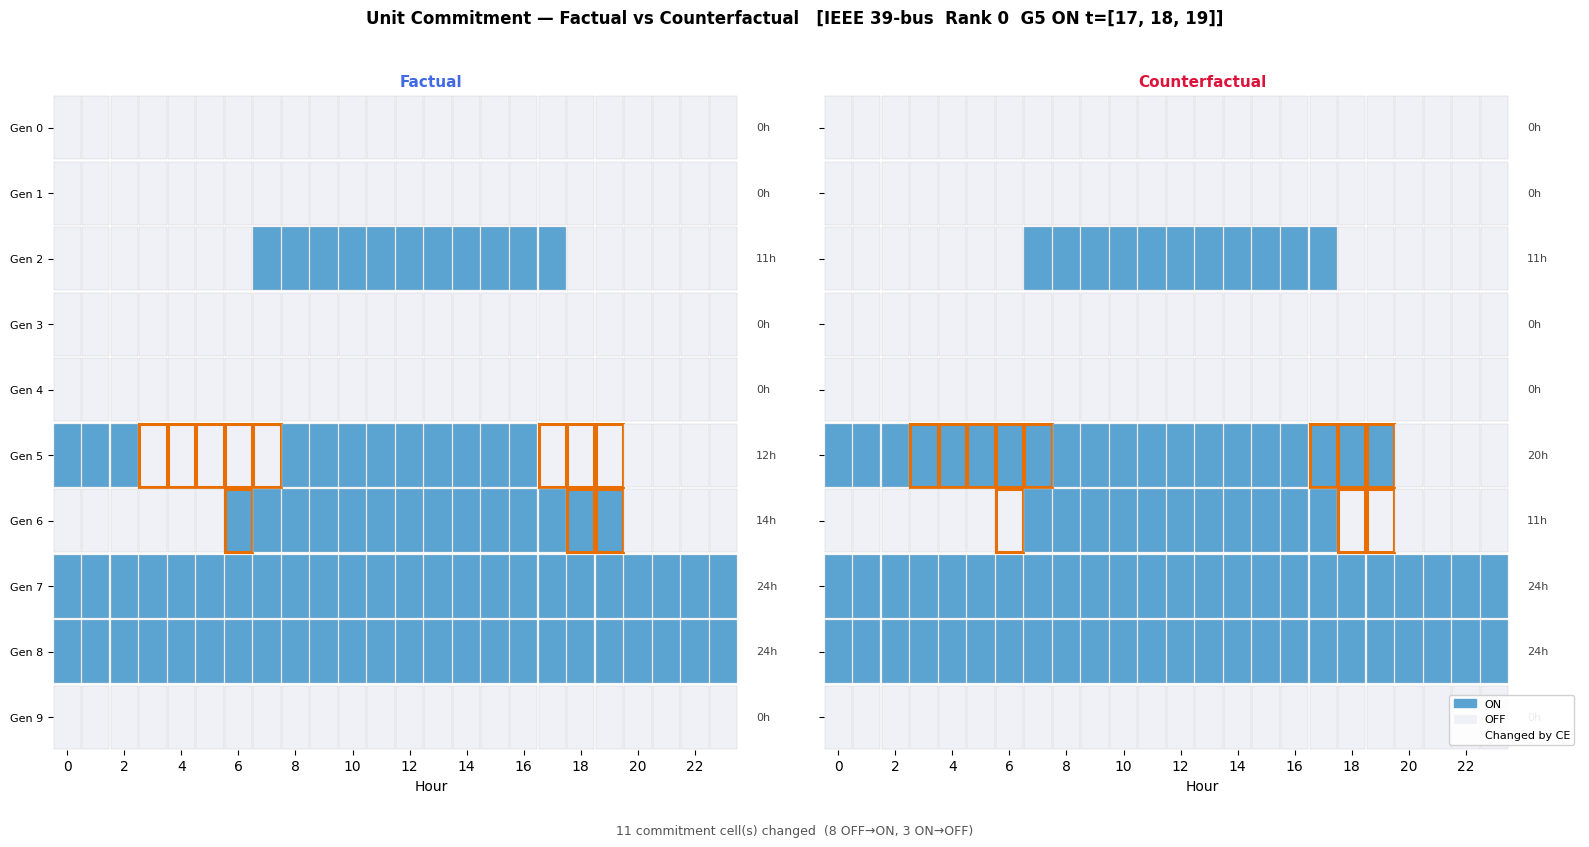


IEEE 39-bus  Rank 0  G5 ON t=[17, 18, 19] — cost changes:
    G   orig_fuel     Δfuel   orig_nlod    Δno-load         ΔSU         ΔSD
    6       33.00      0.14     2800.00        0.00        0.00        0.00

Rank 1  G5 ON t=[3, 4, 5]  gap=1298
[NCX it=01] gap=0 | stop_tol=13.5 | MP_obj=2.5019 | foil_cost=13480809.40 | opt_cost=13480809.40
  → status: OPTIMAL

  ── Sanity Check Rank 1  G5 ON t=[3, 4, 5] ──────────────────────────────
    g       param        base         new        Δabs        Δ%
  ----------------------------------------------------------
    0        fuel       7.000       7.000      +0.000     0.00%
    0     no_load   15000.000   15000.000      +0.000     0.00%
    0          SU  150000.000  150000.000      +0.000     0.00%
    0          SD   30000.000   30000.000      +0.000     0.00%
    1        fuel      32.000      32.000      +0.000     0.00%
    1     no_load    3000.000    3000.000      +0.000     0.00%
    1          SU   25000.000   25000.000      +0.

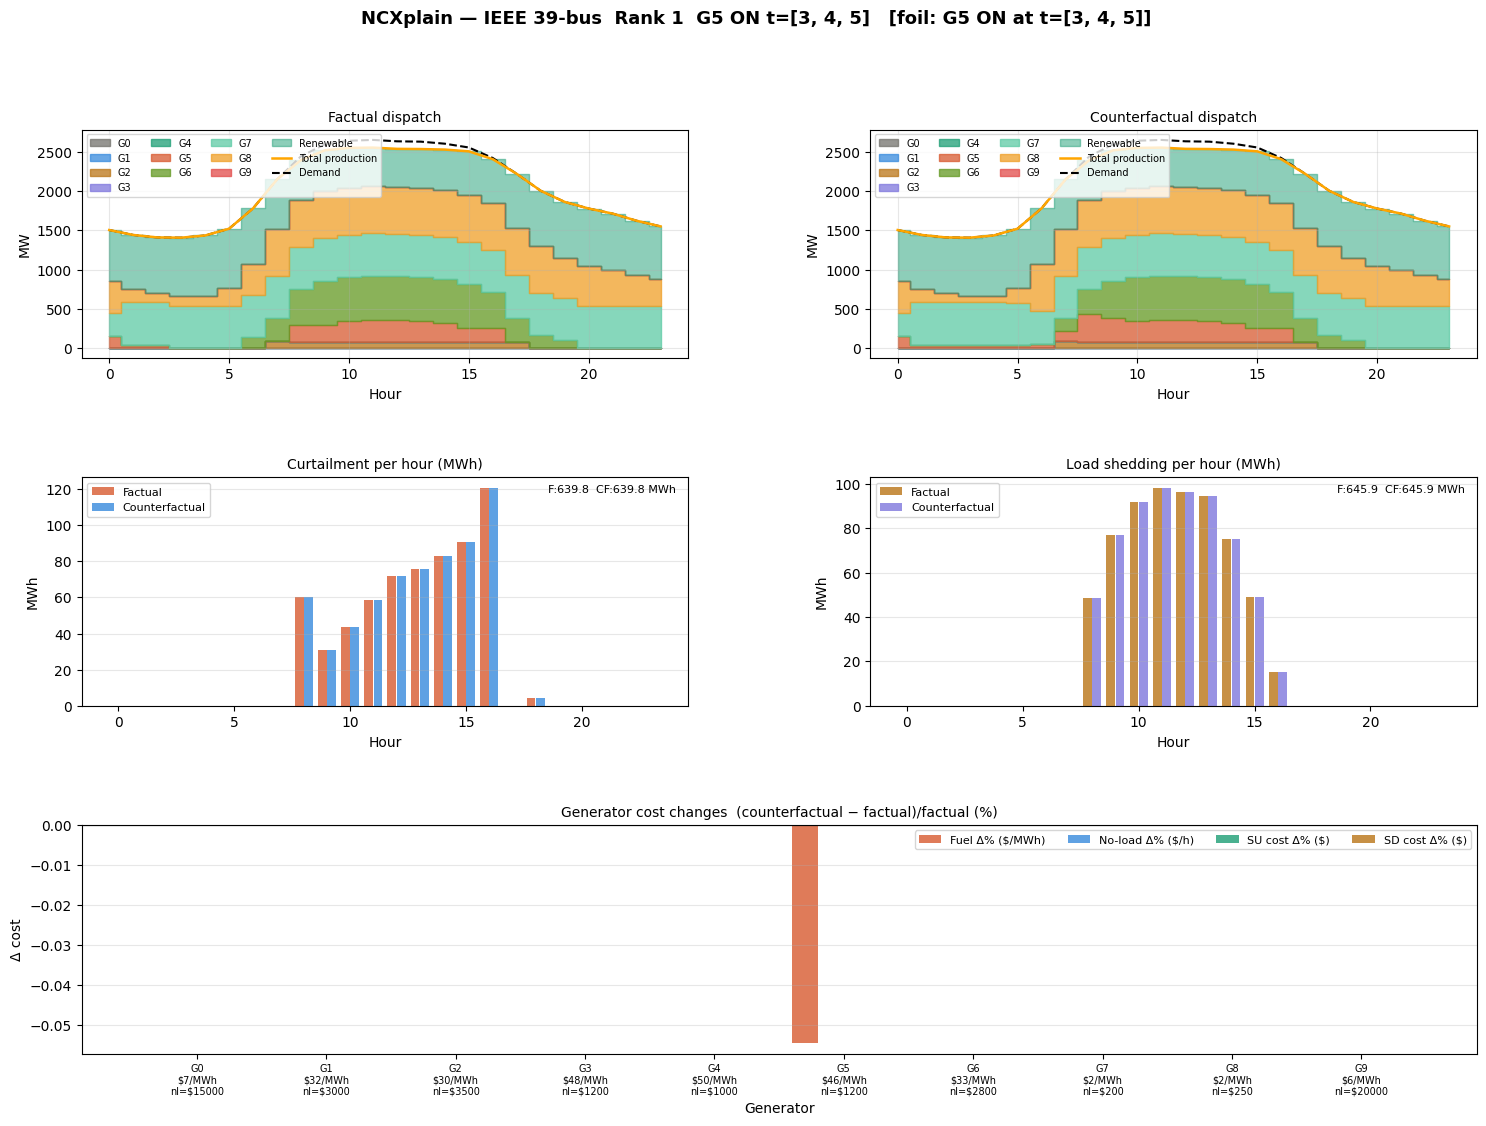

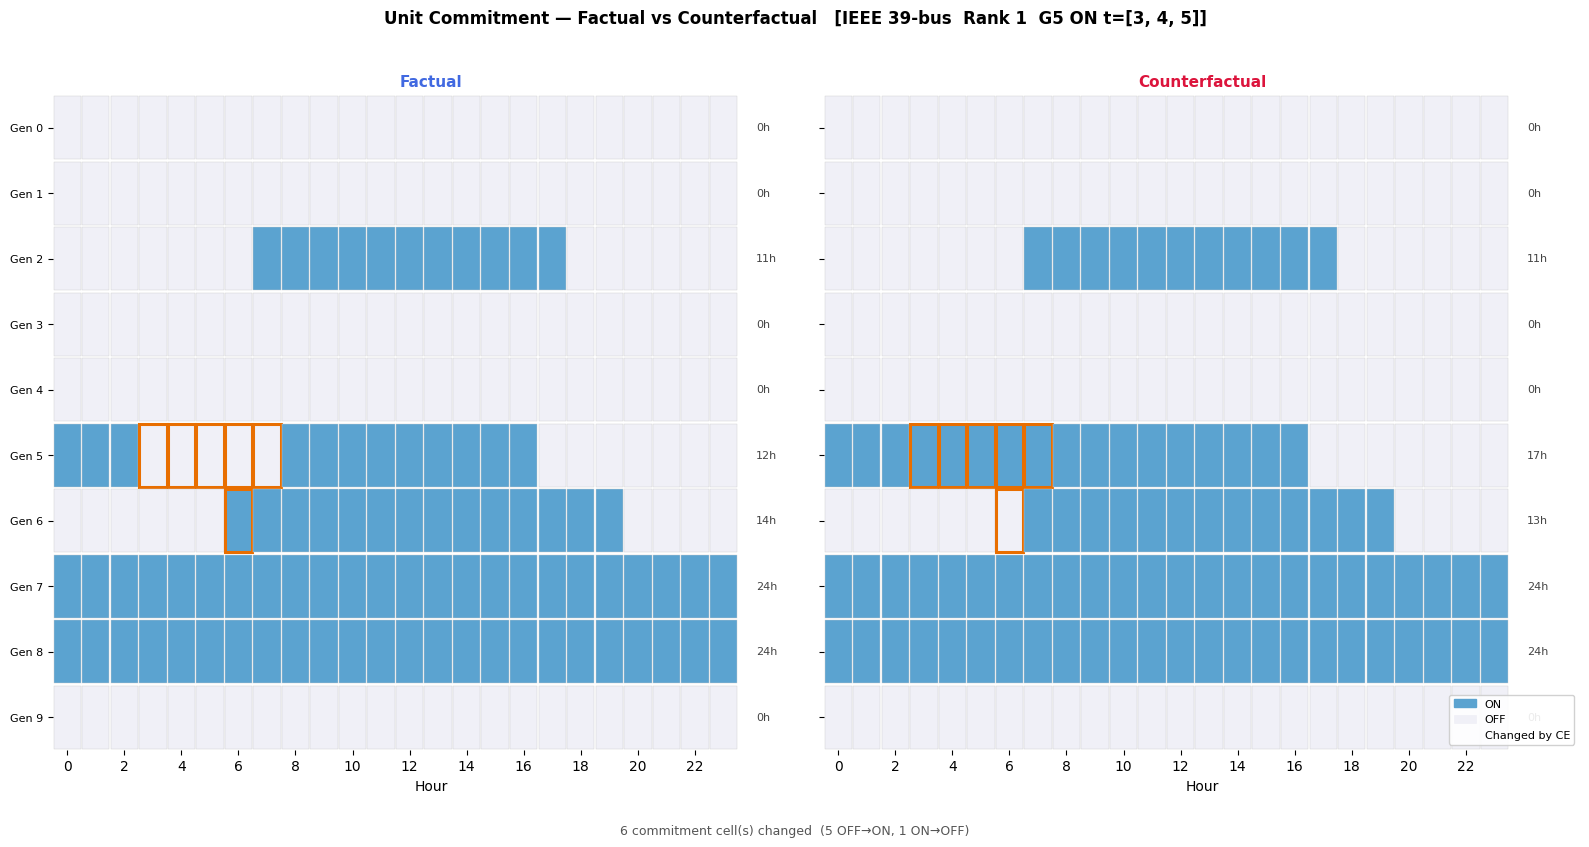


IEEE 39-bus  Rank 1  G5 ON t=[3, 4, 5] — cost changes:
    G   orig_fuel     Δfuel   orig_nlod    Δno-load         ΔSU         ΔSD
    5       46.00     -0.05     1200.00        0.00        0.00        0.00

Rank 2  G5 ON t=[3, 4, 5, 6, 7]  gap=1298
[NCX it=01] gap=0 | stop_tol=13.5 | MP_obj=2.5019 | foil_cost=13480809.40 | opt_cost=13480809.40
  → status: OPTIMAL

  ── Sanity Check Rank 2  G5 ON t=[3, 4, 5, 6, 7] ──────────────────────────────
    g       param        base         new        Δabs        Δ%
  ----------------------------------------------------------
    0        fuel       7.000       7.000      +0.000     0.00%
    0     no_load   15000.000   15000.000      +0.000     0.00%
    0          SU  150000.000  150000.000      +0.000     0.00%
    0          SD   30000.000   30000.000      +0.000     0.00%
    1        fuel      32.000      32.000      +0.000     0.00%
    1     no_load    3000.000    3000.000      +0.000     0.00%
    1          SU   25000.000   25000.000

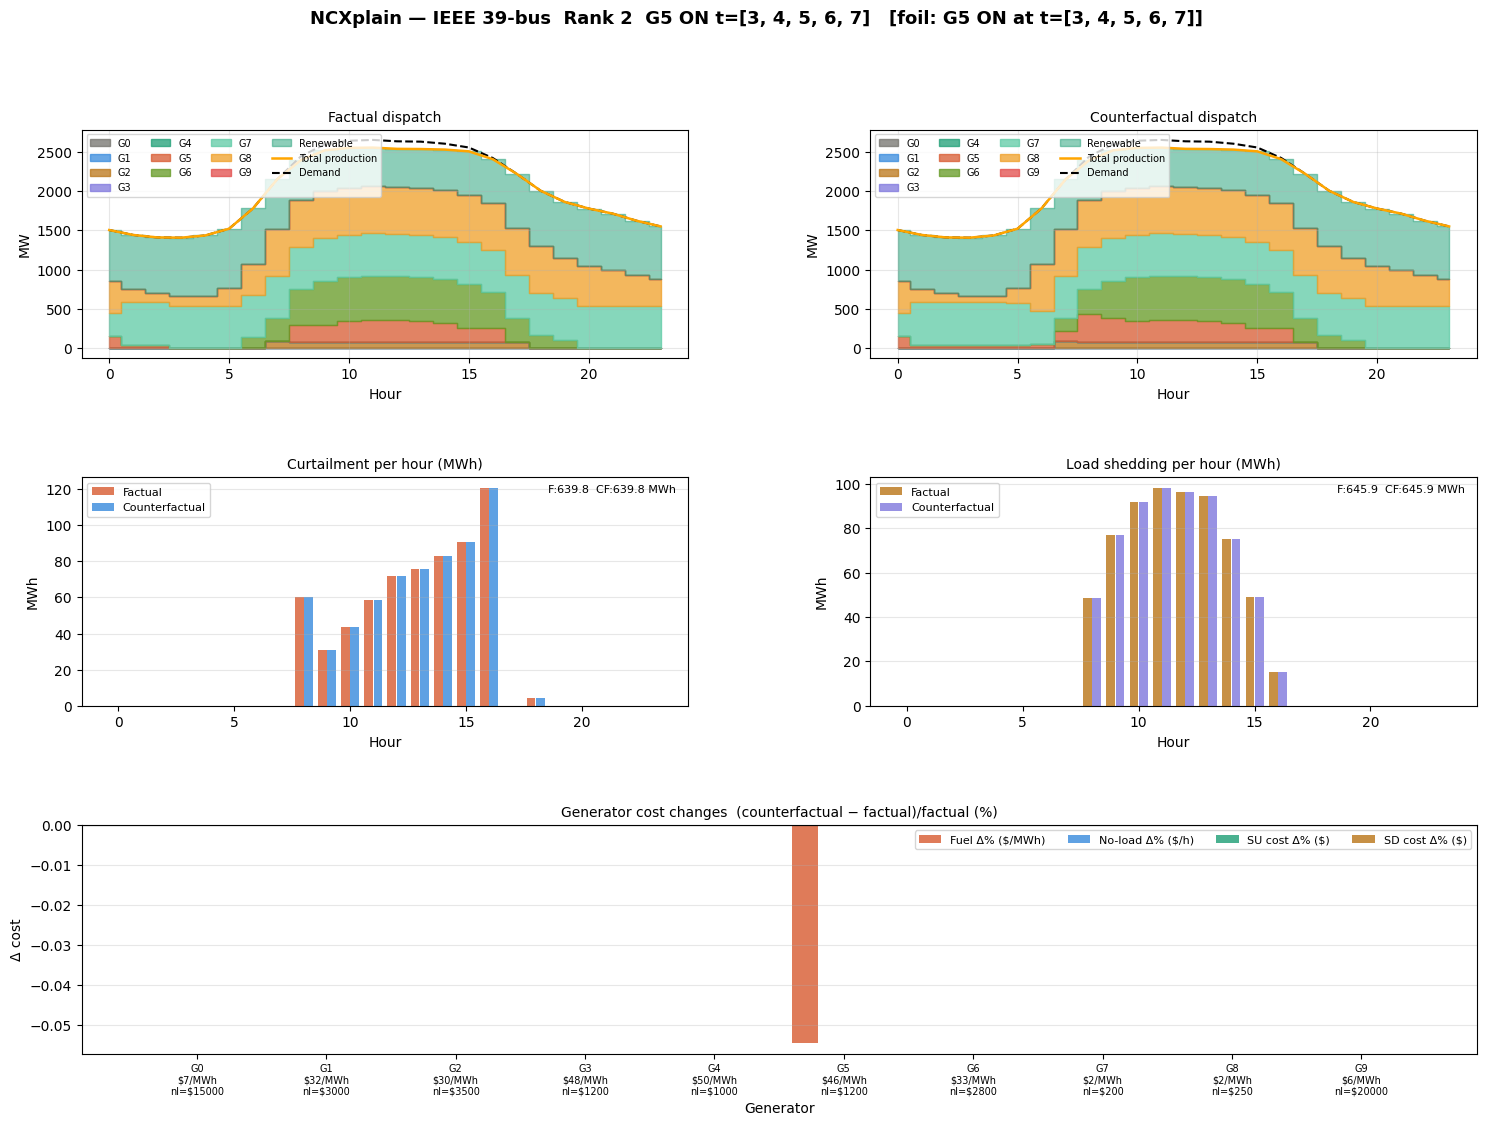

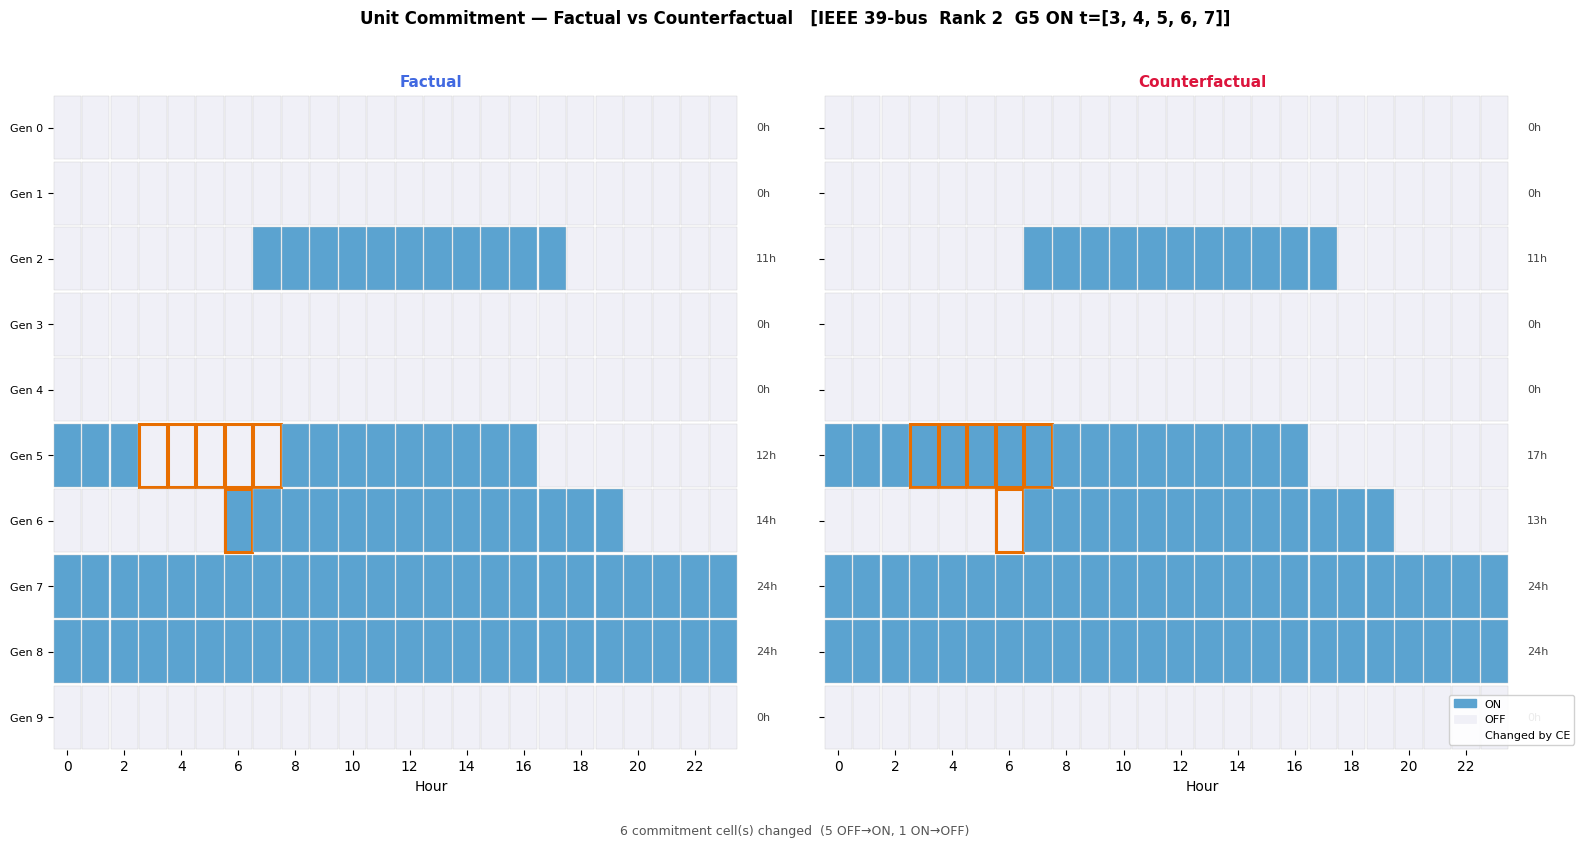


IEEE 39-bus  Rank 2  G5 ON t=[3, 4, 5, 6, 7] — cost changes:
    G   orig_fuel     Δfuel   orig_nlod    Δno-load         ΔSU         ΔSD
    5       46.00     -0.05     1200.00        0.00        0.00        0.00

Rank 3  G5 ON t=[3, 4, 5, 6]  gap=1298
[NCX it=01] gap=-7.45058e-09 | stop_tol=13.5 | MP_obj=2.5019 | foil_cost=13480809.40 | opt_cost=13480809.40
  → status: OPTIMAL

  ── Sanity Check Rank 3  G5 ON t=[3, 4, 5, 6] ──────────────────────────────
    g       param        base         new        Δabs        Δ%
  ----------------------------------------------------------
    0        fuel       7.000       7.000      +0.000     0.00%
    0     no_load   15000.000   15000.000      +0.000     0.00%
    0          SU  150000.000  150000.000      +0.000     0.00%
    0          SD   30000.000   30000.000      +0.000     0.00%
    1        fuel      32.000      32.000      +0.000     0.00%
    1     no_load    3000.000    3000.000      +0.000     0.00%
    1          SU   25000.000 

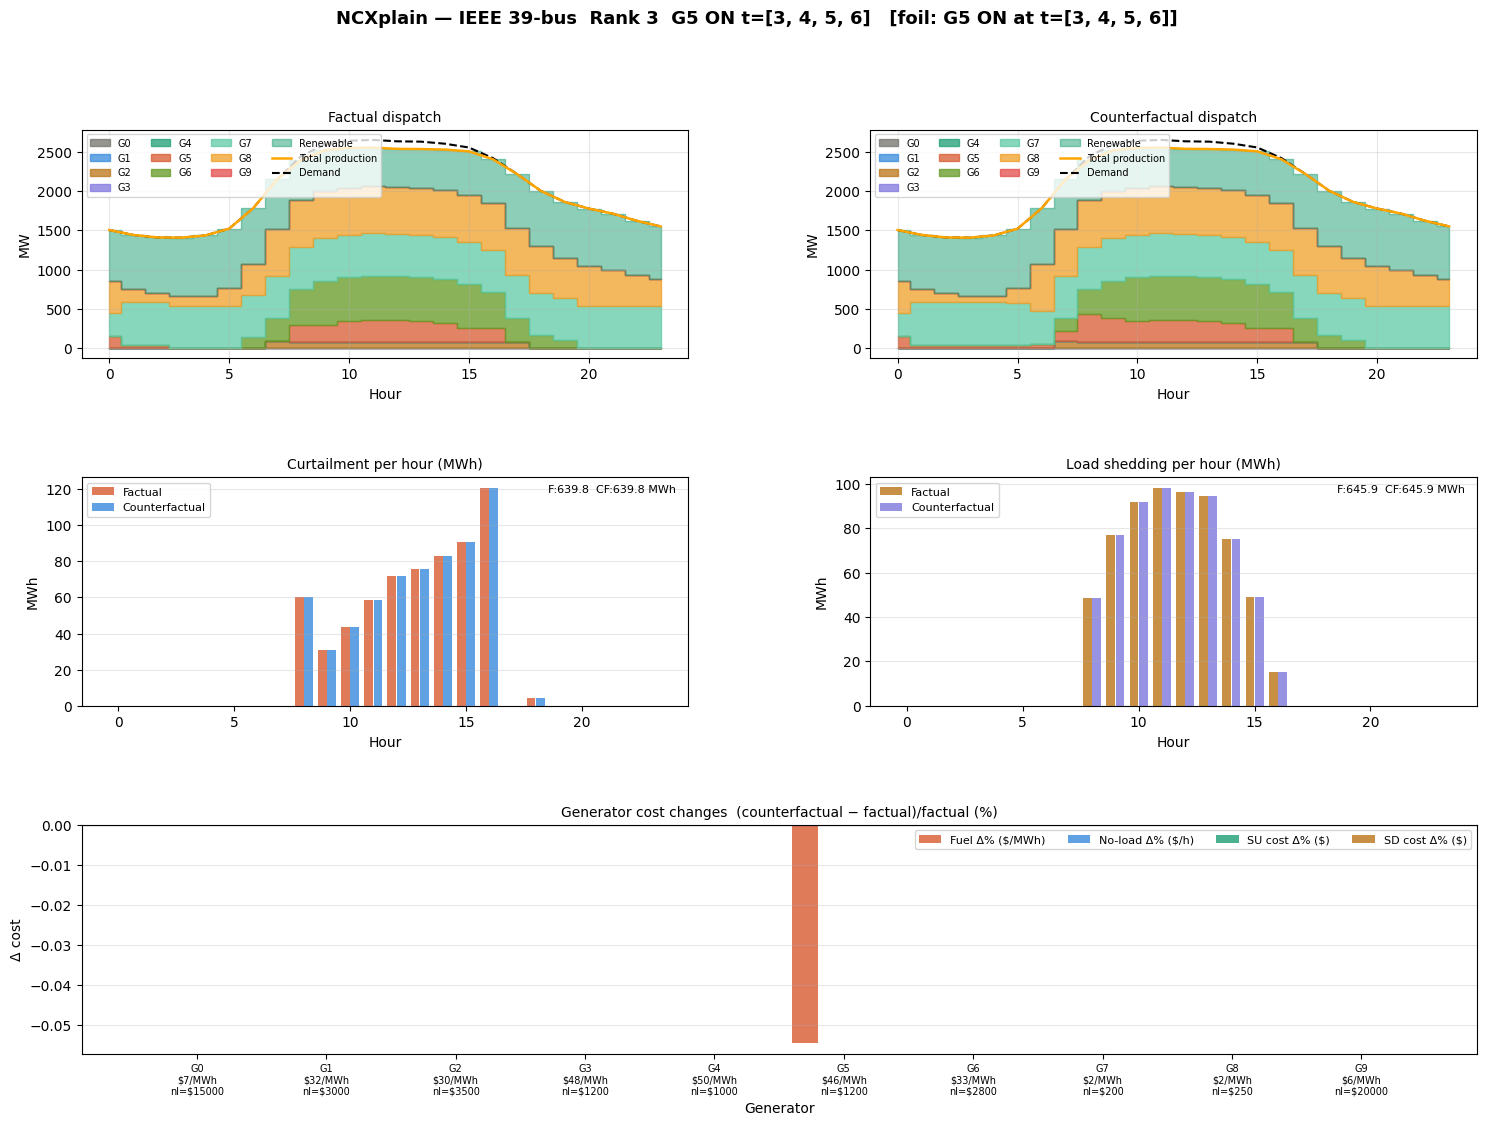

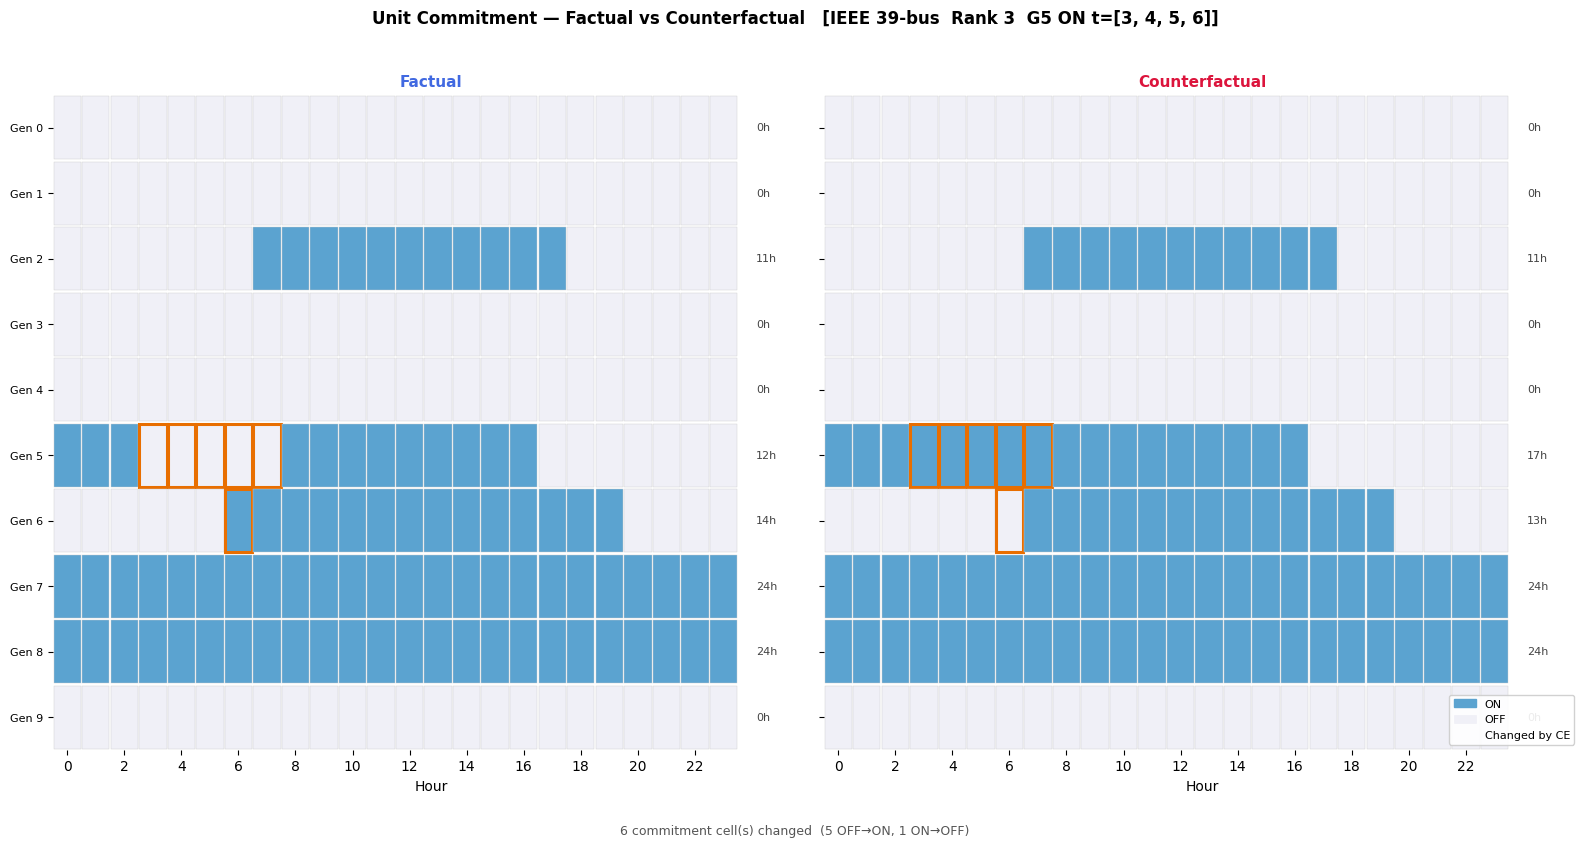


IEEE 39-bus  Rank 3  G5 ON t=[3, 4, 5, 6] — cost changes:
    G   orig_fuel     Δfuel   orig_nlod    Δno-load         ΔSU         ΔSD
    5       46.00     -0.05     1200.00        0.00        0.00        0.00

Rank 4  G3 ON t=[0, 1, 2]  gap=1369
[NCX it=01] gap=2.21655e-07 | stop_tol=13.5 | MP_obj=5.48981 | foil_cost=13479306.48 | opt_cost=13479306.48
  → status: OPTIMAL

  ── Sanity Check Rank 4  G3 ON t=[0, 1, 2] ──────────────────────────────
    g       param        base         new        Δabs        Δ%
  ----------------------------------------------------------
    0        fuel       7.000       7.000      +0.000     0.00%
    0     no_load   15000.000   15000.000      +0.000     0.00%
    0          SU  150000.000  150000.000      +0.000     0.00%
    0          SD   30000.000   30000.000      +0.000     0.00%
    1        fuel      32.000      32.000      +0.000     0.00%
    1     no_load    3000.000    3000.000      +0.000     0.00%
    1          SU   25000.000   25000.0

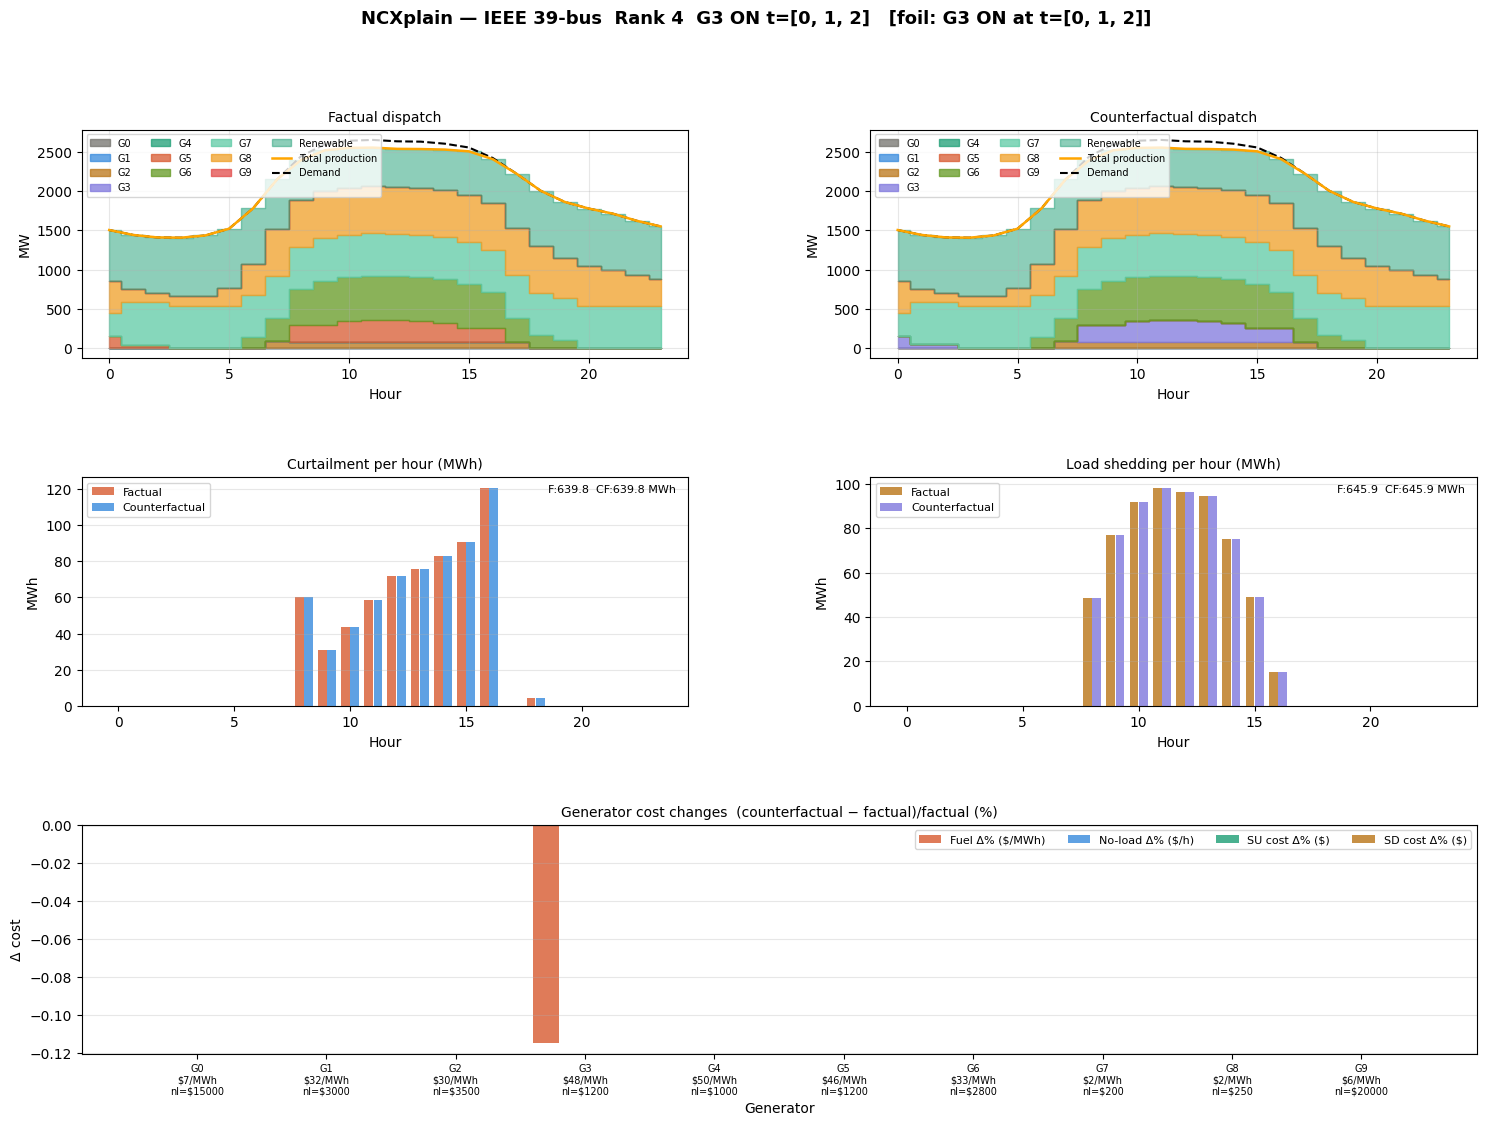

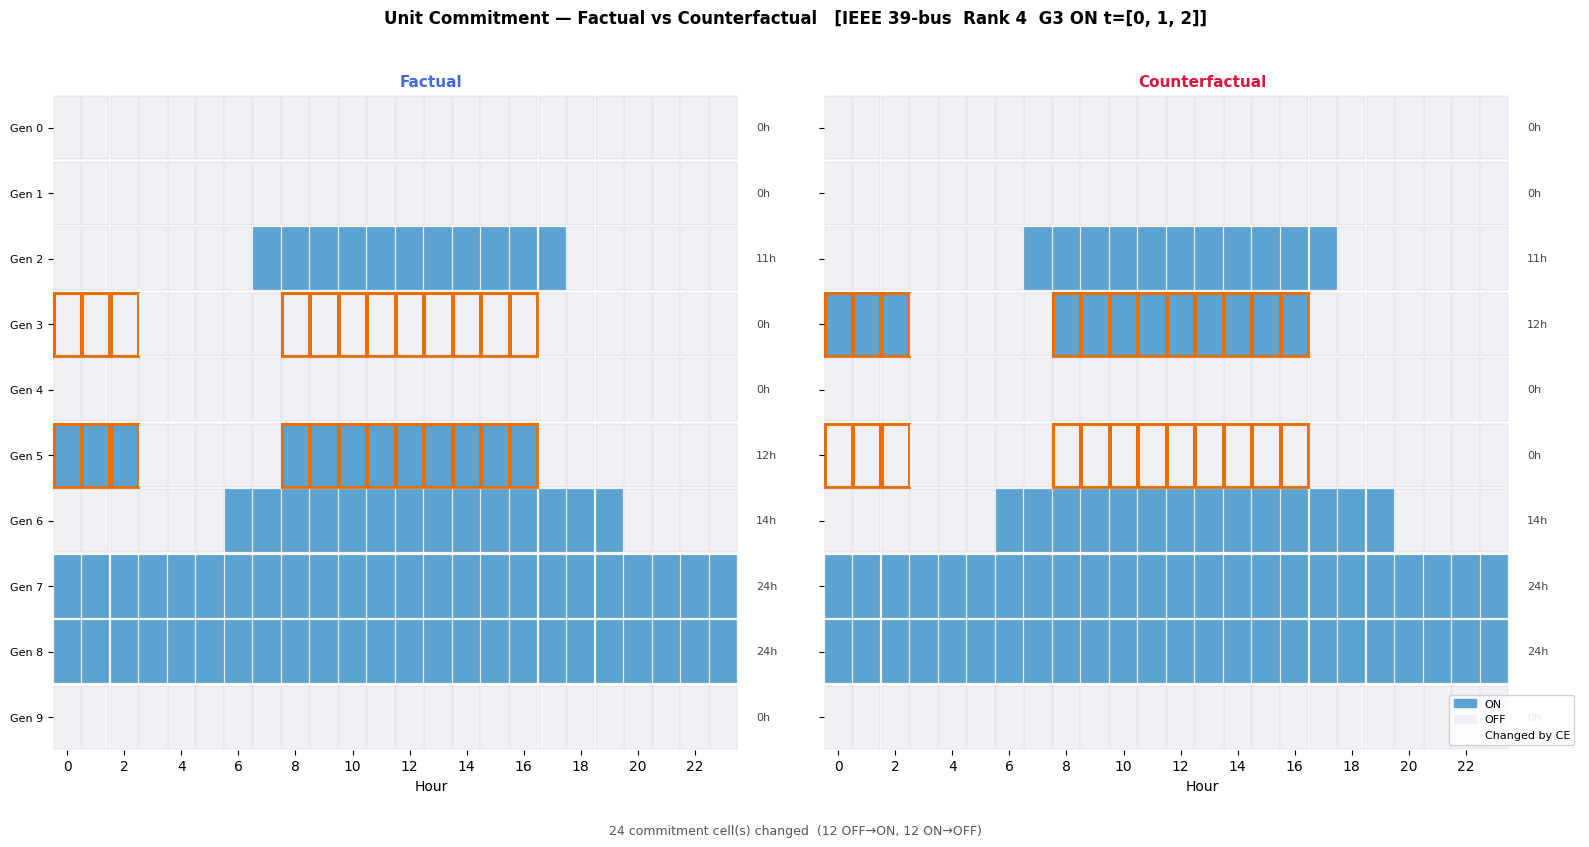


IEEE 39-bus  Rank 4  G3 ON t=[0, 1, 2] — cost changes:
    G   orig_fuel     Δfuel   orig_nlod    Δno-load         ΔSU         ΔSD
    3       48.00     -0.11     1200.00        0.00        0.00        0.00

Rank 5  G4 ON t=[0, 1, 2, 3]  gap=3442
[NCX it=01] gap=2732.54 | stop_tol=13.5 | MP_obj=11.5009 | foil_cost=13486574.66 | opt_cost=13483842.12
[NCX it=02] gap=0 | stop_tol=13.5 | MP_obj=12.848 | foil_cost=13483506.30 | opt_cost=13483506.30
  → status: OPTIMAL

  ── Sanity Check Rank 5  G4 ON t=[0, 1, 2, 3] ──────────────────────────────
    g       param        base         new        Δabs        Δ%
  ----------------------------------------------------------
    0        fuel       7.000       7.000      +0.000     0.00%
    0     no_load   15000.000   15000.000      +0.000     0.00%
    0          SU  150000.000  150000.000      +0.000     0.00%
    0          SD   30000.000   30000.000      +0.000     0.00%
    1        fuel      32.000      32.000      +0.000     0.00%
    1  

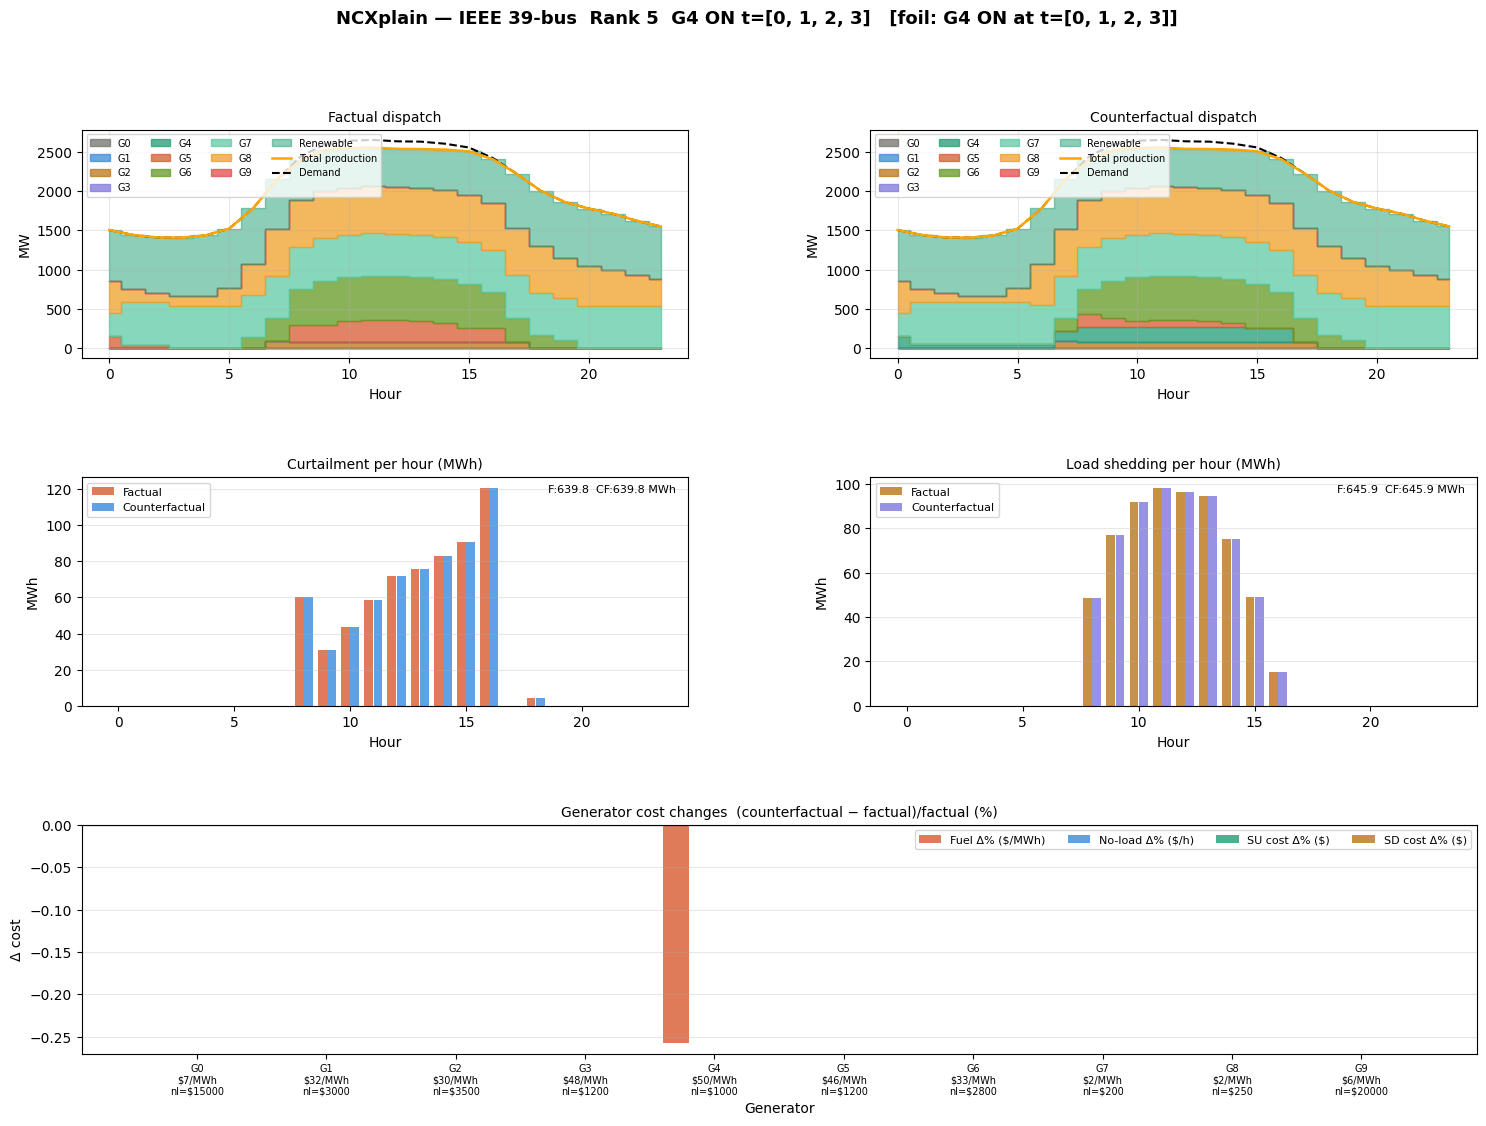

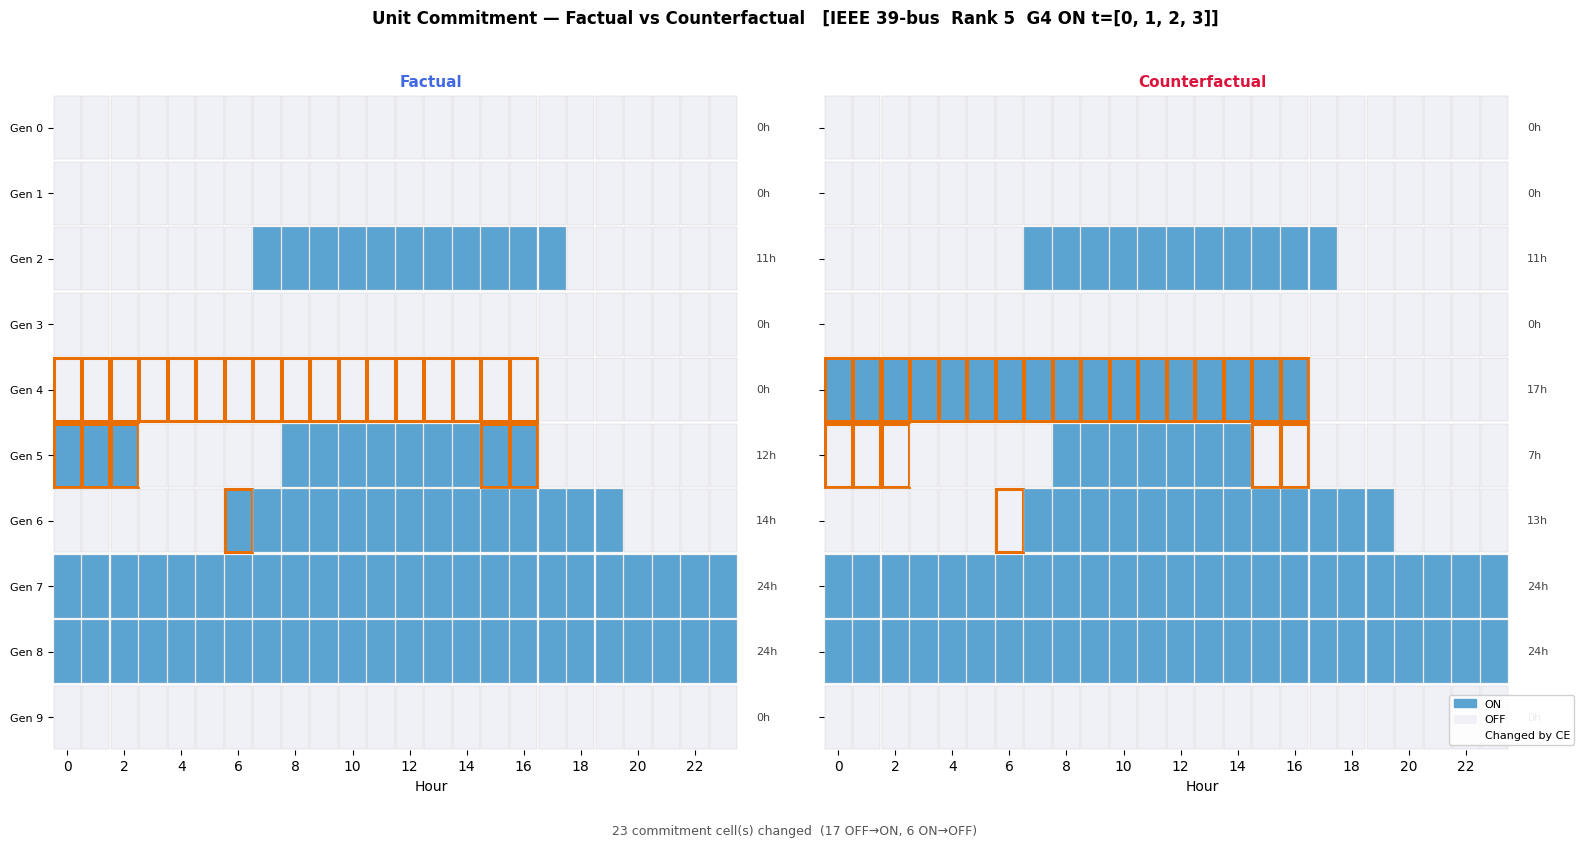


IEEE 39-bus  Rank 5  G4 ON t=[0, 1, 2, 3] — cost changes:
    G   orig_fuel     Δfuel   orig_nlod    Δno-load         ΔSU         ΔSD
    4       50.00     -0.26     1000.00        0.00        0.00        0.00

Rank 6  G5 ON t=[17, 18, 19, 20]  gap=3990
[NCX it=01] gap=2940 | stop_tol=13.5 | MP_obj=18.1364 | foil_cost=13520780.44 | opt_cost=13517840.44
  → status: MP_INFEASIBLE

Rank 7  G5 OFF t=[8, 9, 10, 11]  gap=4204
[NCX it=01] gap=5.58794e-09 | stop_tol=13.5 | MP_obj=2 | foil_cost=13486642.08 | opt_cost=13486642.08
  → status: OPTIMAL

  ── Sanity Check Rank 7  G5 OFF t=[8, 9, 10, 11] ──────────────────────────────
    g       param        base         new        Δabs        Δ%
  ----------------------------------------------------------
    0        fuel       7.000       7.000      +0.000     0.00%
    0     no_load   15000.000   15000.000      +0.000     0.00%
    0          SU  150000.000  150000.000      +0.000     0.00%
    0          SD   30000.000   30000.000      +0.000 

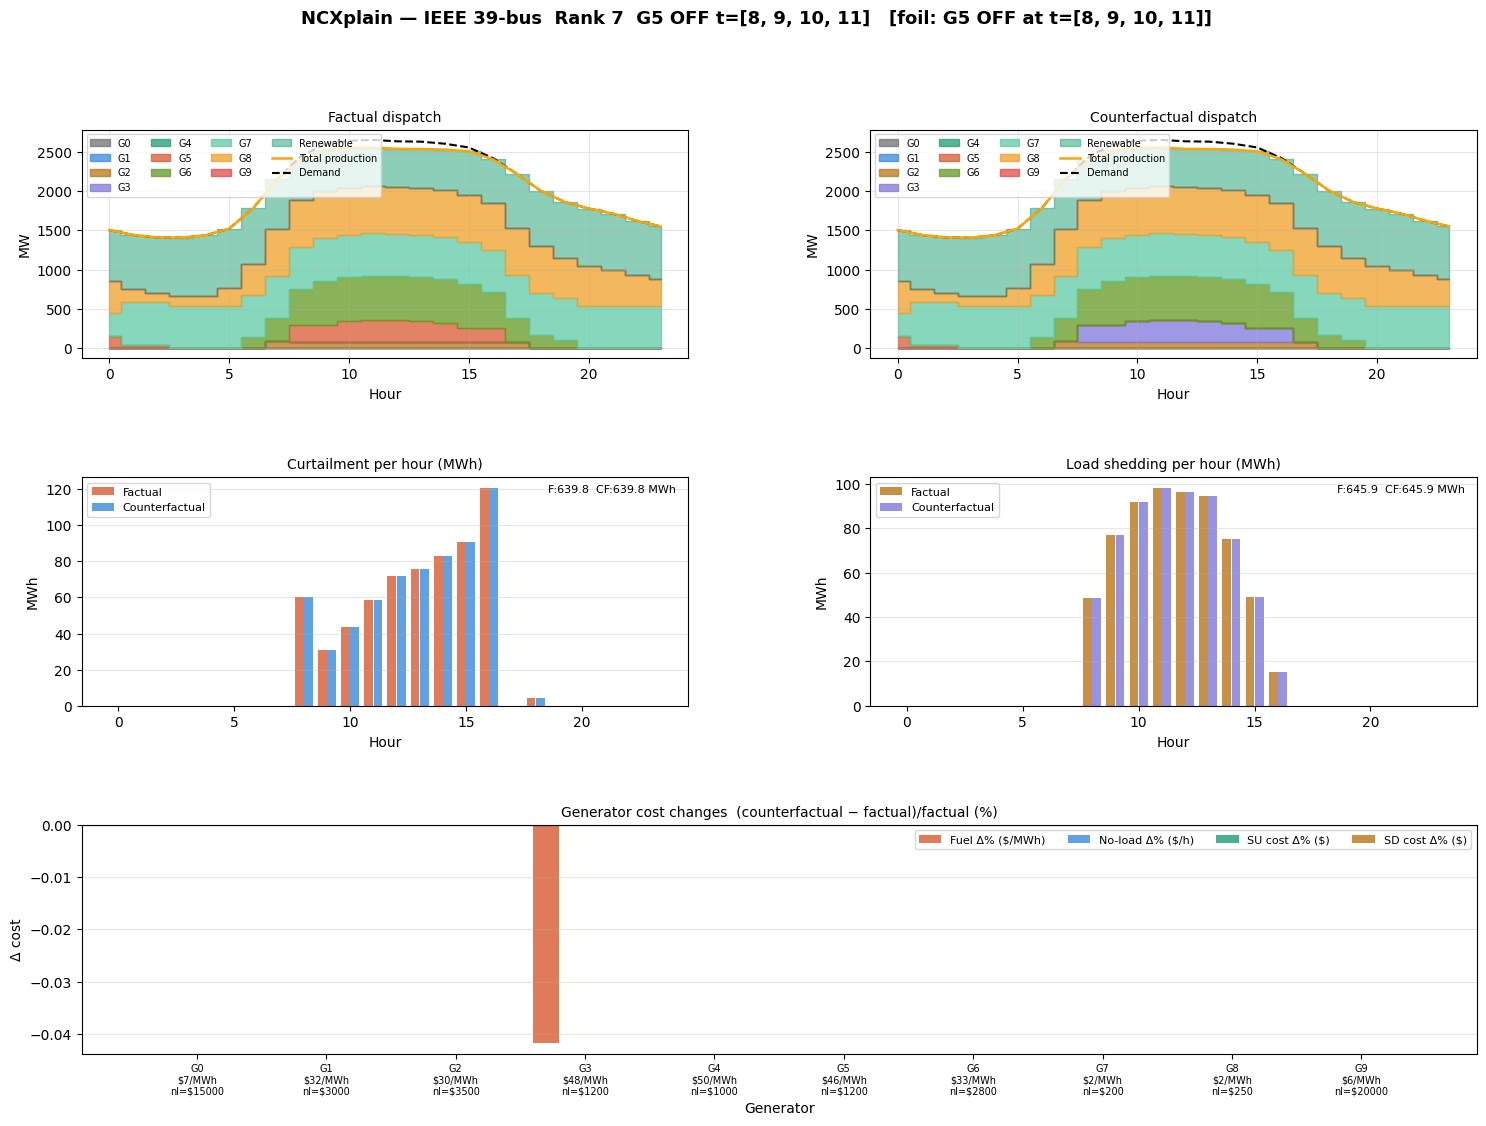

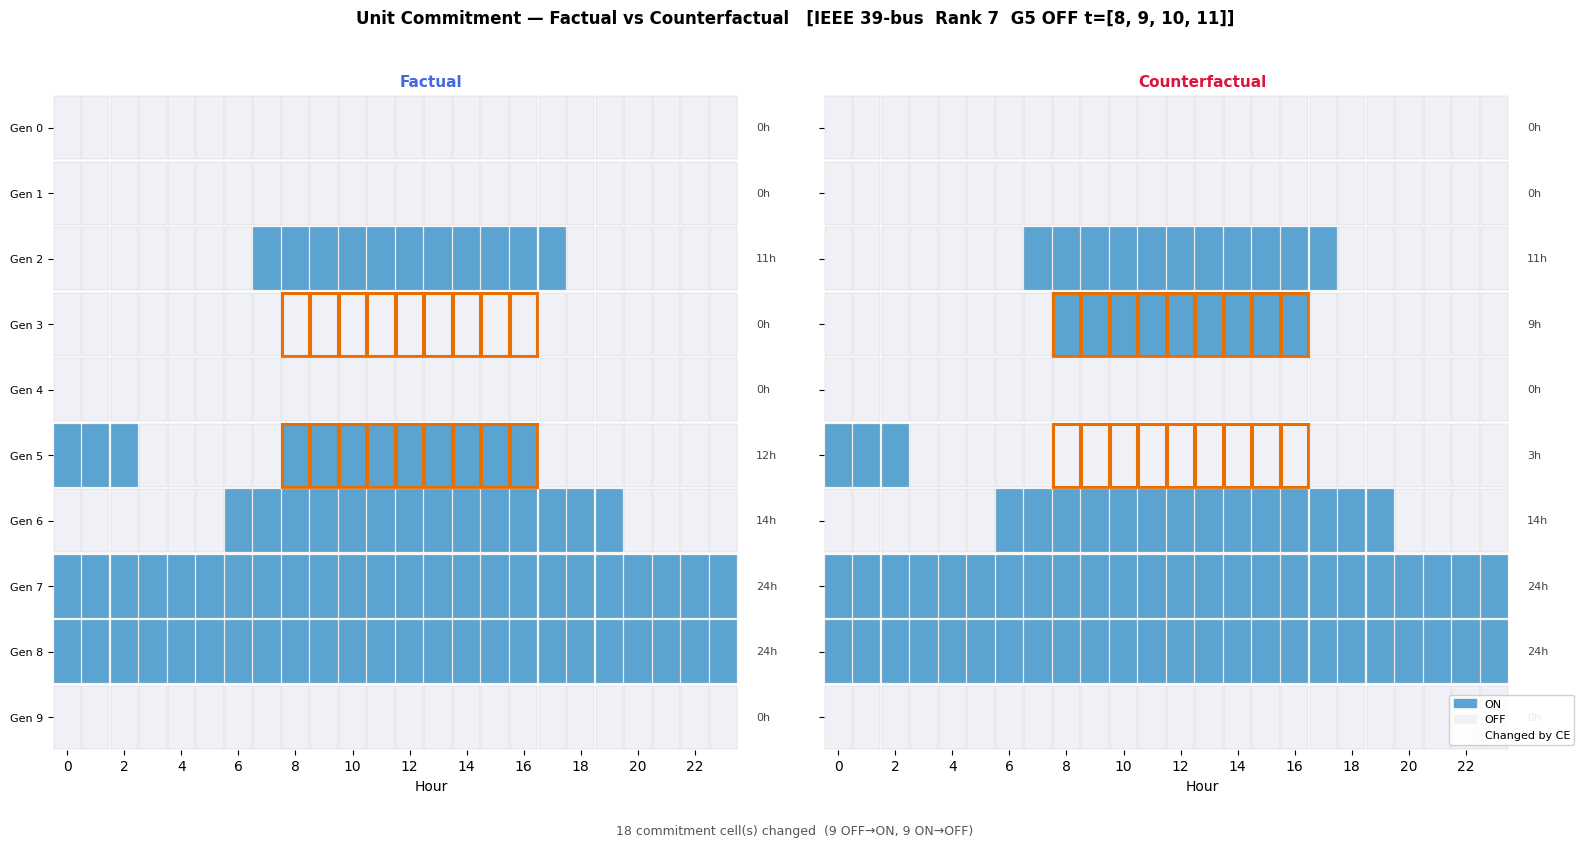


IEEE 39-bus  Rank 7  G5 OFF t=[8, 9, 10, 11] — cost changes:
    G   orig_fuel     Δfuel   orig_nlod    Δno-load         ΔSU         ΔSD
    3       48.00     -0.04     1200.00        0.00        0.00        0.00

Rank 8  G5 OFF t=[8, 9, 10, 11, 12]  gap=4204
[NCX it=01] gap=0 | stop_tol=13.5 | MP_obj=2 | foil_cost=13486642.08 | opt_cost=13486642.08
  → status: OPTIMAL

  ── Sanity Check Rank 8  G5 OFF t=[8, 9, 10, 11, 12] ──────────────────────────────
    g       param        base         new        Δabs        Δ%
  ----------------------------------------------------------
    0        fuel       7.000       7.000      +0.000     0.00%
    0     no_load   15000.000   15000.000      +0.000     0.00%
    0          SU  150000.000  150000.000      +0.000     0.00%
    0          SD   30000.000   30000.000      +0.000     0.00%
    1        fuel      32.000      32.000      +0.000     0.00%
    1     no_load    3000.000    3000.000      +0.000     0.00%
    1          SU   25000.000   

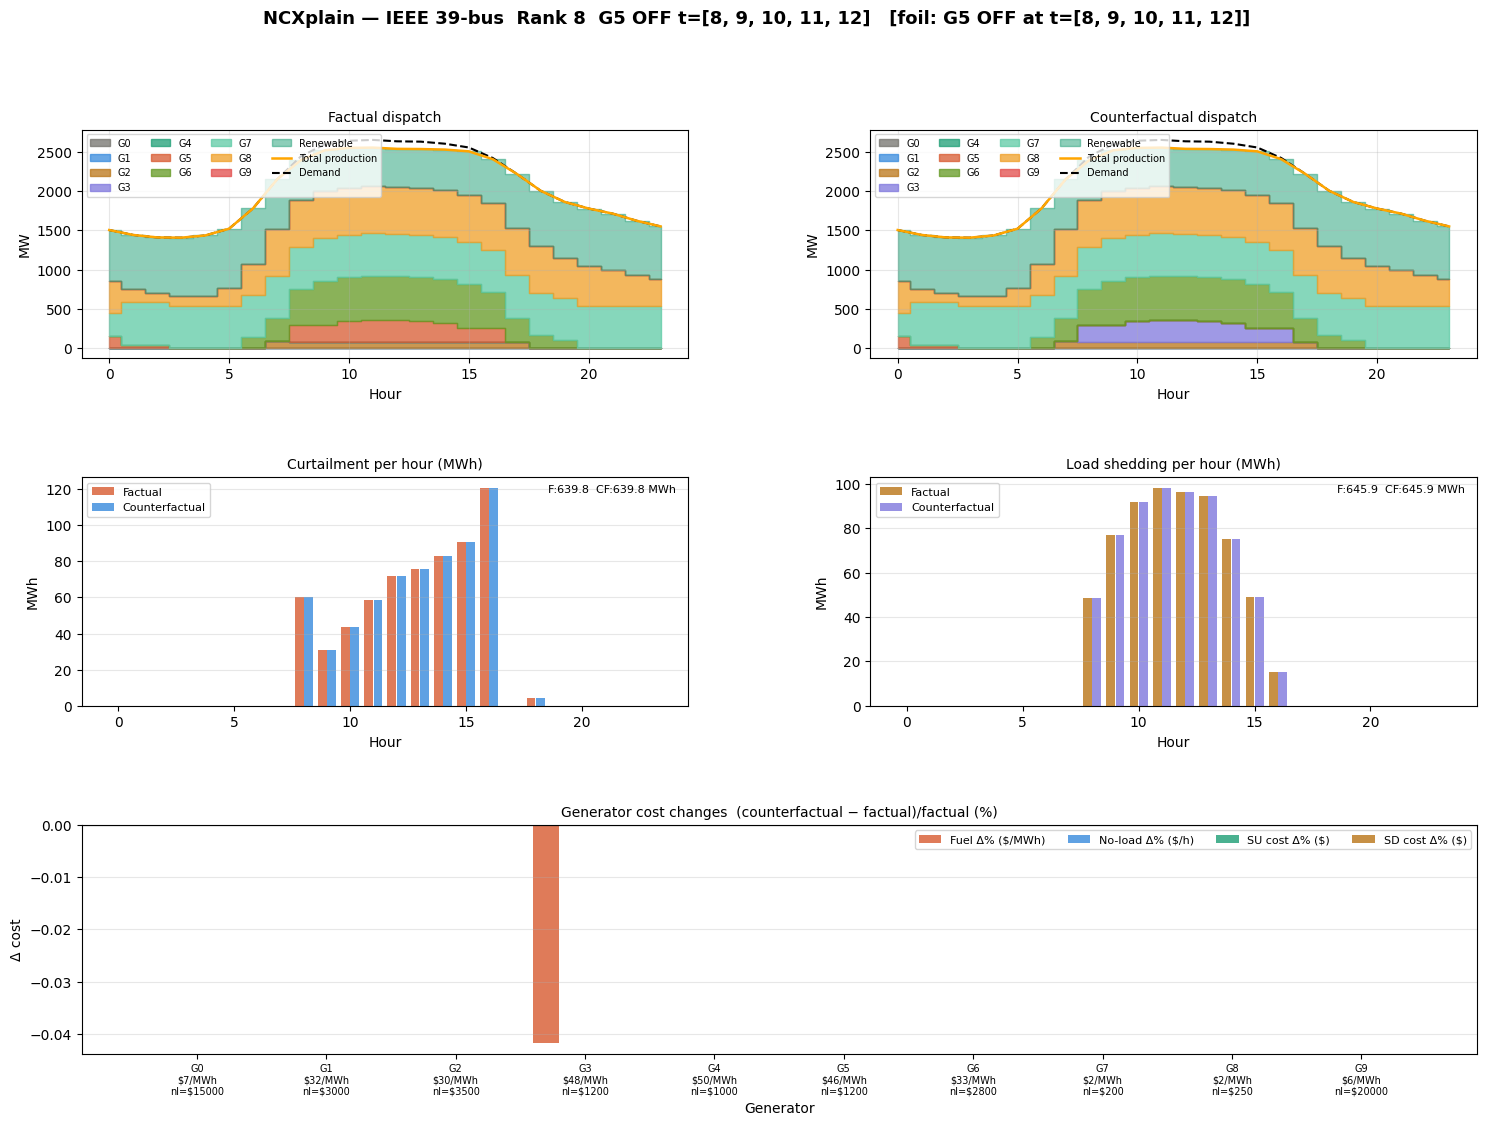

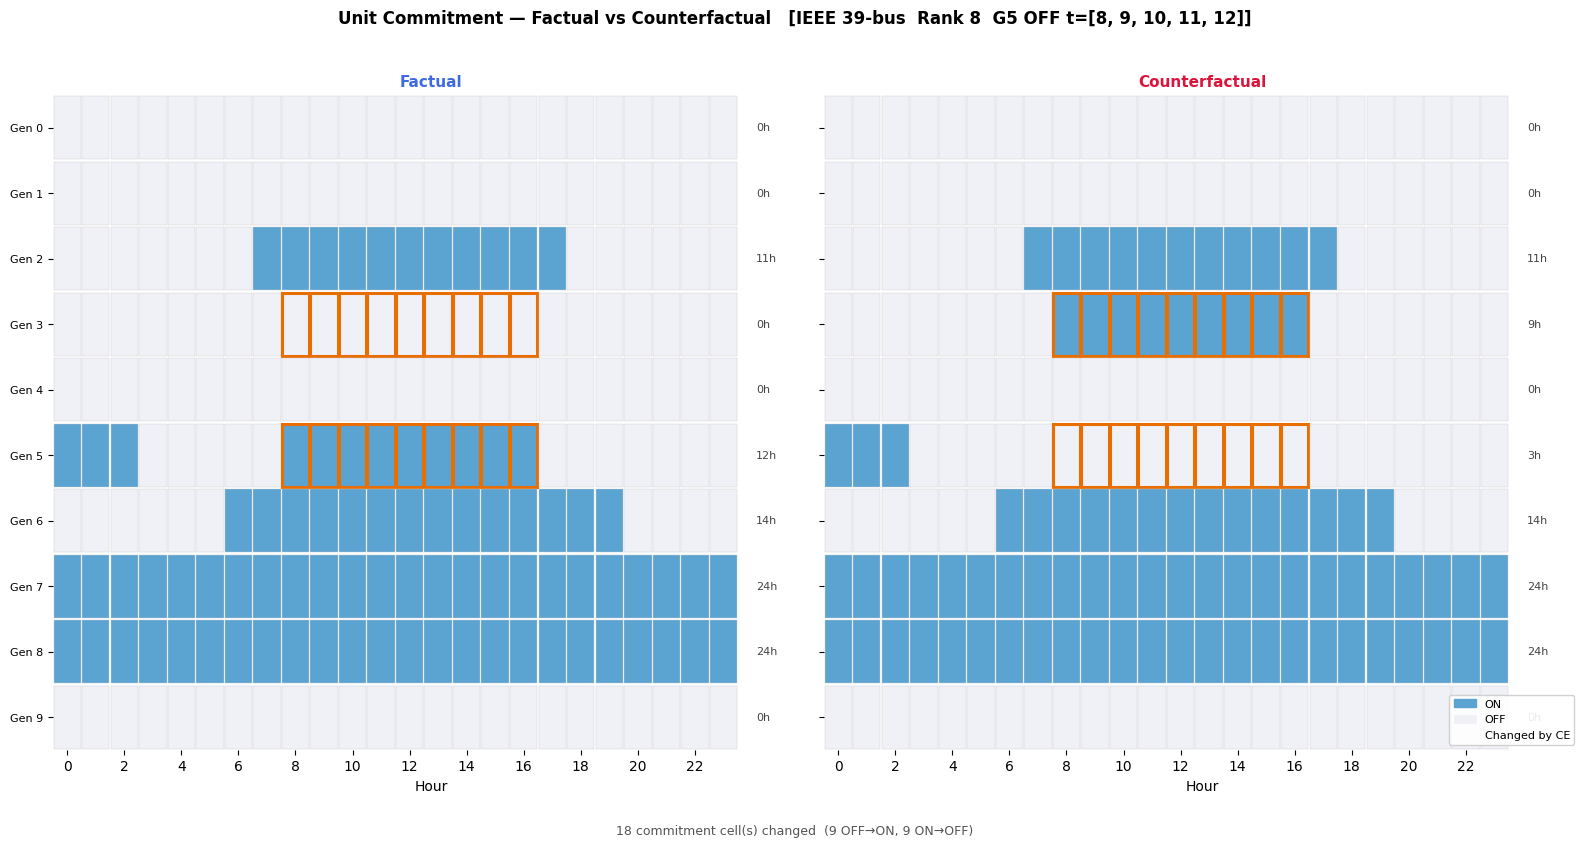


IEEE 39-bus  Rank 8  G5 OFF t=[8, 9, 10, 11, 12] — cost changes:
    G   orig_fuel     Δfuel   orig_nlod    Δno-load         ΔSU         ΔSD
    3       48.00     -0.04     1200.00        0.00        0.00        0.00

Rank 9  G5 OFF t=[8, 9, 10]  gap=4204
[NCX it=01] gap=0 | stop_tol=13.5 | MP_obj=2 | foil_cost=13486642.08 | opt_cost=13486642.08
  → status: OPTIMAL

  ── Sanity Check Rank 9  G5 OFF t=[8, 9, 10] ──────────────────────────────
    g       param        base         new        Δabs        Δ%
  ----------------------------------------------------------
    0        fuel       7.000       7.000      +0.000     0.00%
    0     no_load   15000.000   15000.000      +0.000     0.00%
    0          SU  150000.000  150000.000      +0.000     0.00%
    0          SD   30000.000   30000.000      +0.000     0.00%
    1        fuel      32.000      32.000      +0.000     0.00%
    1     no_load    3000.000    3000.000      +0.000     0.00%
    1          SU   25000.000   25000.000   

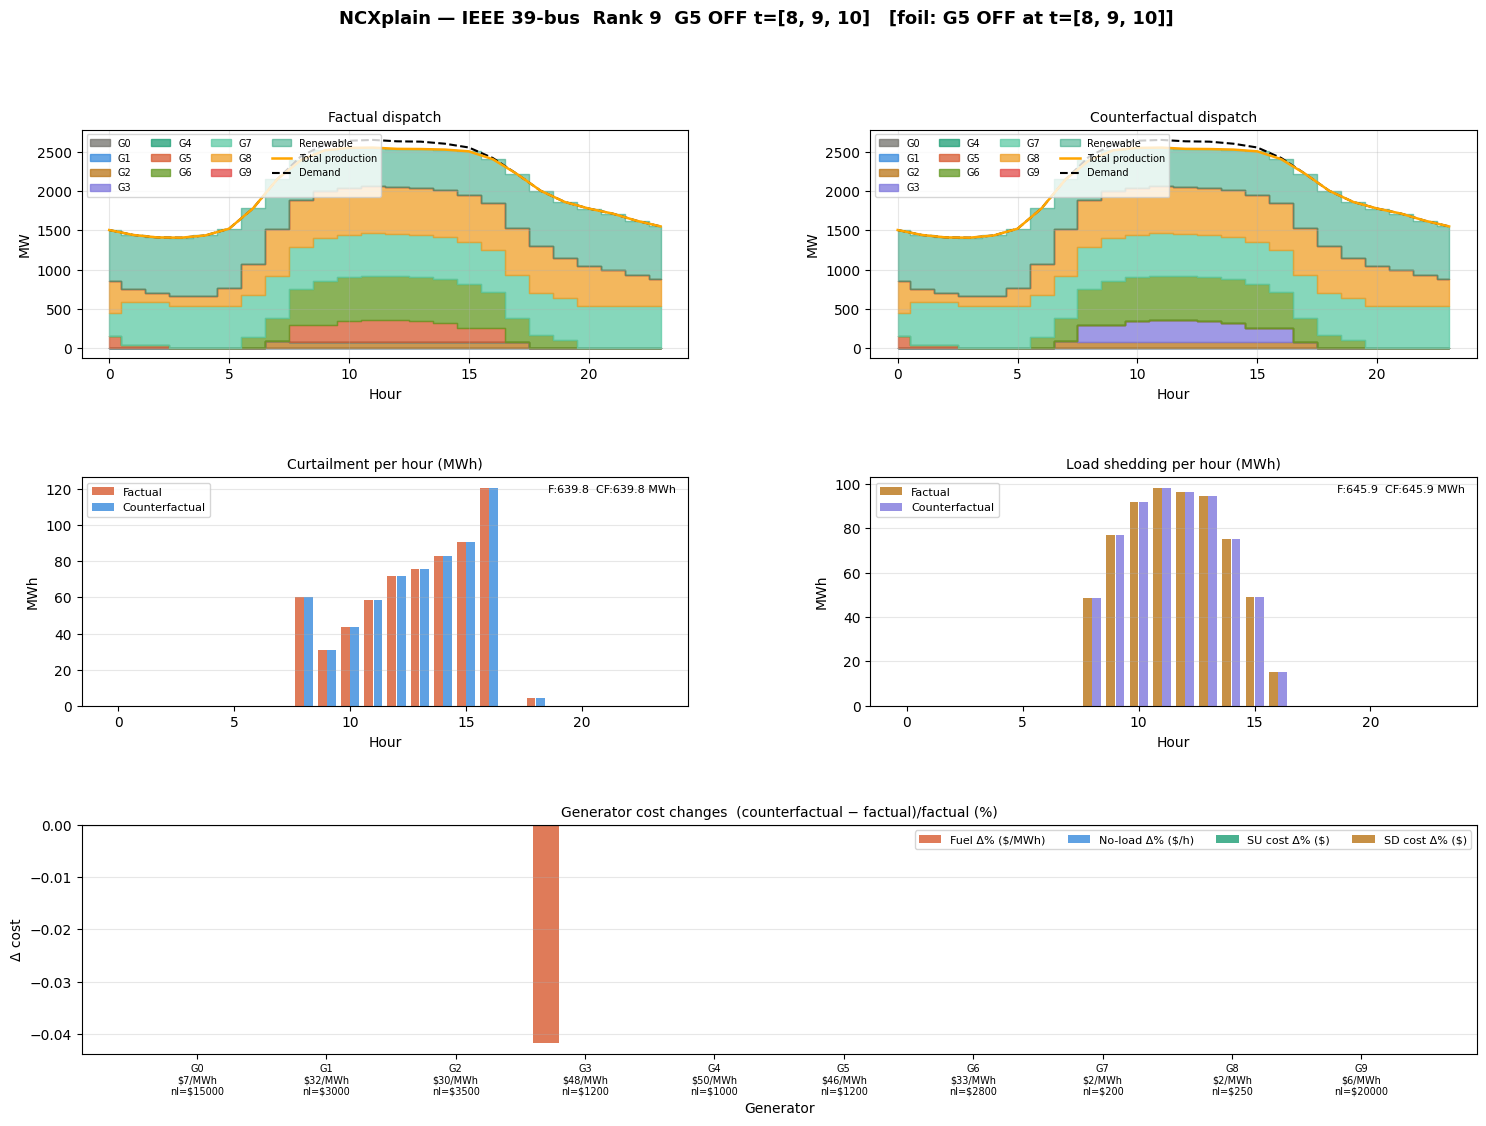

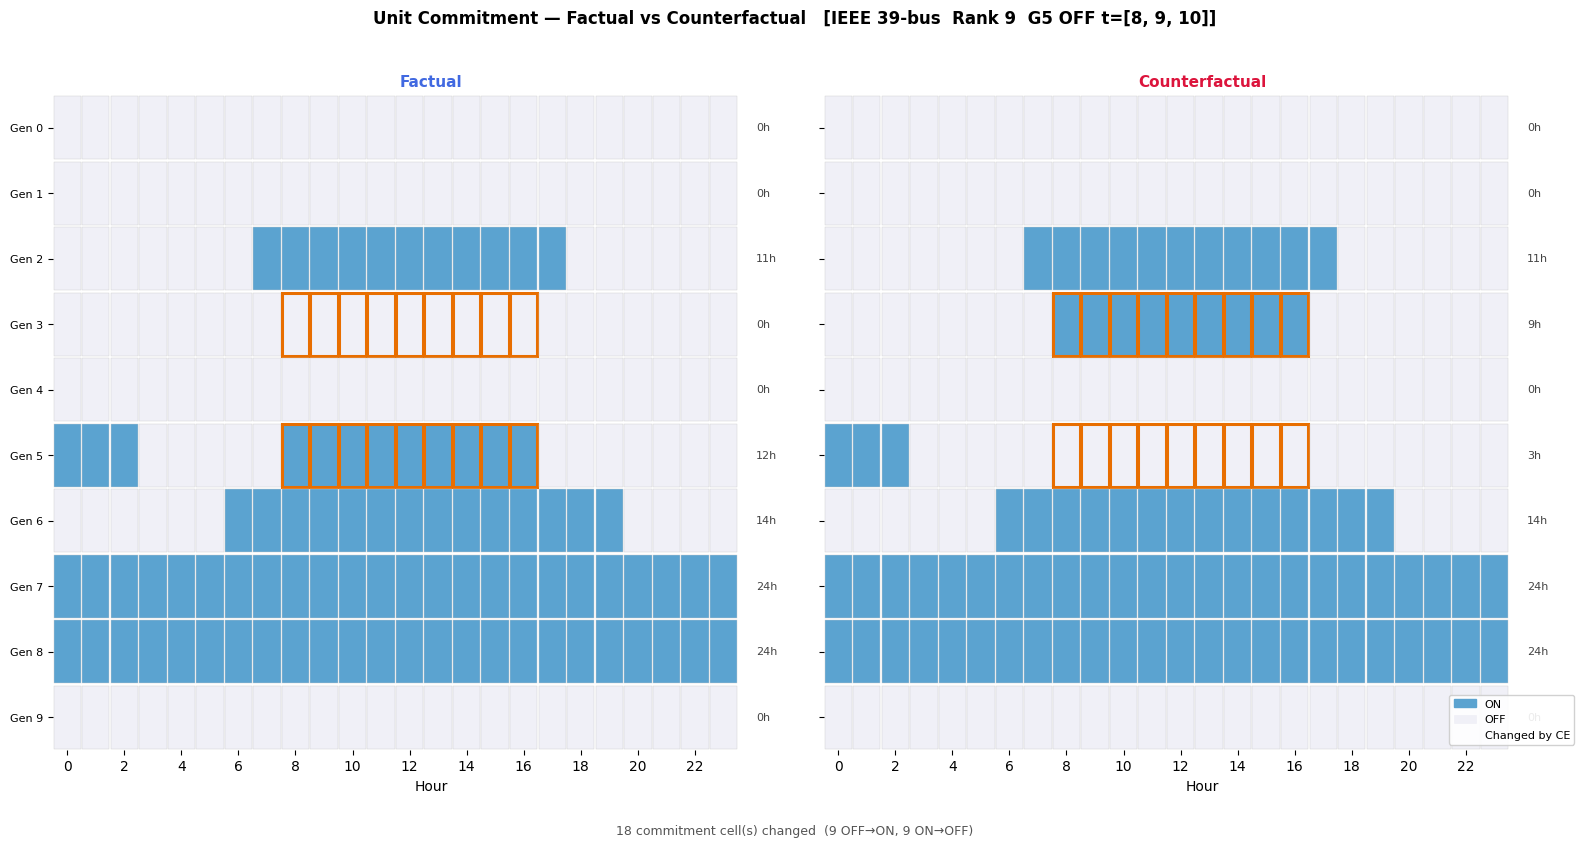


IEEE 39-bus  Rank 9  G5 OFF t=[8, 9, 10] — cost changes:
    G   orig_fuel     Δfuel   orig_nlod    Δno-load         ΔSU         ΔSD
    3       48.00     -0.04     1200.00        0.00        0.00        0.00

Rank 10  G3 ON t=[0, 1, 2, 3]  gap=4844
[NCX it=01] gap=1.86265e-09 | stop_tol=13.4 | MP_obj=16.1832 | foil_cost=13424422.04 | opt_cost=13424422.04
  → status: OPTIMAL

  ── Sanity Check Rank 10  G3 ON t=[0, 1, 2, 3] ──────────────────────────────
    g       param        base         new        Δabs        Δ%
  ----------------------------------------------------------
    0        fuel       7.000       7.000      +0.000     0.00%
    0     no_load   15000.000   15000.000      +0.000     0.00%
    0          SU  150000.000  150000.000      +0.000     0.00%
    0          SD   30000.000   30000.000      +0.000     0.00%
    1        fuel      32.000      32.000      +0.000     0.00%
    1     no_load    3000.000    3000.000      +0.000     0.00%
    1          SU   25000.000   

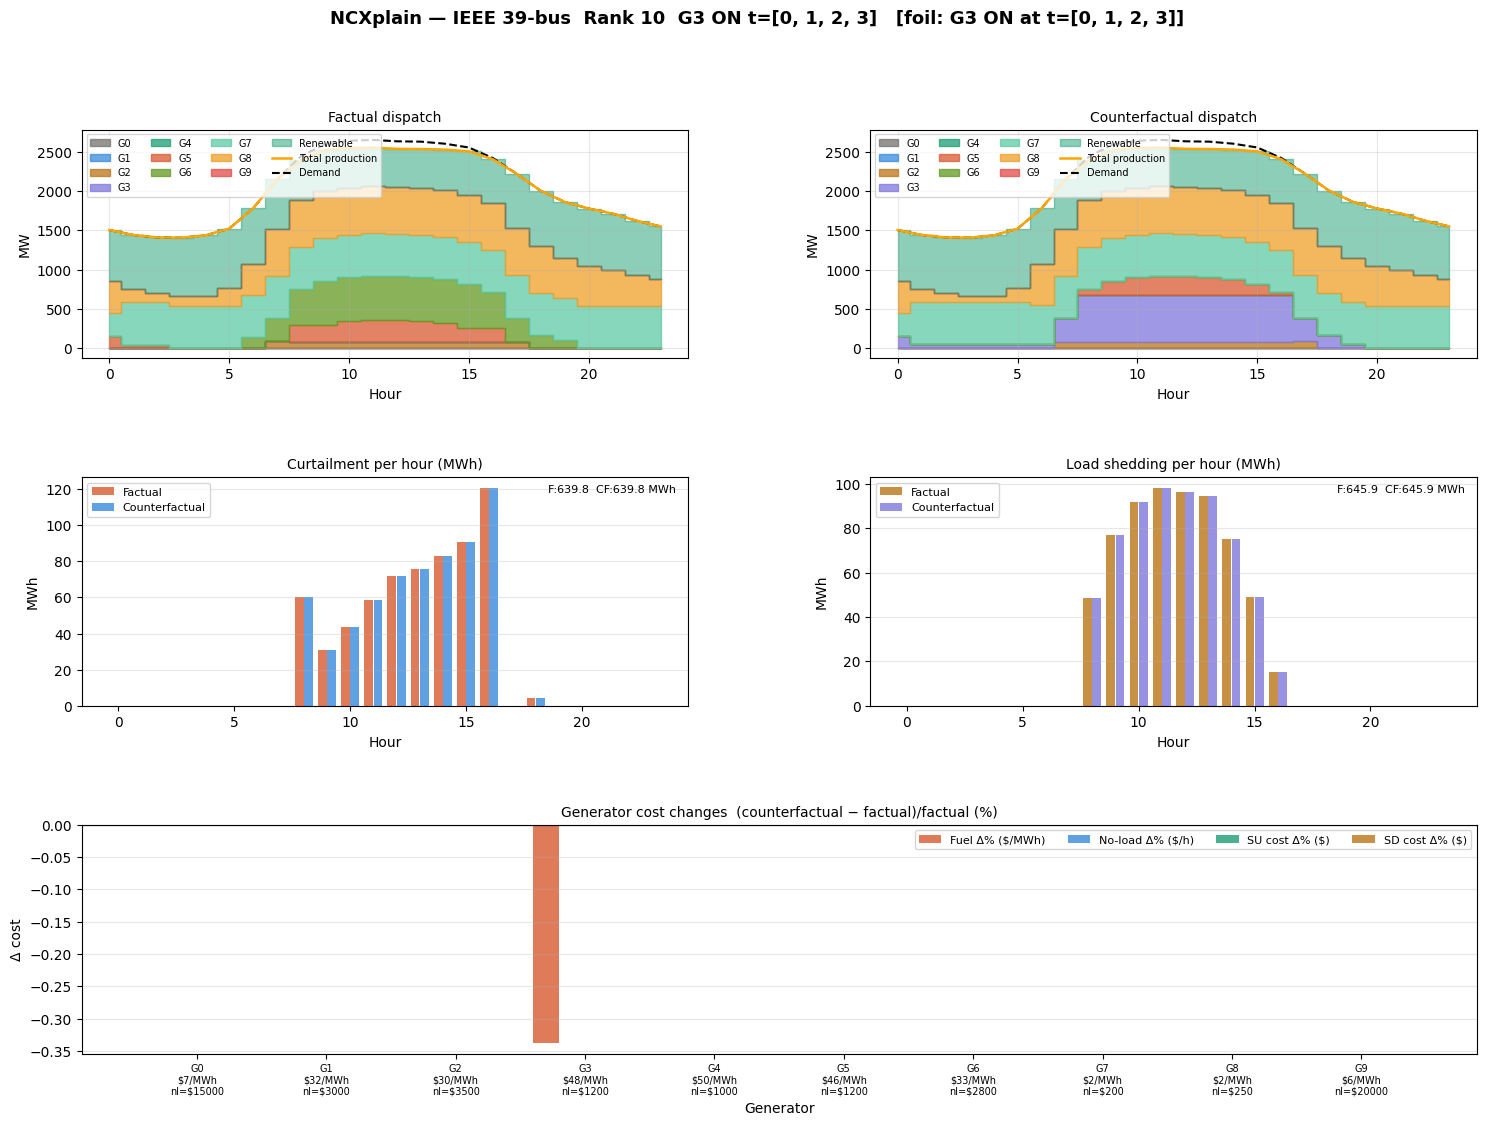

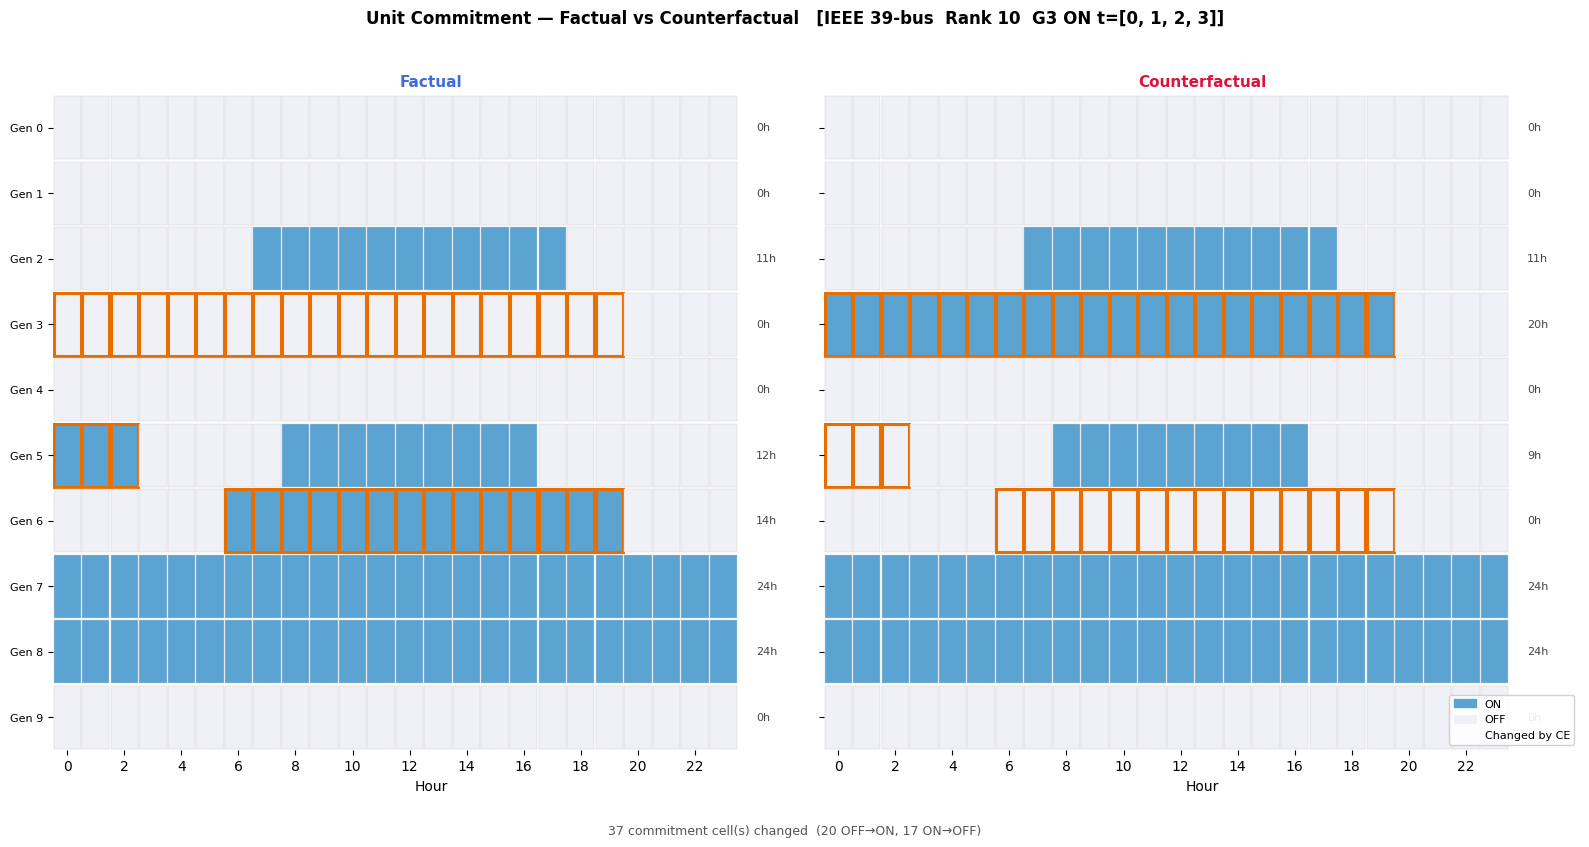


IEEE 39-bus  Rank 10  G3 ON t=[0, 1, 2, 3] — cost changes:
    G   orig_fuel     Δfuel   orig_nlod    Δno-load         ΔSU         ΔSD
    3       48.00     -0.34     1200.00        0.00        0.00        0.00

Rank 11  G4 ON t=[0, 1, 2, 3, 4]  gap=6817
[NCX it=01] gap=-3.72529e-09 | stop_tol=13.5 | MP_obj=19.5169 | foil_cost=13467563.27 | opt_cost=13467563.27
  → status: OPTIMAL

  ── Sanity Check Rank 11  G4 ON t=[0, 1, 2, 3, 4] ──────────────────────────────
    g       param        base         new        Δabs        Δ%
  ----------------------------------------------------------
    0        fuel       7.000       7.000      +0.000     0.00%
    0     no_load   15000.000   15000.000      +0.000     0.00%
    0          SU  150000.000  150000.000      +0.000     0.00%
    0          SD   30000.000   30000.000      +0.000     0.00%
    1        fuel      32.000      32.000      +0.000     0.00%
    1     no_load    3000.000    3000.000      +0.000     0.00%
    1          SU   250

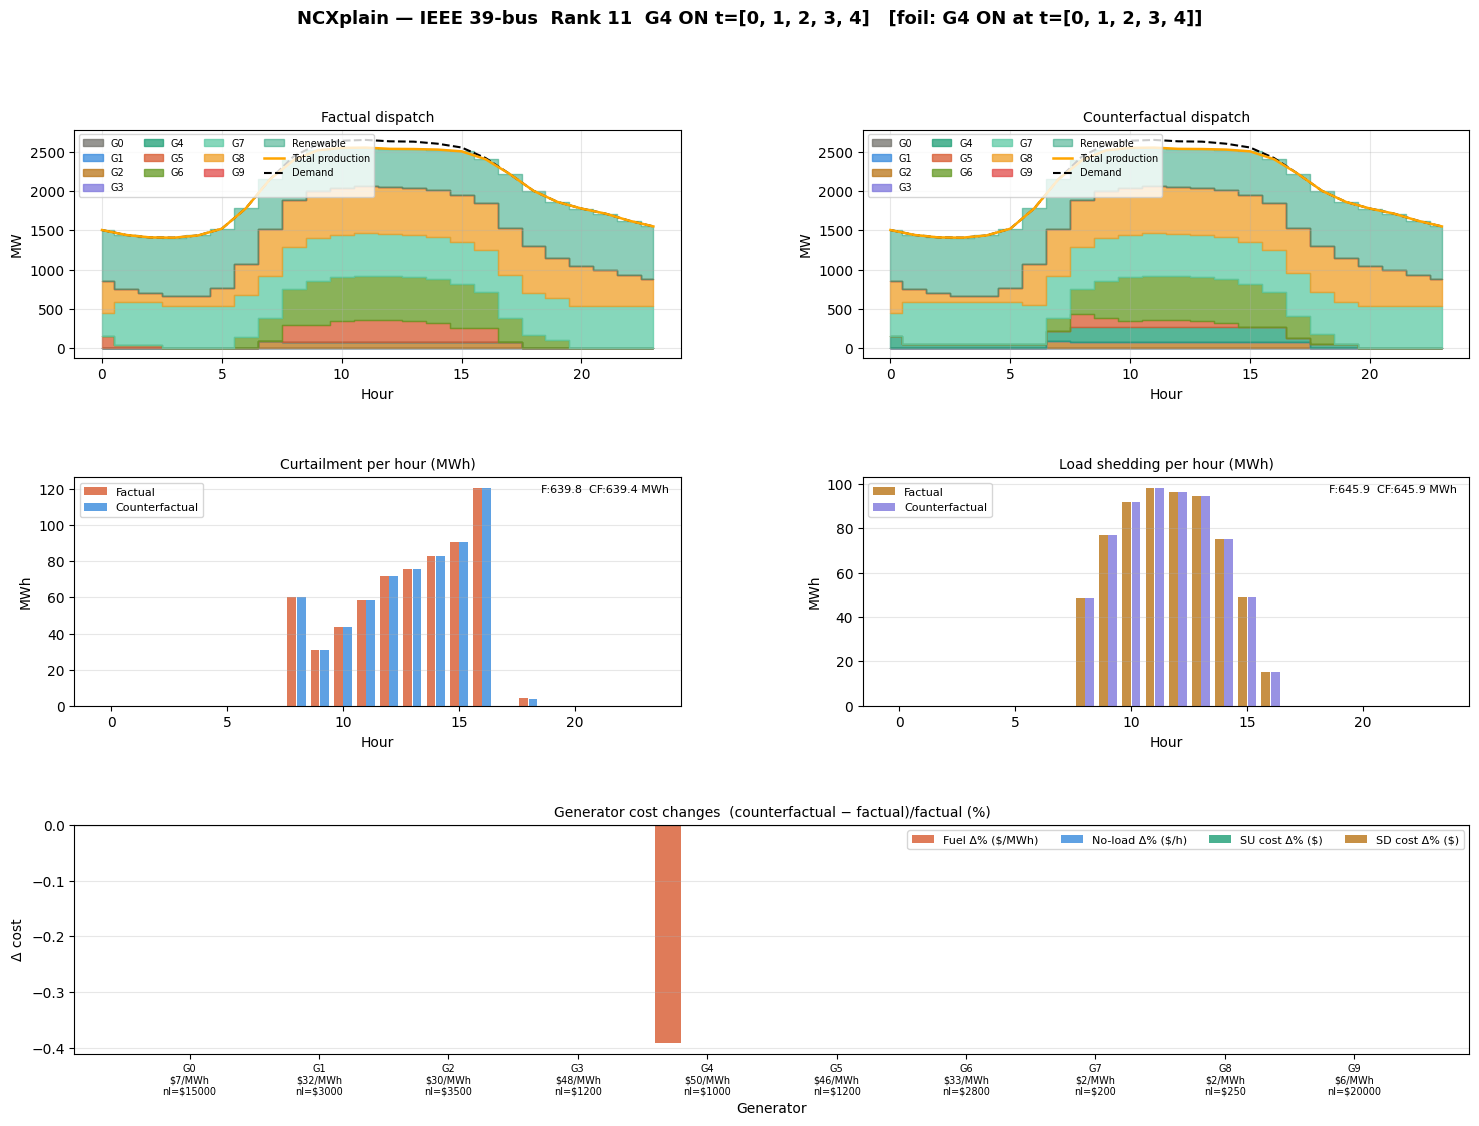

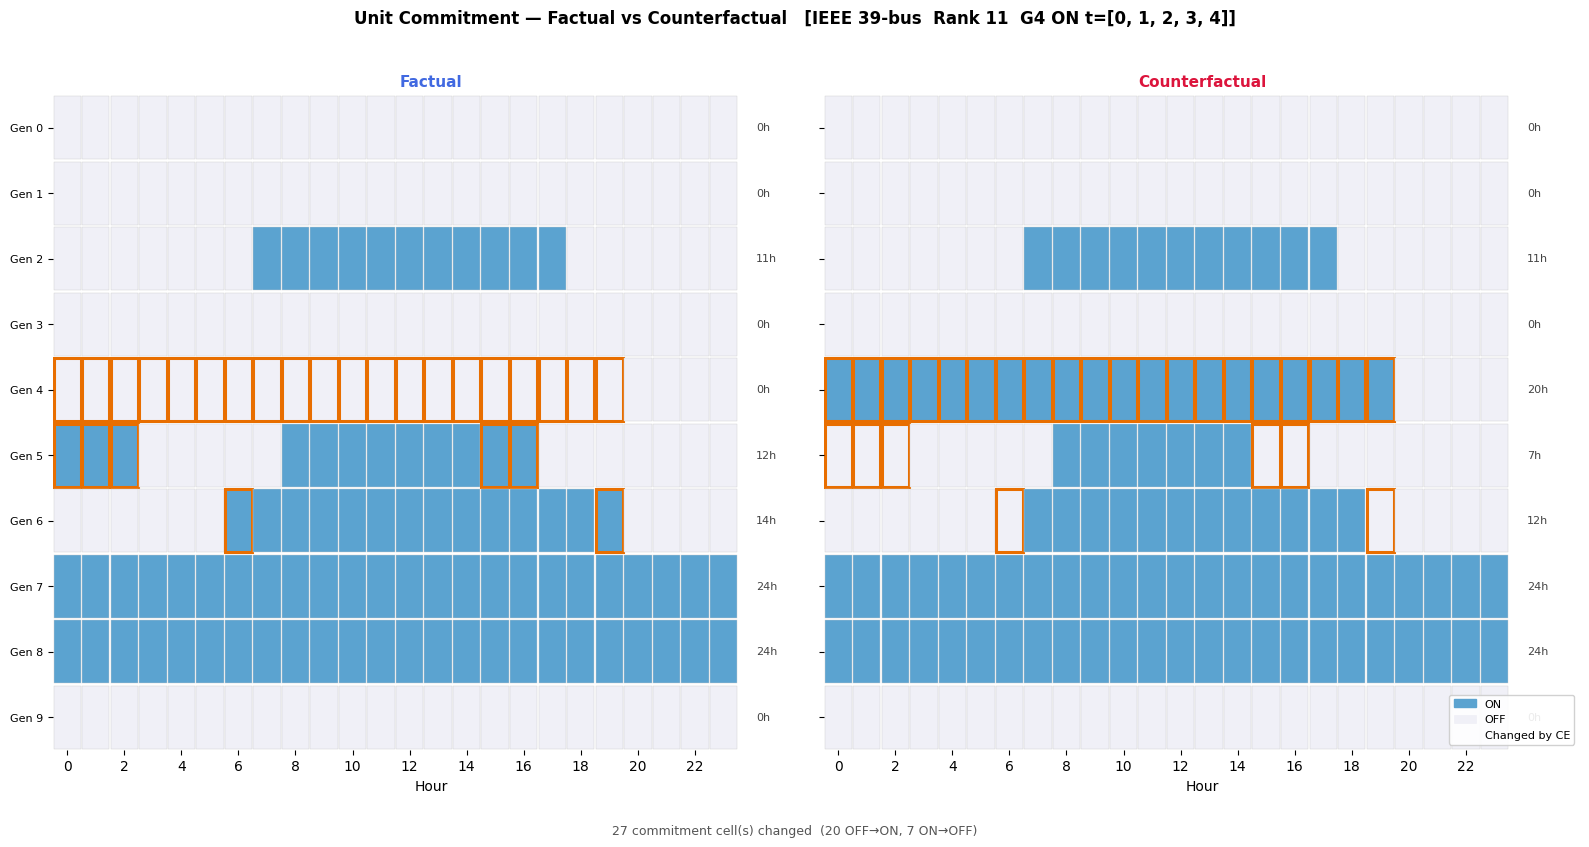


IEEE 39-bus  Rank 11  G4 ON t=[0, 1, 2, 3, 4] — cost changes:
    G   orig_fuel     Δfuel   orig_nlod    Δno-load         ΔSU         ΔSD
    4       50.00     -0.39     1000.00        0.00        0.00        0.00

Rank 12  G5 ON t=[17, 18, 19, 20, 21]  gap=6930
[NCX it=01] gap=3570 | stop_tol=13.3 | MP_obj=28.875 | foil_cost=13332593.84 | opt_cost=13329023.84
  → status: MP_INFEASIBLE

Rank 13  G3 ON t=[0, 1, 2, 3, 4]  gap=8319
[NCX it=01] gap=-5.58794e-09 | stop_tol=13.4 | MP_obj=23.8152 | foil_cost=13373573.21 | opt_cost=13373573.21
  → status: OPTIMAL

  ── Sanity Check Rank 13  G3 ON t=[0, 1, 2, 3, 4] ──────────────────────────────
    g       param        base         new        Δabs        Δ%
  ----------------------------------------------------------
    0        fuel       7.000       7.000      +0.000     0.00%
    0     no_load   15000.000   15000.000      +0.000     0.00%
    0          SU  150000.000  150000.000      +0.000     0.00%
    0          SD   30000.000   30000

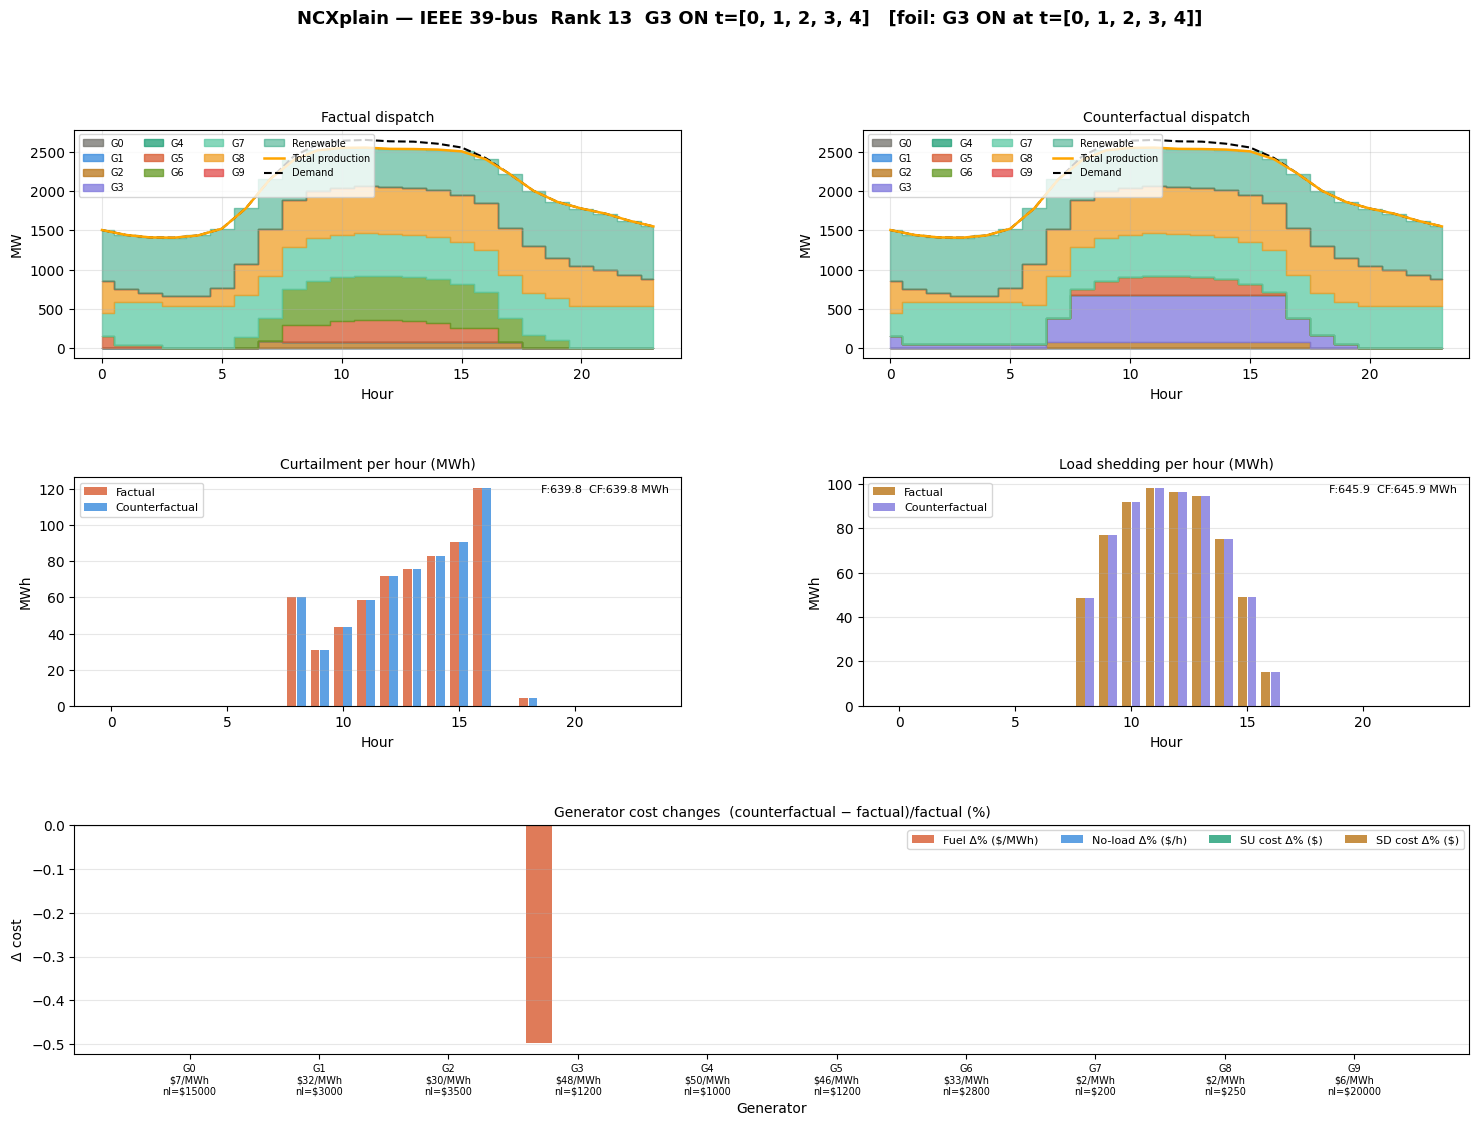

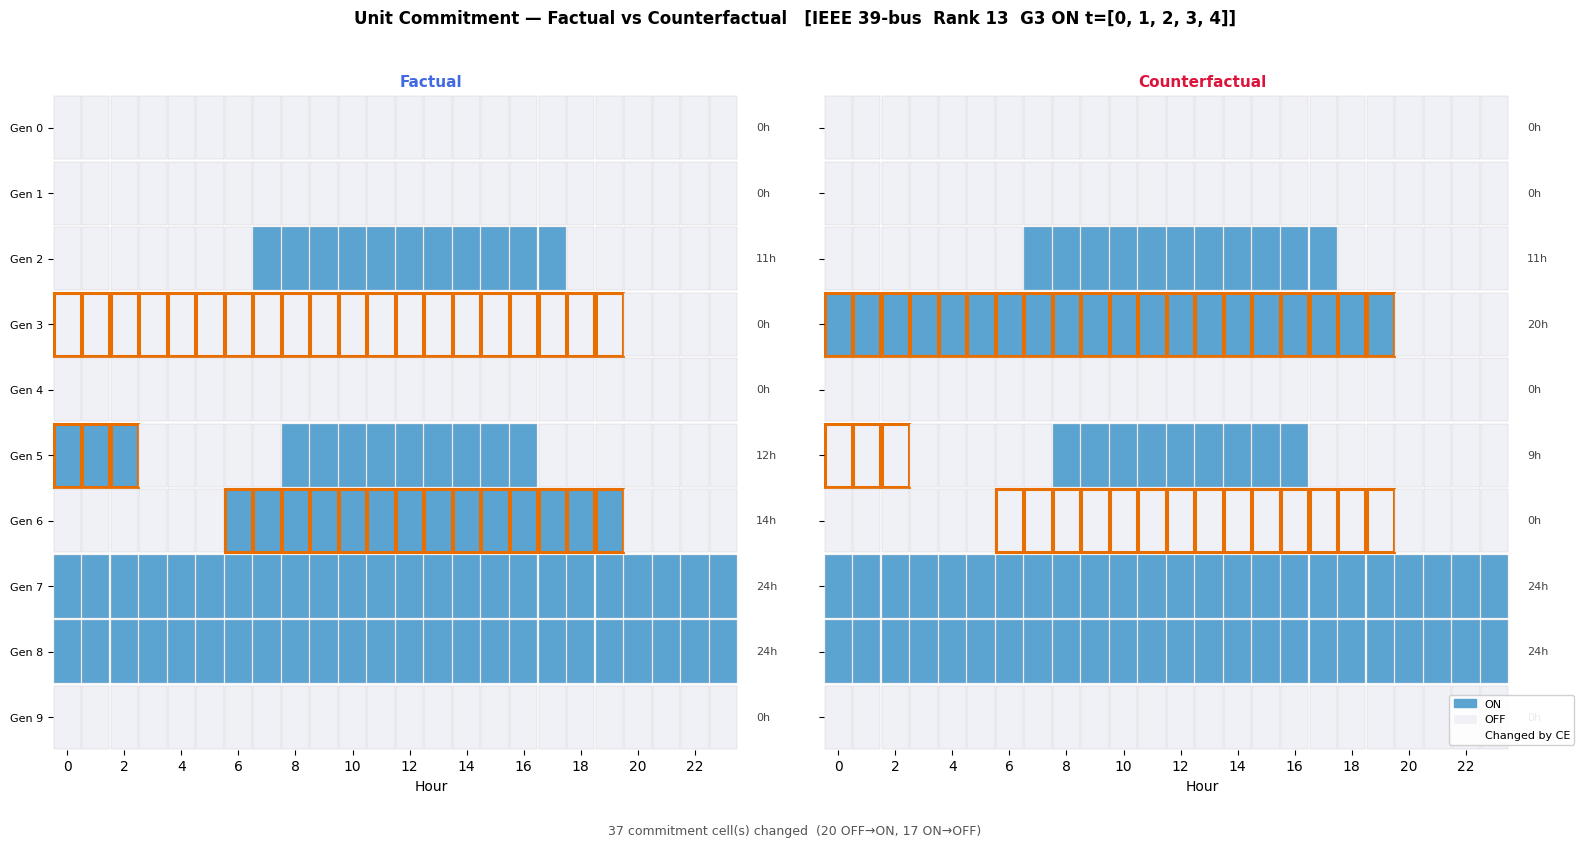


IEEE 39-bus  Rank 13  G3 ON t=[0, 1, 2, 3, 4] — cost changes:
    G   orig_fuel     Δfuel   orig_nlod    Δno-load         ΔSU         ΔSD
    3       48.00     -0.50     1200.00        0.00        0.00        0.00

IEEE 39-bus  NCXplain summary  (14 foils)
  Rank 0  G5 ON  t=[17, 18, 19]  gap=1050  →  OPTIMAL
  Rank 1  G5 ON  t=[3, 4, 5]  gap=1298  →  OPTIMAL
  Rank 2  G5 ON  t=[3, 4, 5, 6, 7]  gap=1298  →  OPTIMAL
  Rank 3  G5 ON  t=[3, 4, 5, 6]  gap=1298  →  OPTIMAL
  Rank 4  G3 ON  t=[0, 1, 2]  gap=1369  →  OPTIMAL
  Rank 5  G4 ON  t=[0, 1, 2, 3]  gap=3442  →  OPTIMAL
  Rank 6  G5 ON  t=[17, 18, 19, 20]  gap=3990  →  MP_INFEASIBLE
  Rank 7  G5 OFF  t=[8, 9, 10, 11]  gap=4204  →  OPTIMAL
  Rank 8  G5 OFF  t=[8, 9, 10, 11, 12]  gap=4204  →  OPTIMAL
  Rank 9  G5 OFF  t=[8, 9, 10]  gap=4204  →  OPTIMAL
  Rank 10  G3 ON  t=[0, 1, 2, 3]  gap=4844  →  OPTIMAL
  Rank 11  G4 ON  t=[0, 1, 2, 3, 4]  gap=6817  →  OPTIMAL
  Rank 12  G5 ON  t=[17, 18, 19, 20, 21]  gap=6930  →  MP_INFEASIBLE
  Ra

In [17]:
# ── Cell: run NCXplain for all good 39-bus foil candidates ────────────────

assert candidates_39, "Run Section 2 first for IEEE 39-bus"

results_39 = []
for rank, (gap, foil_g, foil_times, foil_type) in enumerate(candidates_39):
    foil_fn = foil_force_off(foil_g, foil_times) if foil_type == "OFF" \
              else foil_force_on(foil_g, foil_times)

    print(f"\n{'='*60}")
    print(f"Rank {rank}  G{foil_g} {foil_type} t={foil_times}  gap={gap:.0f}")
    print(f"{'='*60}")

    out = run_ncxplain_uc(
        data=DATA_39,
        window_size=int(DATA_39.T),
        per_bus_neutrality=True,
        foil_fn=foil_fn,
        mutables={"gen_costs"},
        bounds={"fuel":    (0, 500),
                "no_load": (0, 5000),
                "su":      (0, 100_000),
                "sd":      (0, 100_000)},
        perturbation_beta=0.9,
        weights={"gen_costs": 1.0},
        verbose=True,
    )

    results_39.append({
        "rank": rank, "gap": gap,
        "foil_g": foil_g, "foil_times": foil_times, "foil_type": foil_type,
        "status": out["status"], "out": out,
    })
    print(f"  → status: {out['status']}")

    if str(out.get("status", "")).upper() == "OPTIMAL":
        sanity_check(
            DATA_39, out,
            foil_g=foil_g, foil_times=foil_times, foil_type=foil_type,
            label=f"Rank {rank}  G{foil_g} {foil_type} t={foil_times}",
        )
        print(f"\nIEEE 39-bus — output keys: {list(out.keys())}")
        plot_ncxplain_results(
            DATA_39, out,
            label=f"IEEE 39-bus  Rank {rank}  G{foil_g} {foil_type} t={foil_times}",
            foil_g=foil_g, foil_times=foil_times, foil_type=foil_type,
        )

# ── summary ───────────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"IEEE 39-bus  NCXplain summary  ({len(results_39)} foils)")
print(f"{'='*60}")
for r in results_39:
    print(f"  Rank {r['rank']}  G{r['foil_g']} {r['foil_type']}"
          f"  t={r['foil_times']}  gap={r['gap']:.0f}  →  {r['status']}")

### 3.5 · IEEE 57-bus


Rank 0  G5 OFF t=[0, 1, 2]  gap=298140
[NCX it=01] gap=-4.37722e-08 | stop_tol=4.09 | MP_obj=265573 | foil_cost=4092720.23 | opt_cost=4092720.23
  → status: OPTIMAL

IEEE 57-bus — output keys: ['status', 'iters', 'mutables', 'bounds', 'weights', 'z_foil', 'z_opt', 'dTx_foil', 'dTx_opt', 'gap', 'stop_tol', 'mp_details', 'sol_factual', 'sol_foil', 'sol_opt', 'pi_plus_new', 'pi_minus_new', 'curt_cost_new', 'fuel_cost_new', 'no_load_cost_new', 'su_cost_new', 'sd_cost_new']


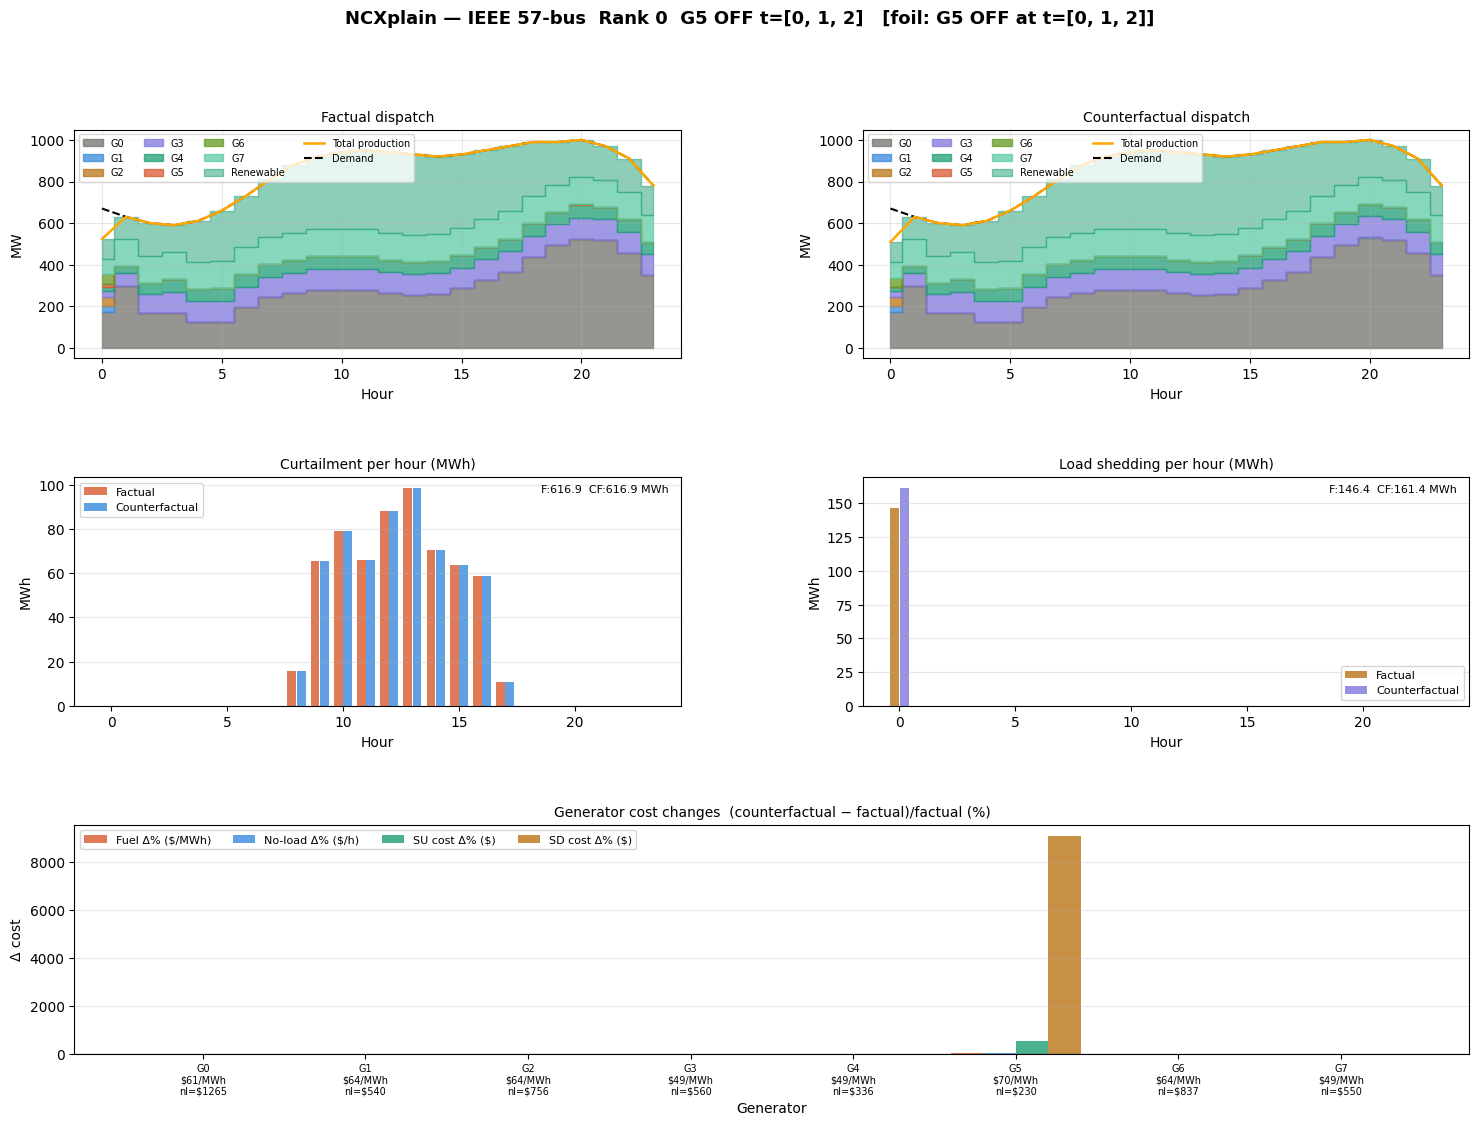

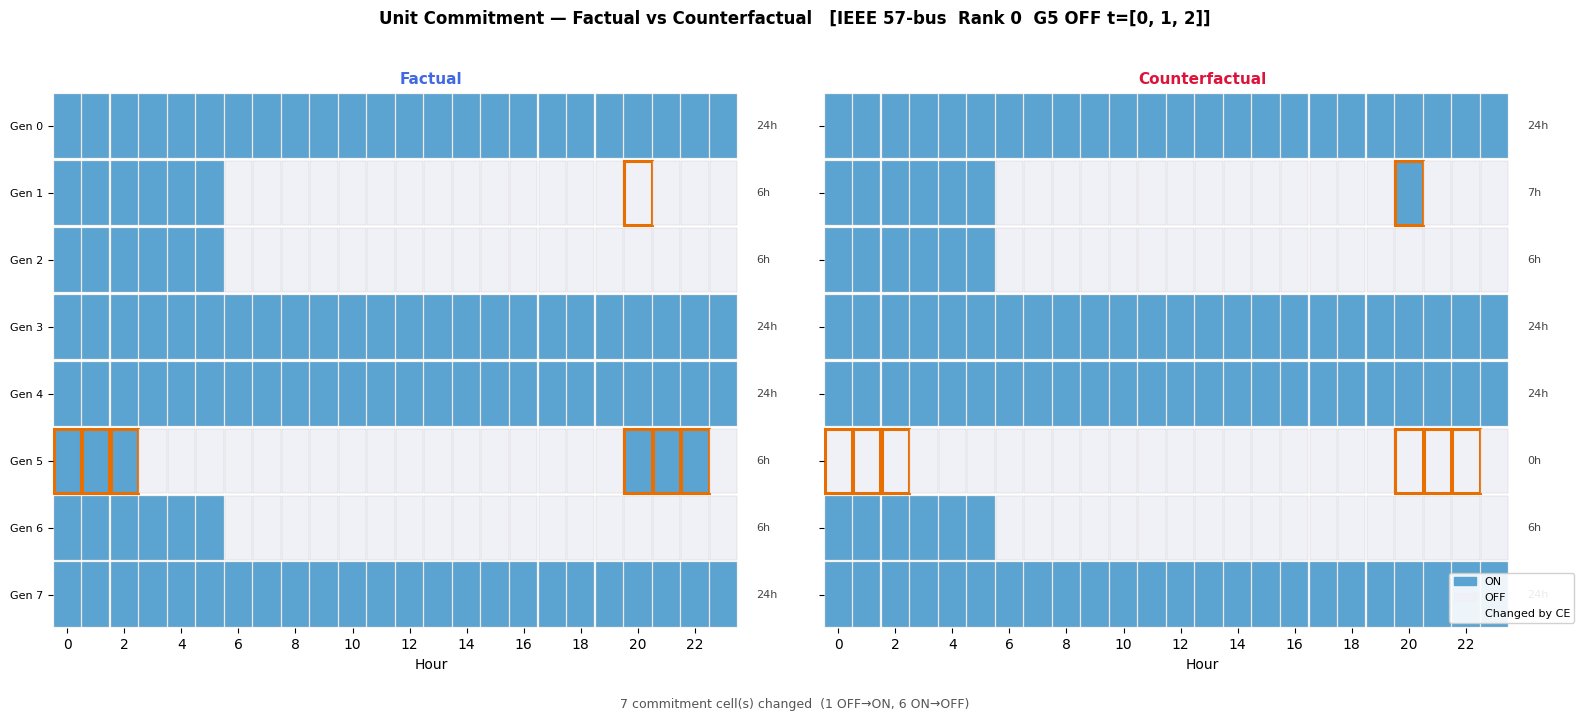


IEEE 57-bus  Rank 0  G5 OFF t=[0, 1, 2] — cost changes:
    G   orig_fuel     Δfuel   orig_nlod    Δno-load         ΔSU         ΔSD
    5       69.50     13.39      230.00       42.48      522.81     9089.91

Rank 1  G4 OFF t=[0, 1, 2]  gap=360054
[NCX it=01] gap=322769 | stop_tol=3.25 | MP_obj=2005.78 | foil_cost=3569099.21 | opt_cost=3246330.21
[NCX it=02] gap=-4.33065e-08 | stop_tol=4.16 | MP_obj=322392 | foil_cost=4163601.75 | opt_cost=4163601.75
  → status: OPTIMAL

IEEE 57-bus — output keys: ['status', 'iters', 'mutables', 'bounds', 'weights', 'z_foil', 'z_opt', 'dTx_foil', 'dTx_opt', 'gap', 'stop_tol', 'mp_details', 'sol_factual', 'sol_foil', 'sol_opt', 'pi_plus_new', 'pi_minus_new', 'curt_cost_new', 'fuel_cost_new', 'no_load_cost_new', 'su_cost_new', 'sd_cost_new']


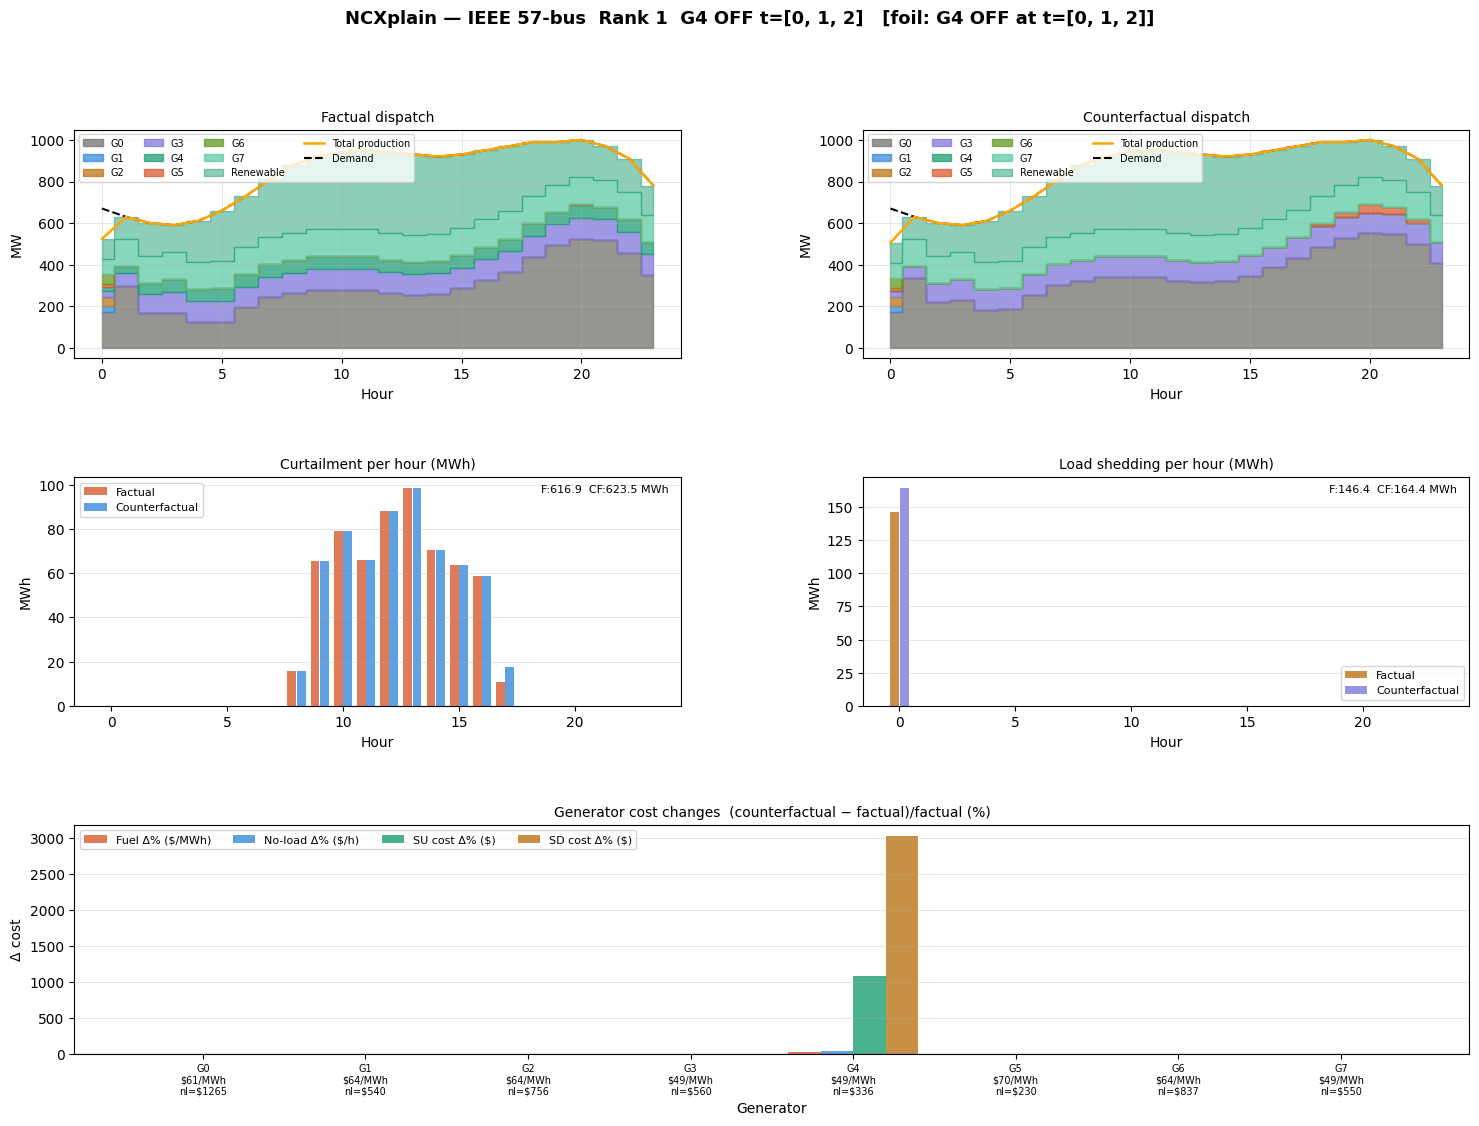

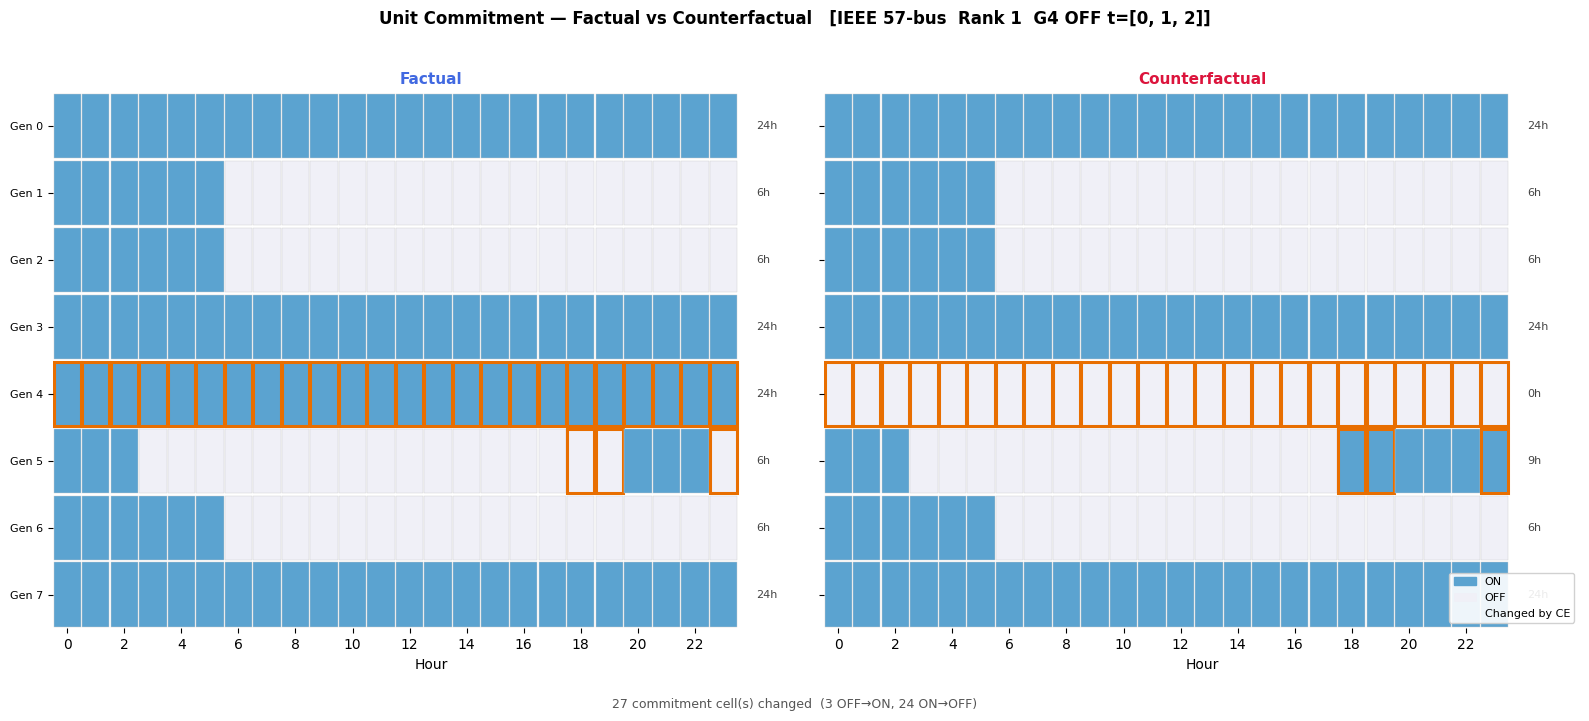


IEEE 57-bus  Rank 1  G4 OFF t=[0, 1, 2] — cost changes:
    G   orig_fuel     Δfuel   orig_nlod    Δno-load         ΔSU         ΔSD
    4       49.00     19.41      336.00       28.76     1074.27     3026.03

Rank 2  G4 OFF t=[0, 1, 2, 3]  gap=360438
[NCX it=01] gap=330854 | stop_tol=3.83 | MP_obj=1501.82 | foil_cost=4163601.75 | opt_cost=3832747.60
[NCX it=02] gap=3.25963e-08 | stop_tol=4.16 | MP_obj=322392 | foil_cost=4163601.75 | opt_cost=4163601.75
  → status: OPTIMAL

IEEE 57-bus — output keys: ['status', 'iters', 'mutables', 'bounds', 'weights', 'z_foil', 'z_opt', 'dTx_foil', 'dTx_opt', 'gap', 'stop_tol', 'mp_details', 'sol_factual', 'sol_foil', 'sol_opt', 'pi_plus_new', 'pi_minus_new', 'curt_cost_new', 'fuel_cost_new', 'no_load_cost_new', 'su_cost_new', 'sd_cost_new']


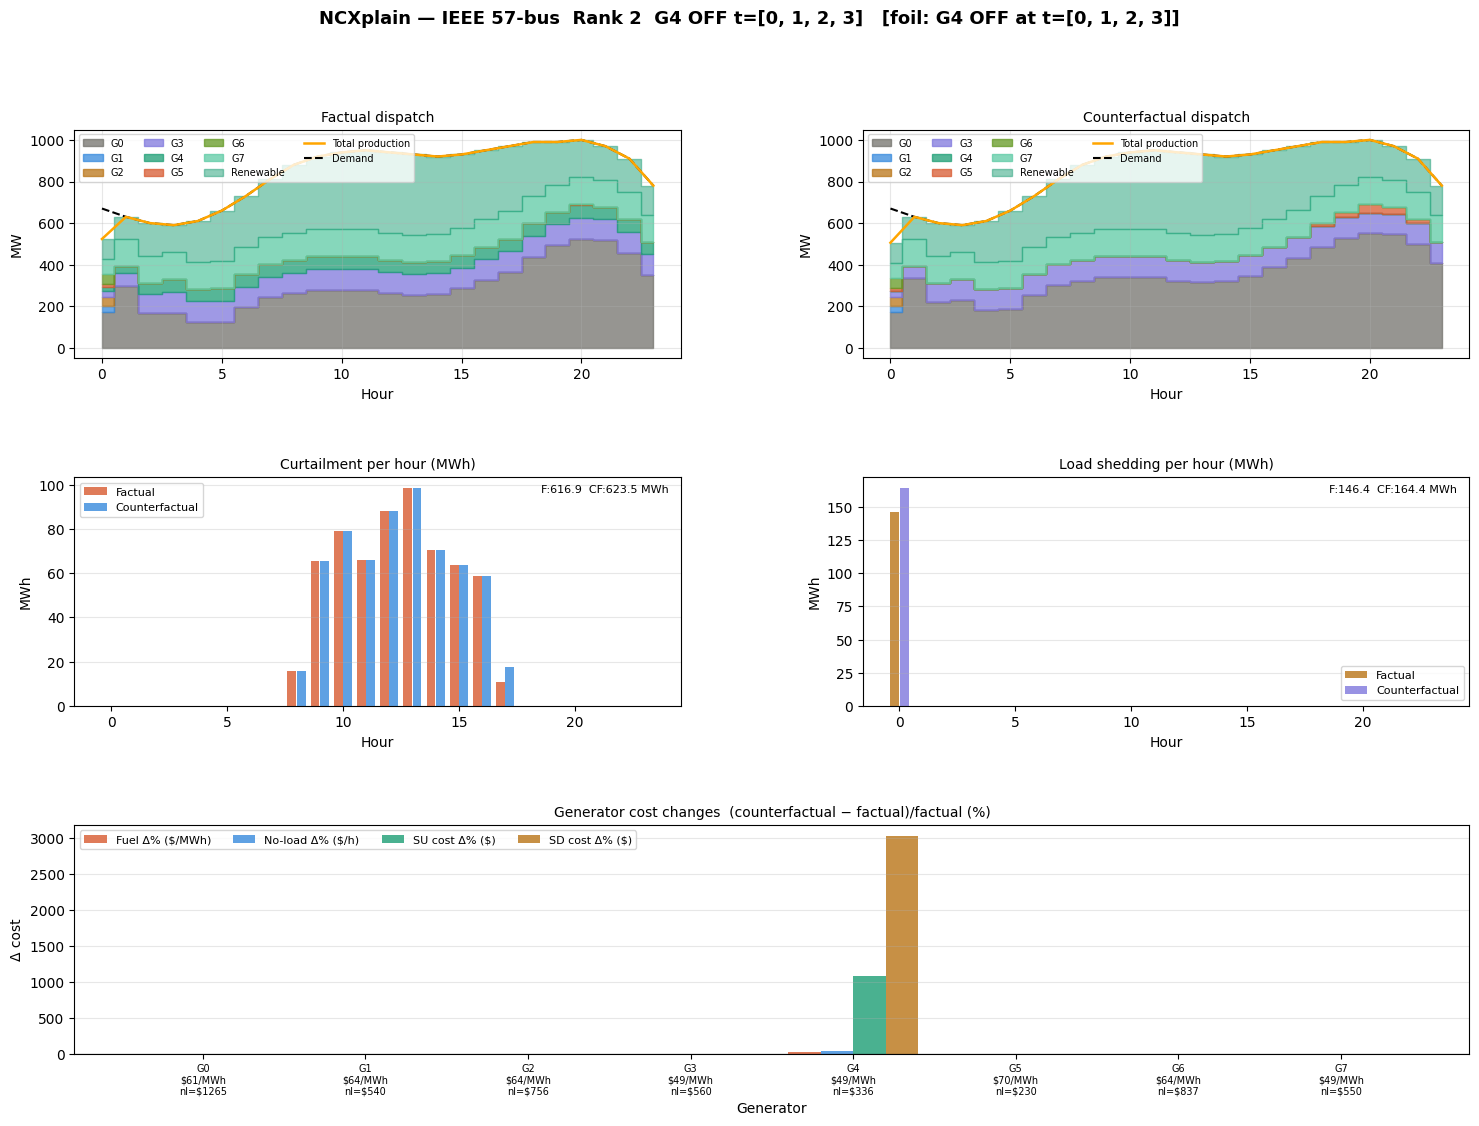

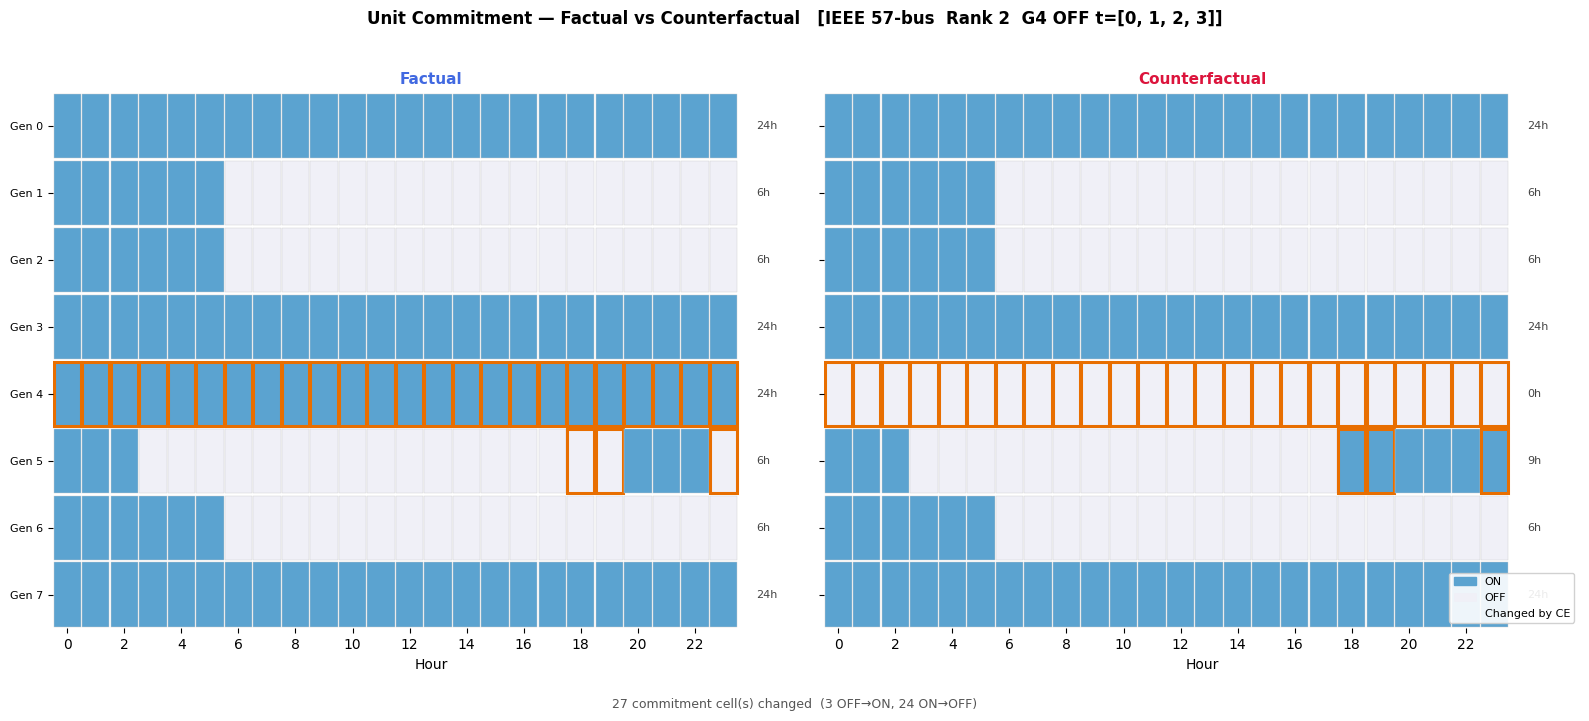


IEEE 57-bus  Rank 2  G4 OFF t=[0, 1, 2, 3] — cost changes:
    G   orig_fuel     Δfuel   orig_nlod    Δno-load         ΔSU         ΔSD
    4       49.00     19.41      336.00       28.76     1074.27     3026.03

Rank 3  G4 OFF t=[0, 1, 2, 3, 4]  gap=360822
[NCX it=01] gap=336238 | stop_tol=3.83 | MP_obj=1202.74 | foil_cost=4163601.75 | opt_cost=3827364.07
[NCX it=02] gap=-2.32831e-08 | stop_tol=4.16 | MP_obj=322392 | foil_cost=4163601.75 | opt_cost=4163601.75
  → status: OPTIMAL

IEEE 57-bus — output keys: ['status', 'iters', 'mutables', 'bounds', 'weights', 'z_foil', 'z_opt', 'dTx_foil', 'dTx_opt', 'gap', 'stop_tol', 'mp_details', 'sol_factual', 'sol_foil', 'sol_opt', 'pi_plus_new', 'pi_minus_new', 'curt_cost_new', 'fuel_cost_new', 'no_load_cost_new', 'su_cost_new', 'sd_cost_new']


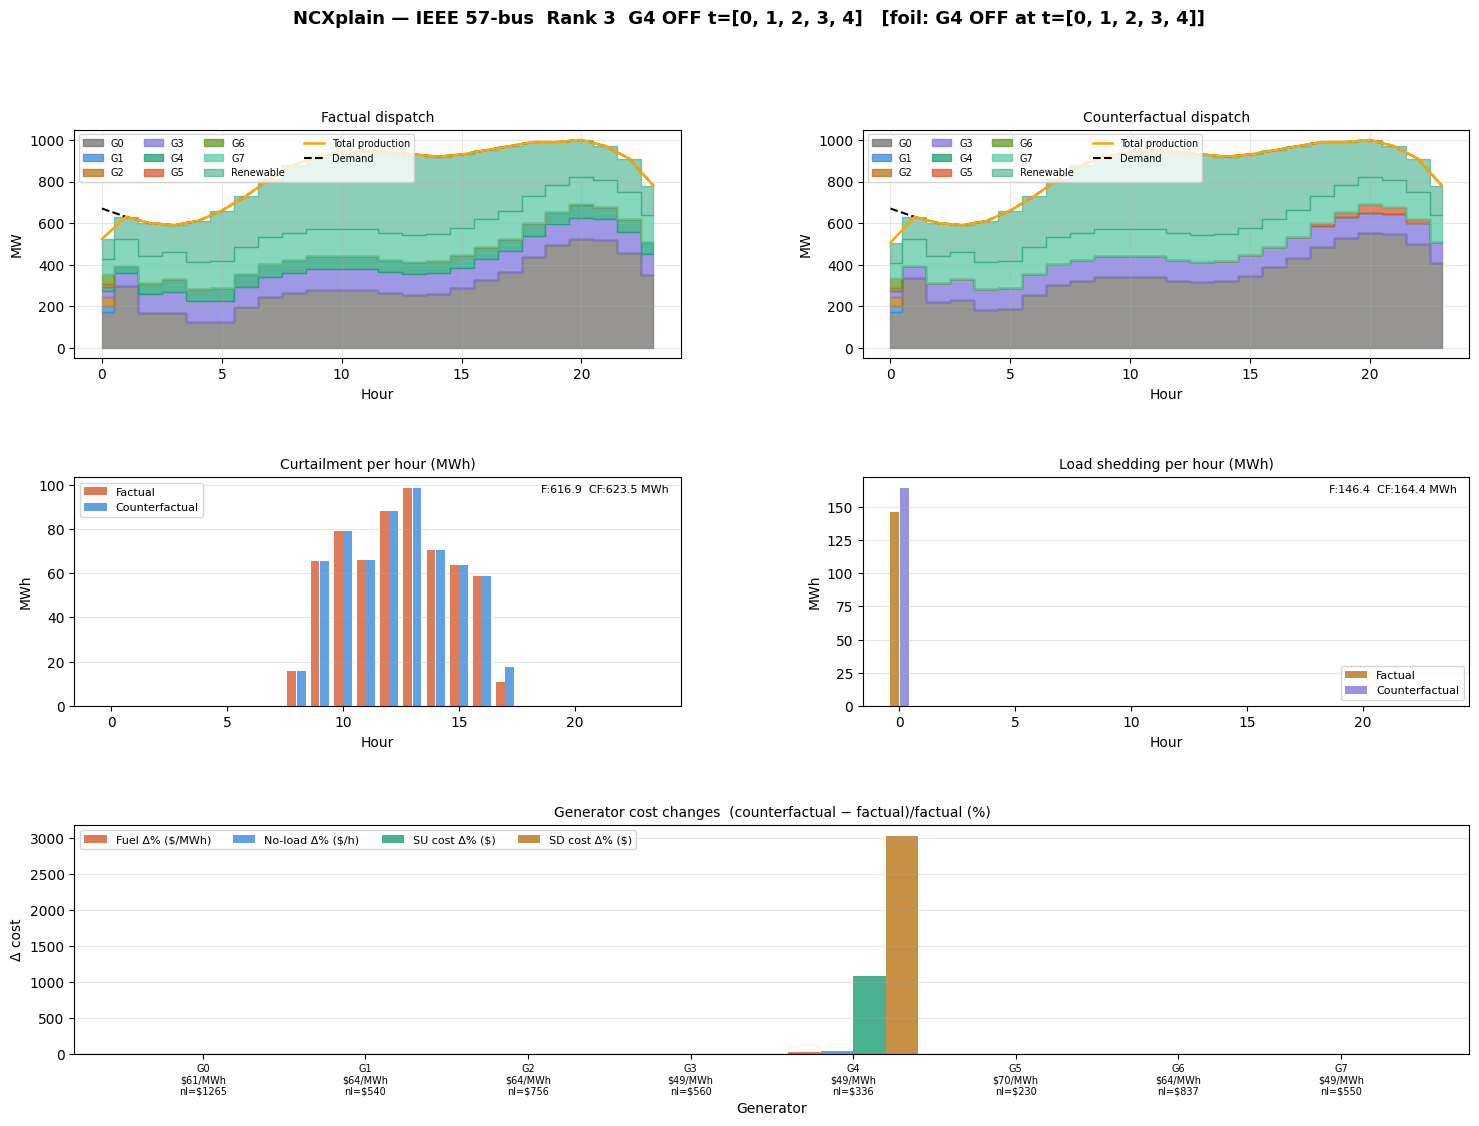

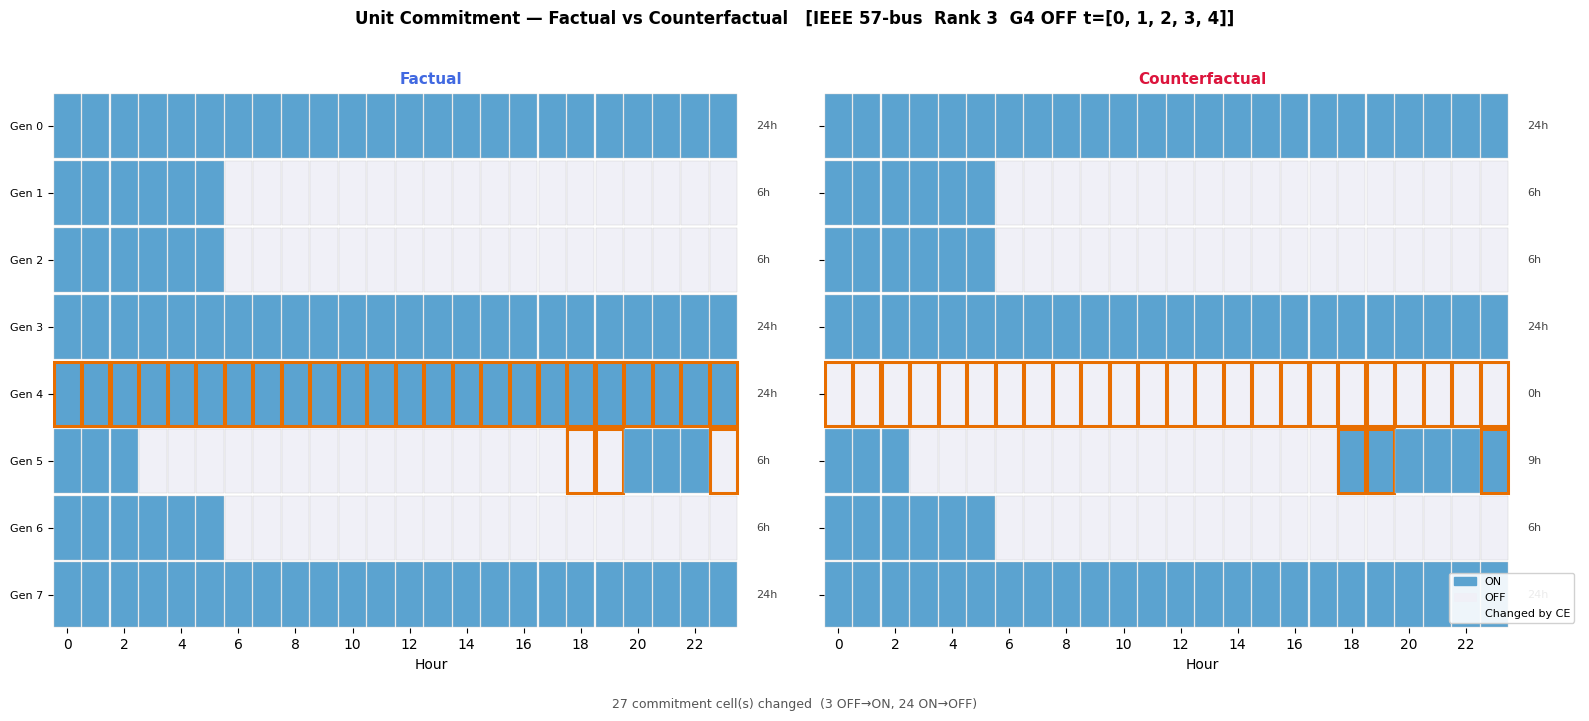


IEEE 57-bus  Rank 3  G4 OFF t=[0, 1, 2, 3, 4] — cost changes:
    G   orig_fuel     Δfuel   orig_nlod    Δno-load         ΔSU         ΔSD
    4       49.00     19.41      336.00       28.76     1074.27     3026.03

Rank 4  G1 OFF t=[0, 1, 2, 3, 4, 5]  gap=594333
[NCX it=01] gap=40000 | stop_tol=4.35 | MP_obj=440880 | foil_cost=4388715.16 | opt_cost=4348715.16
[NCX it=02] gap=-4.65661e-08 | stop_tol=4.39 | MP_obj=440880 | foil_cost=4388715.16 | opt_cost=4388715.16
  → status: OPTIMAL

IEEE 57-bus — output keys: ['status', 'iters', 'mutables', 'bounds', 'weights', 'z_foil', 'z_opt', 'dTx_foil', 'dTx_opt', 'gap', 'stop_tol', 'mp_details', 'sol_factual', 'sol_foil', 'sol_opt', 'pi_plus_new', 'pi_minus_new', 'curt_cost_new', 'fuel_cost_new', 'no_load_cost_new', 'su_cost_new', 'sd_cost_new']


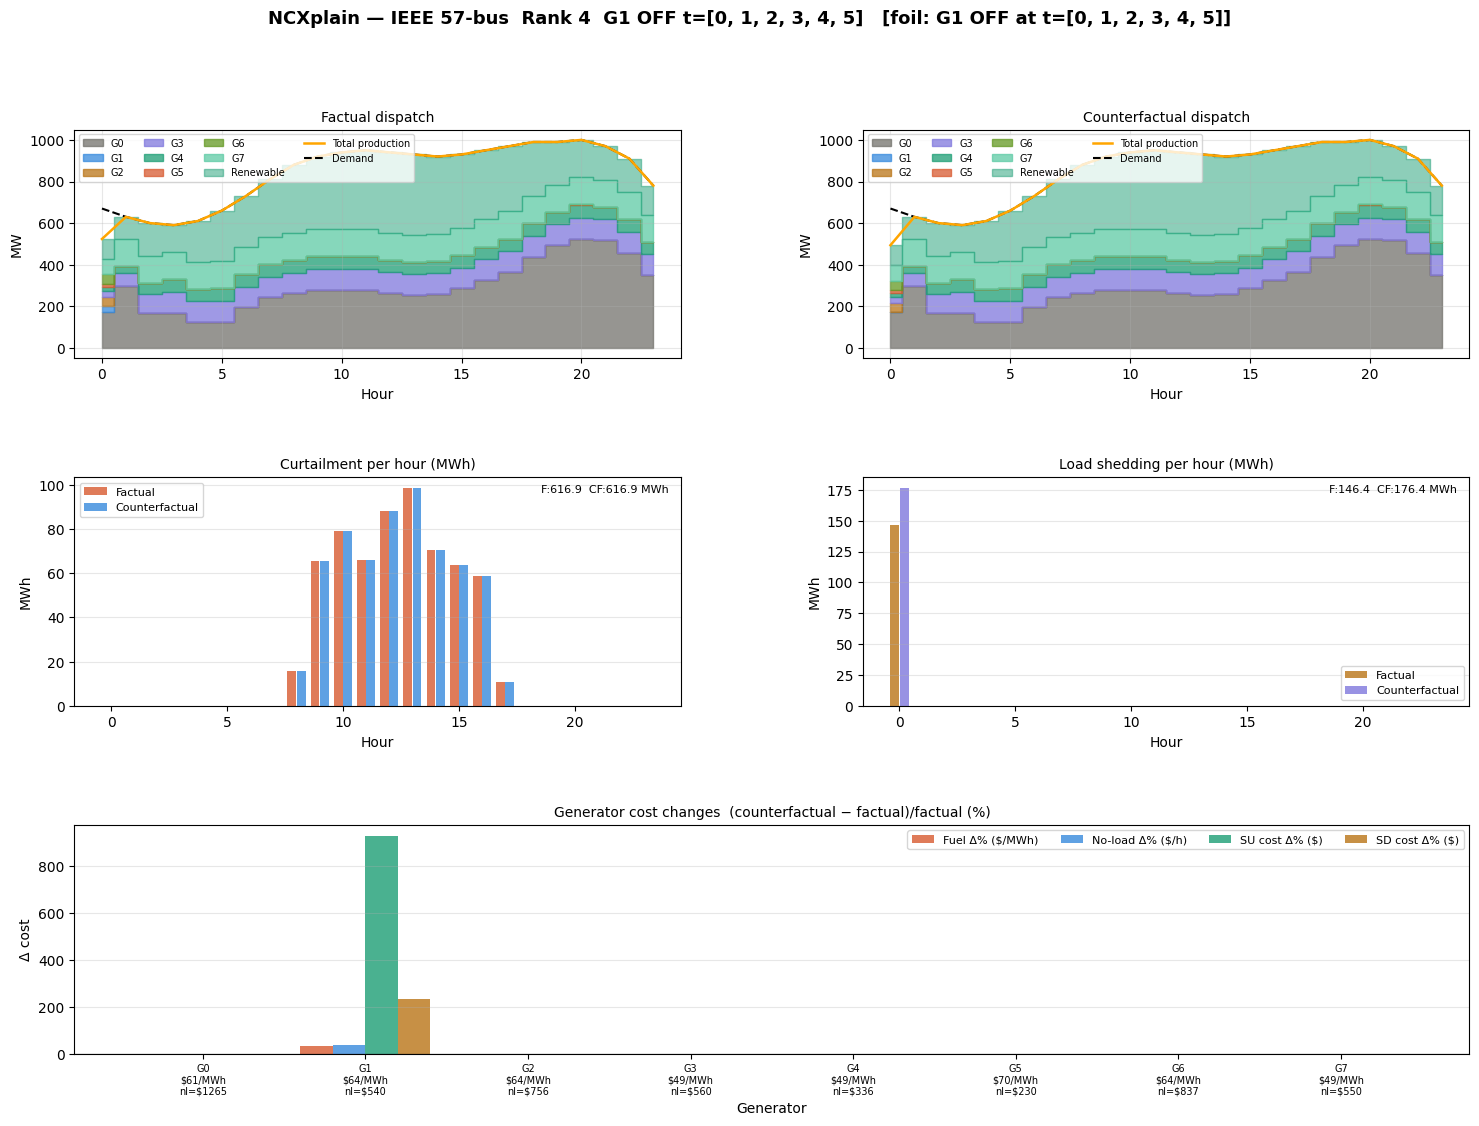

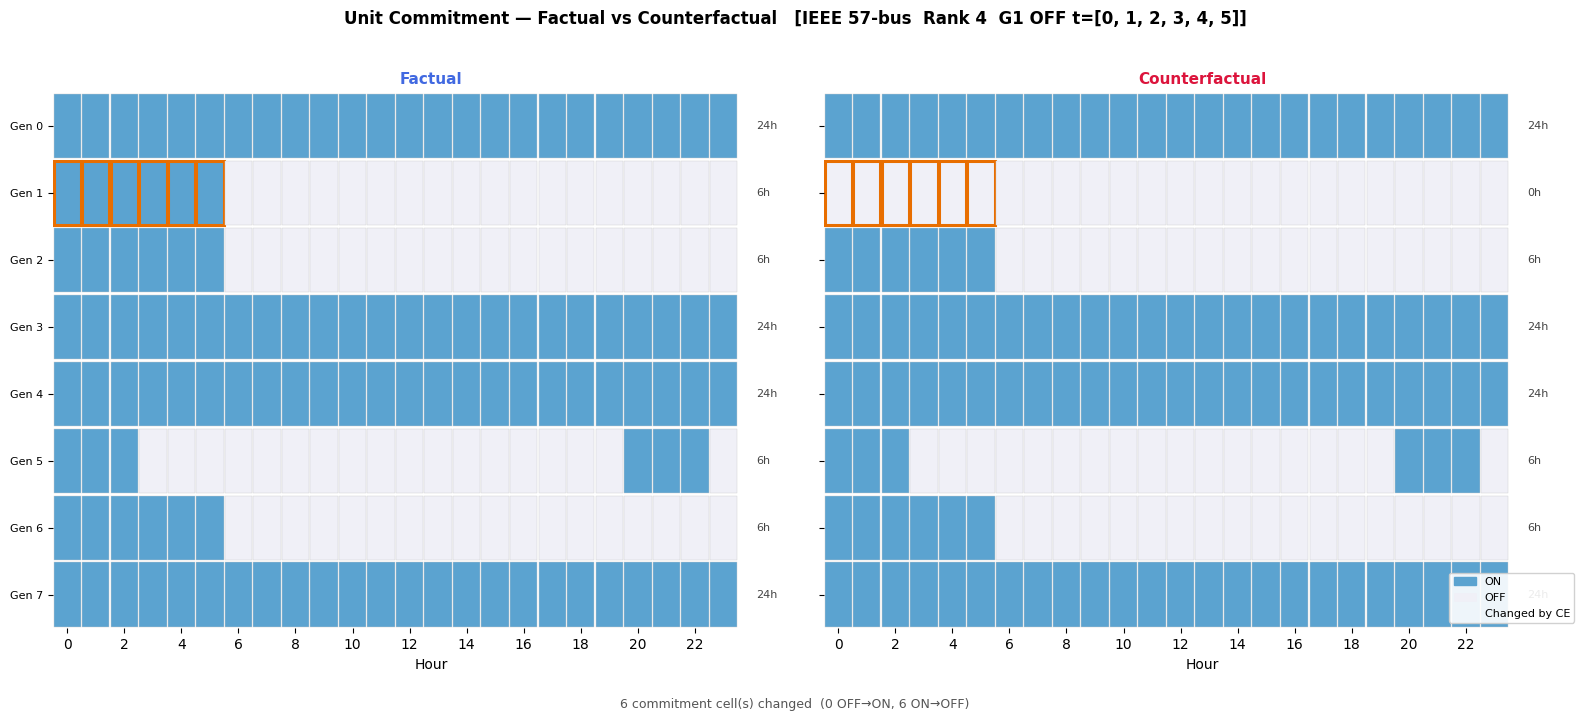


IEEE 57-bus  Rank 4  G1 OFF t=[0, 1, 2, 3, 4, 5] — cost changes:
    G   orig_fuel     Δfuel   orig_nlod    Δno-load         ΔSU         ΔSD
    1       63.70     30.40      540.00       36.04      929.23      231.56

Rank 5  G3 OFF t=[0, 1, 2]  gap=600133
[NCX it=01] gap=537949 | stop_tol=3.23 | MP_obj=2009.35 | foil_cost=3768976.47 | opt_cost=3231027.47
[NCX it=02] gap=-1.30385e-08 | stop_tol=4.41 | MP_obj=501020 | foil_cost=4411383.51 | opt_cost=4411383.51
  → status: OPTIMAL

IEEE 57-bus — output keys: ['status', 'iters', 'mutables', 'bounds', 'weights', 'z_foil', 'z_opt', 'dTx_foil', 'dTx_opt', 'gap', 'stop_tol', 'mp_details', 'sol_factual', 'sol_foil', 'sol_opt', 'pi_plus_new', 'pi_minus_new', 'curt_cost_new', 'fuel_cost_new', 'no_load_cost_new', 'su_cost_new', 'sd_cost_new']


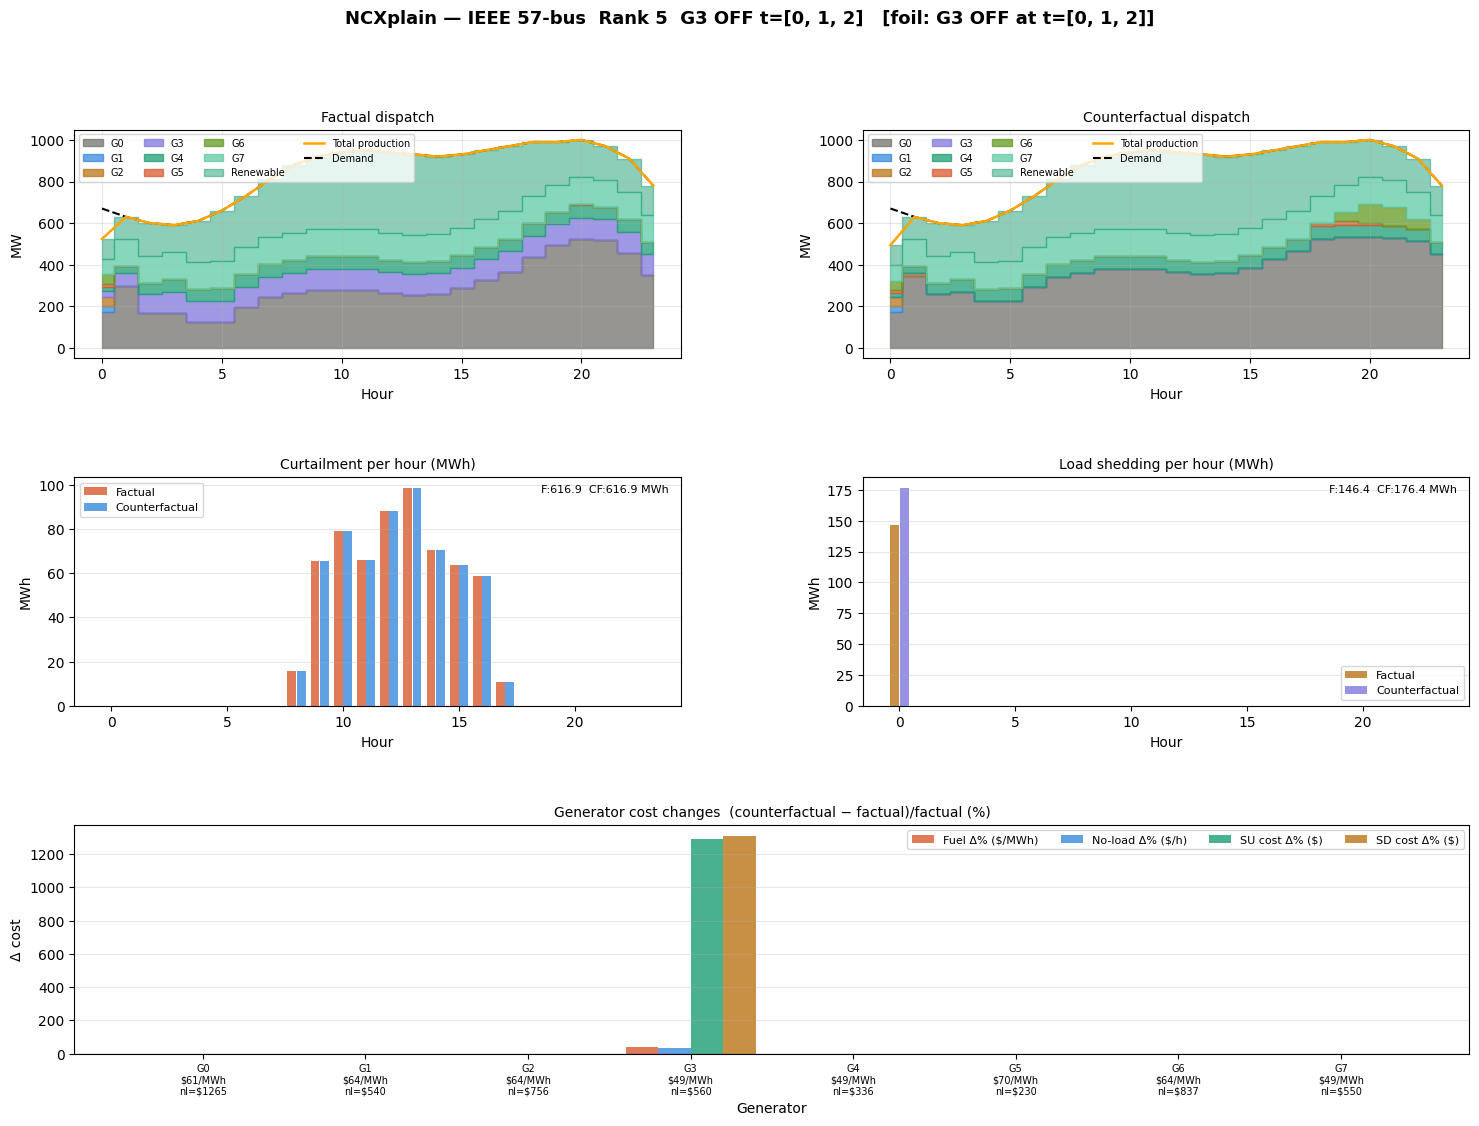

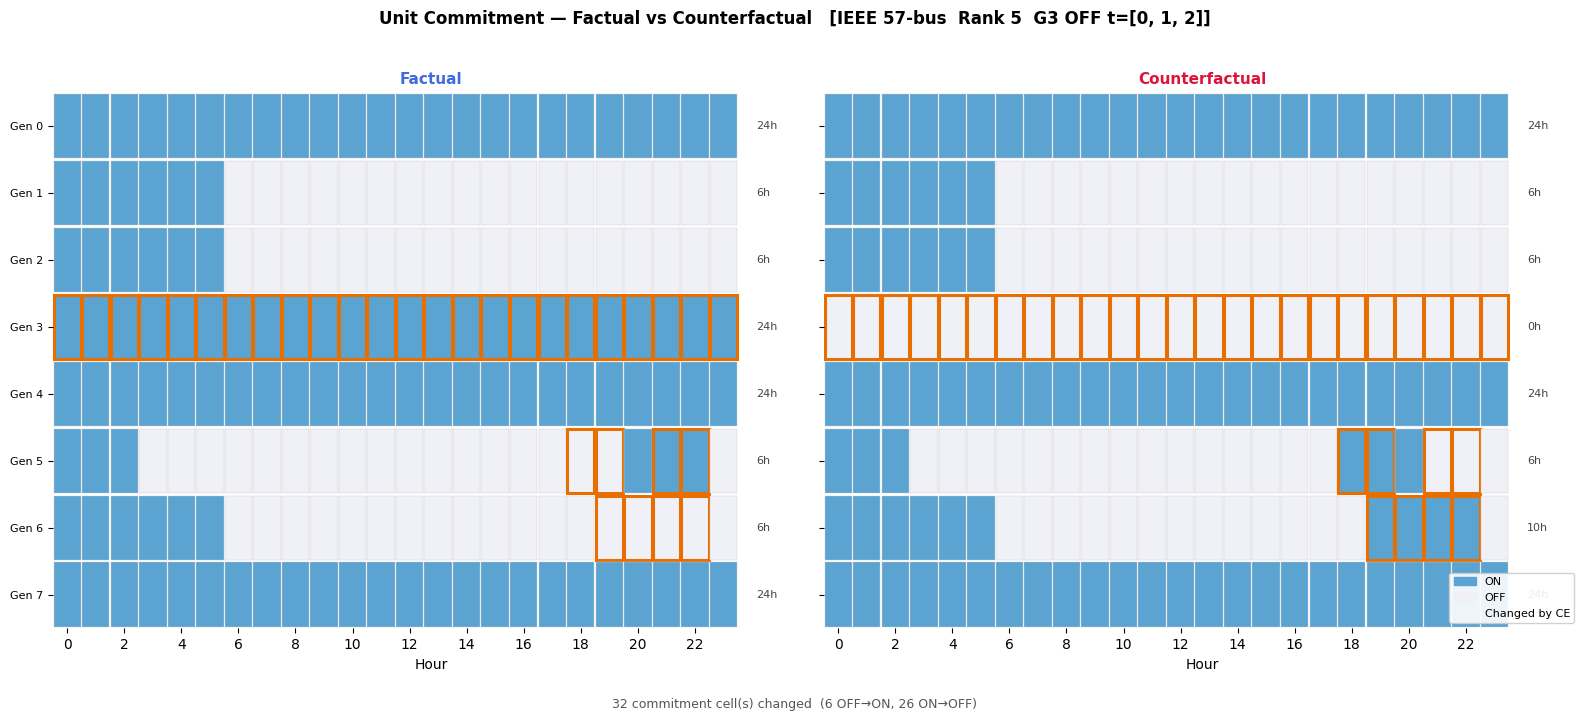


IEEE 57-bus  Rank 5  G3 OFF t=[0, 1, 2] — cost changes:
    G   orig_fuel     Δfuel   orig_nlod    Δno-load         ΔSU         ΔSD
    3       49.00     39.82      560.00       34.71     1289.32     1310.48

Rank 6  G3 OFF t=[0, 1, 2, 3]  gap=600773
[NCX it=01] gap=551421 | stop_tol=3.86 | MP_obj=1501.93 | foil_cost=4411383.51 | opt_cost=3859962.46
[NCX it=02] gap=31556.1 | stop_tol=4.26 | MP_obj=471464 | foil_cost=4288425.53 | opt_cost=4256869.42
[NCX it=03] gap=-1.39698e-07 | stop_tol=4.41 | MP_obj=501027 | foil_cost=4409022.97 | opt_cost=4409022.97
  → status: OPTIMAL

IEEE 57-bus — output keys: ['status', 'iters', 'mutables', 'bounds', 'weights', 'z_foil', 'z_opt', 'dTx_foil', 'dTx_opt', 'gap', 'stop_tol', 'mp_details', 'sol_factual', 'sol_foil', 'sol_opt', 'pi_plus_new', 'pi_minus_new', 'curt_cost_new', 'fuel_cost_new', 'no_load_cost_new', 'su_cost_new', 'sd_cost_new']


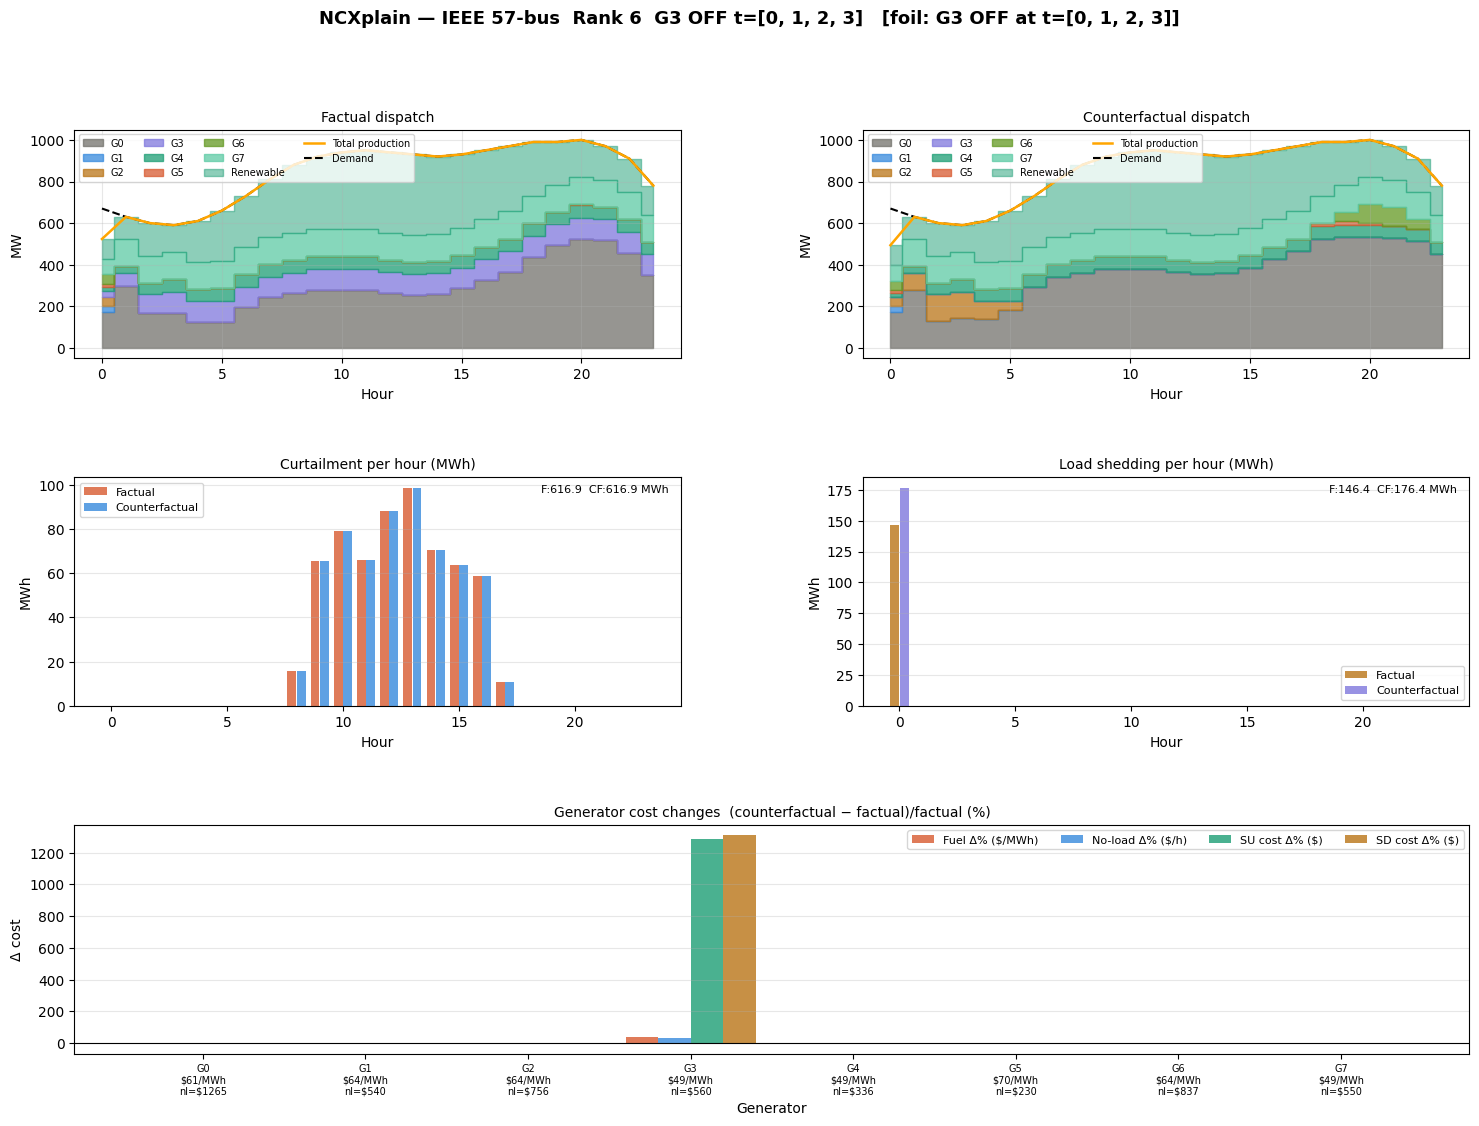

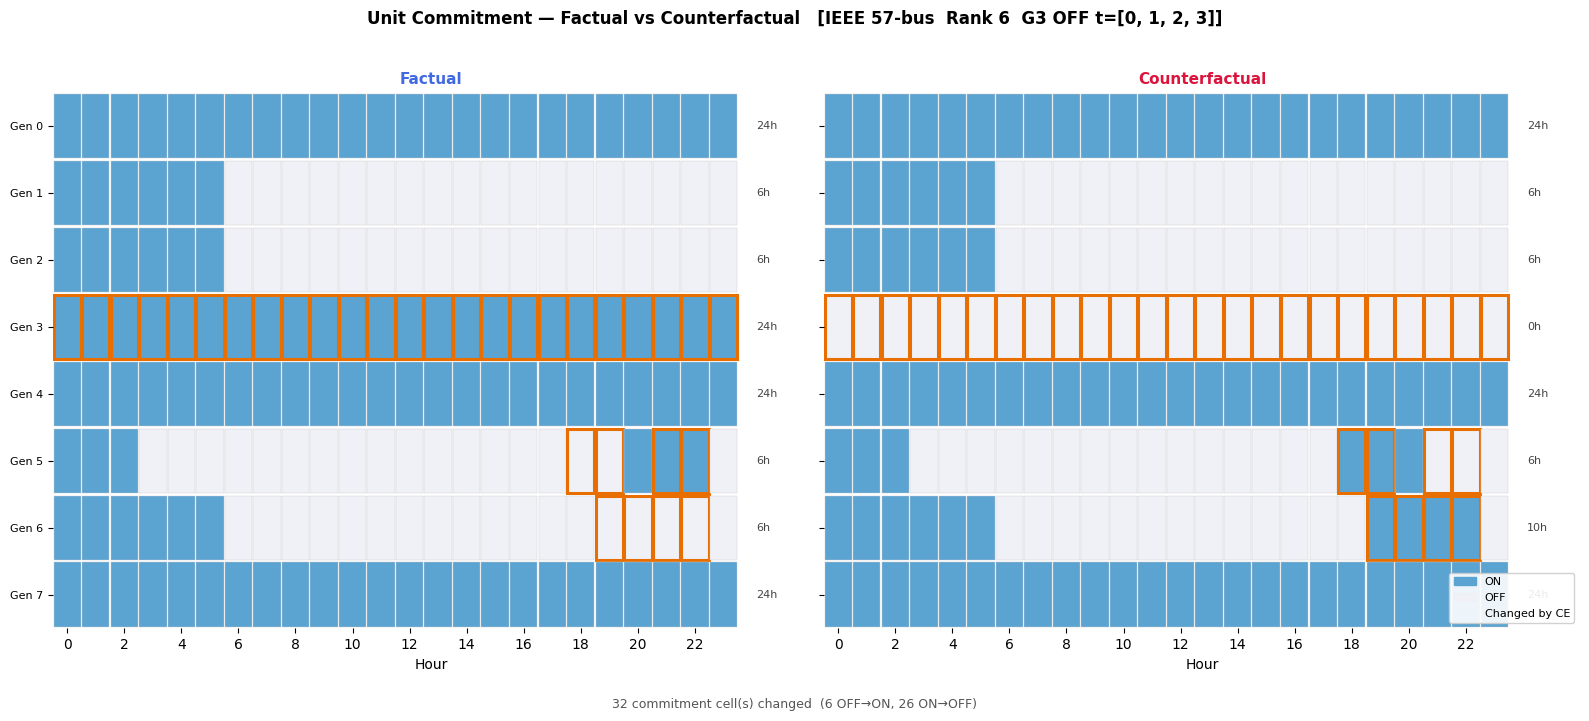


IEEE 57-bus  Rank 6  G3 OFF t=[0, 1, 2, 3] — cost changes:
    G   orig_fuel     Δfuel   orig_nlod    Δno-load         ΔSU         ΔSD
    2       63.70     -0.11      756.00        0.00        0.00        0.00
    3       49.00     39.82      560.00       34.71     1289.32     1310.48

Rank 7  G3 OFF t=[0, 1, 2, 3, 4]  gap=601413
[NCX it=01] gap=560394 | stop_tol=3.85 | MP_obj=1202.83 | foil_cost=4411383.51 | opt_cost=3850989.27
[NCX it=02] gap=31556.1 | stop_tol=4.26 | MP_obj=471464 | foil_cost=4288425.53 | opt_cost=4256869.42
[NCX it=03] gap=1.2666e-07 | stop_tol=4.41 | MP_obj=501027 | foil_cost=4409022.97 | opt_cost=4409022.97
  → status: OPTIMAL

IEEE 57-bus — output keys: ['status', 'iters', 'mutables', 'bounds', 'weights', 'z_foil', 'z_opt', 'dTx_foil', 'dTx_opt', 'gap', 'stop_tol', 'mp_details', 'sol_factual', 'sol_foil', 'sol_opt', 'pi_plus_new', 'pi_minus_new', 'curt_cost_new', 'fuel_cost_new', 'no_load_cost_new', 'su_cost_new', 'sd_cost_new']


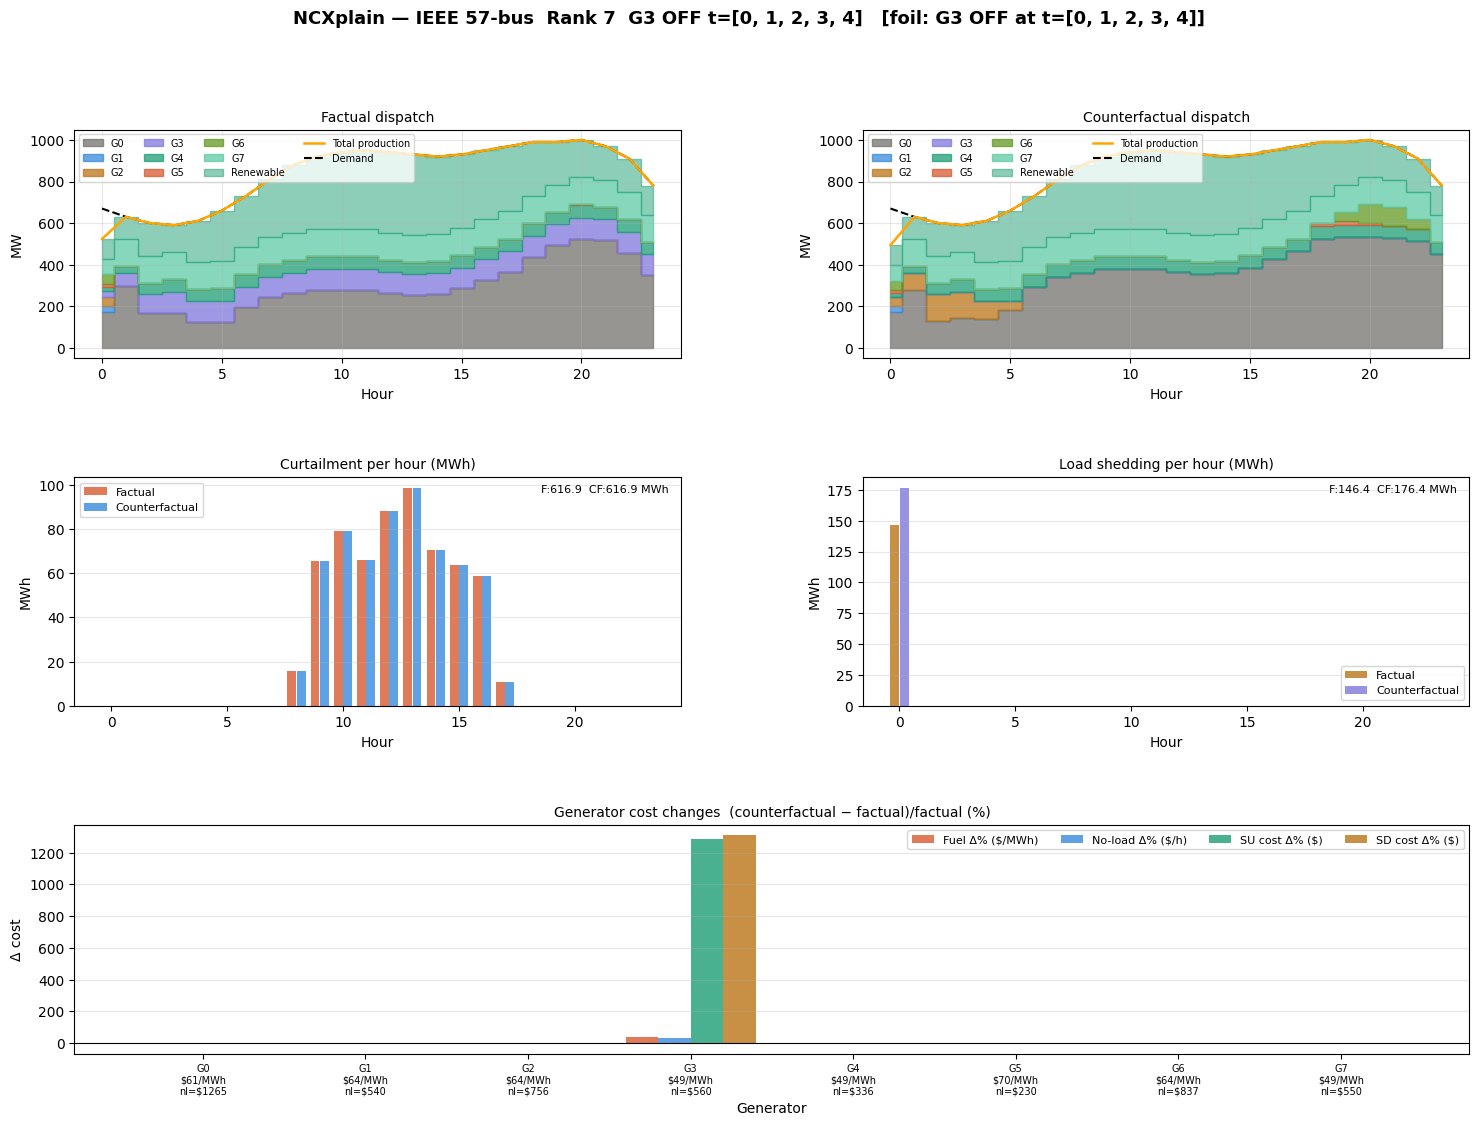

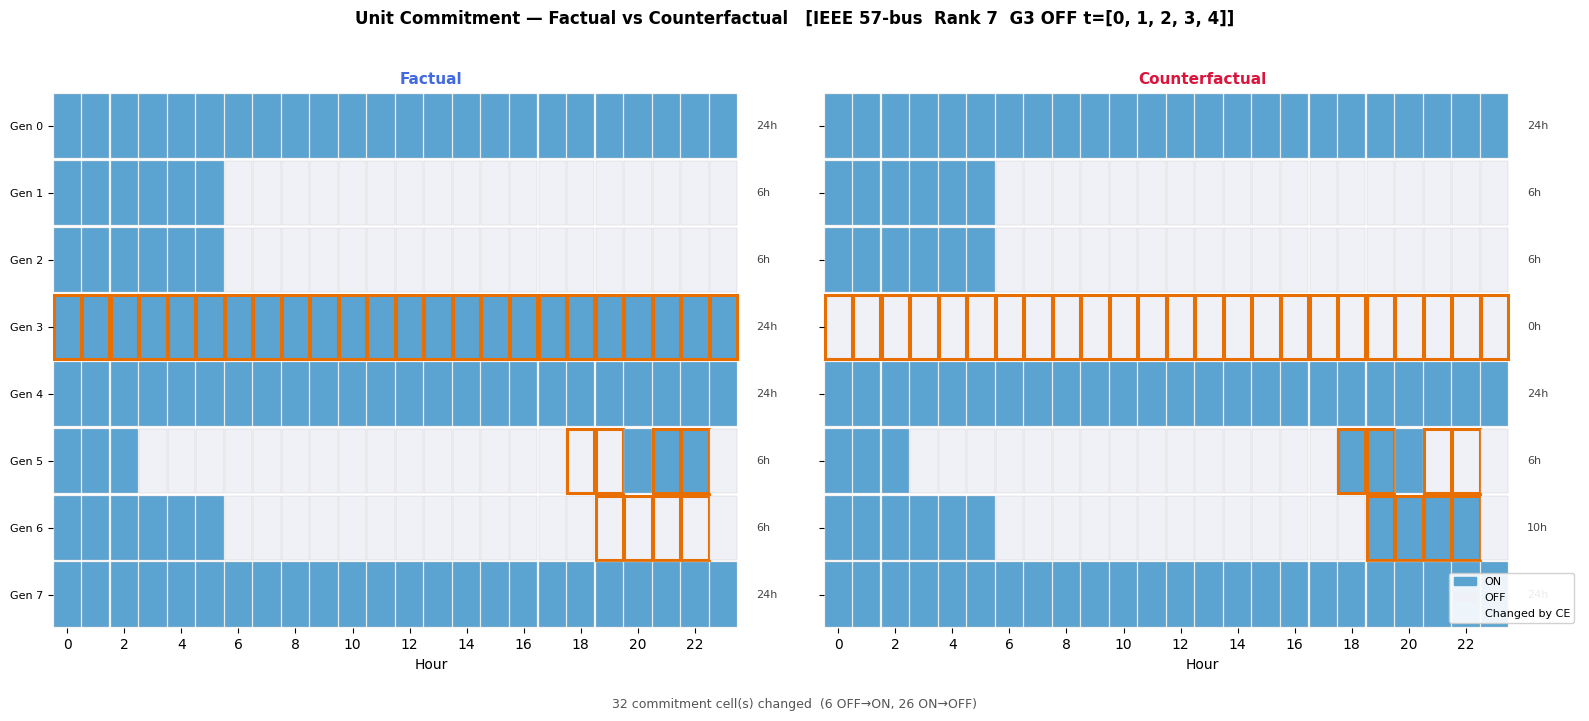


IEEE 57-bus  Rank 7  G3 OFF t=[0, 1, 2, 3, 4] — cost changes:
    G   orig_fuel     Δfuel   orig_nlod    Δno-load         ΔSU         ΔSD
    2       63.70     -0.11      756.00        0.00        0.00        0.00
    3       49.00     39.82      560.00       34.71     1289.32     1310.48

Rank 8  G2 OFF t=[0, 1, 2, 3, 4, 5]  gap=832067
[NCX it=01] gap=40000 | stop_tol=4.59 | MP_obj=656458 | foil_cost=4626448.76 | opt_cost=4586448.76
[NCX it=02] gap=3.63216e-08 | stop_tol=4.63 | MP_obj=656458 | foil_cost=4626448.76 | opt_cost=4626448.76
  → status: OPTIMAL

IEEE 57-bus — output keys: ['status', 'iters', 'mutables', 'bounds', 'weights', 'z_foil', 'z_opt', 'dTx_foil', 'dTx_opt', 'gap', 'stop_tol', 'mp_details', 'sol_factual', 'sol_foil', 'sol_opt', 'pi_plus_new', 'pi_minus_new', 'curt_cost_new', 'fuel_cost_new', 'no_load_cost_new', 'su_cost_new', 'sd_cost_new']


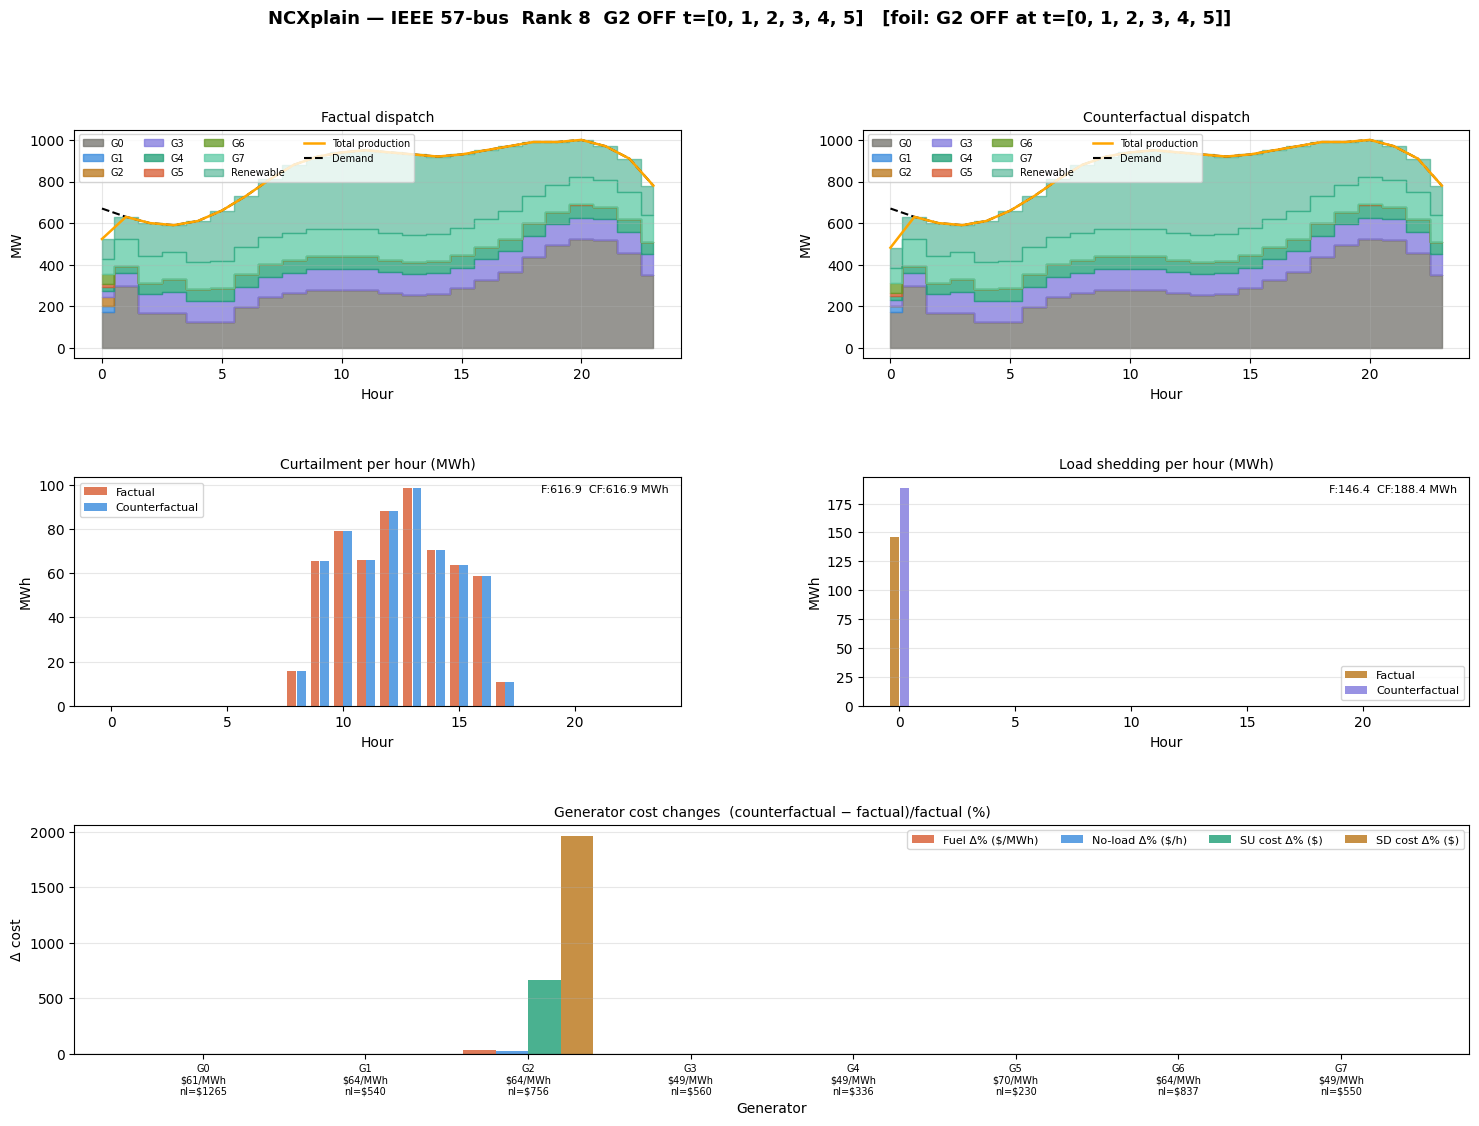

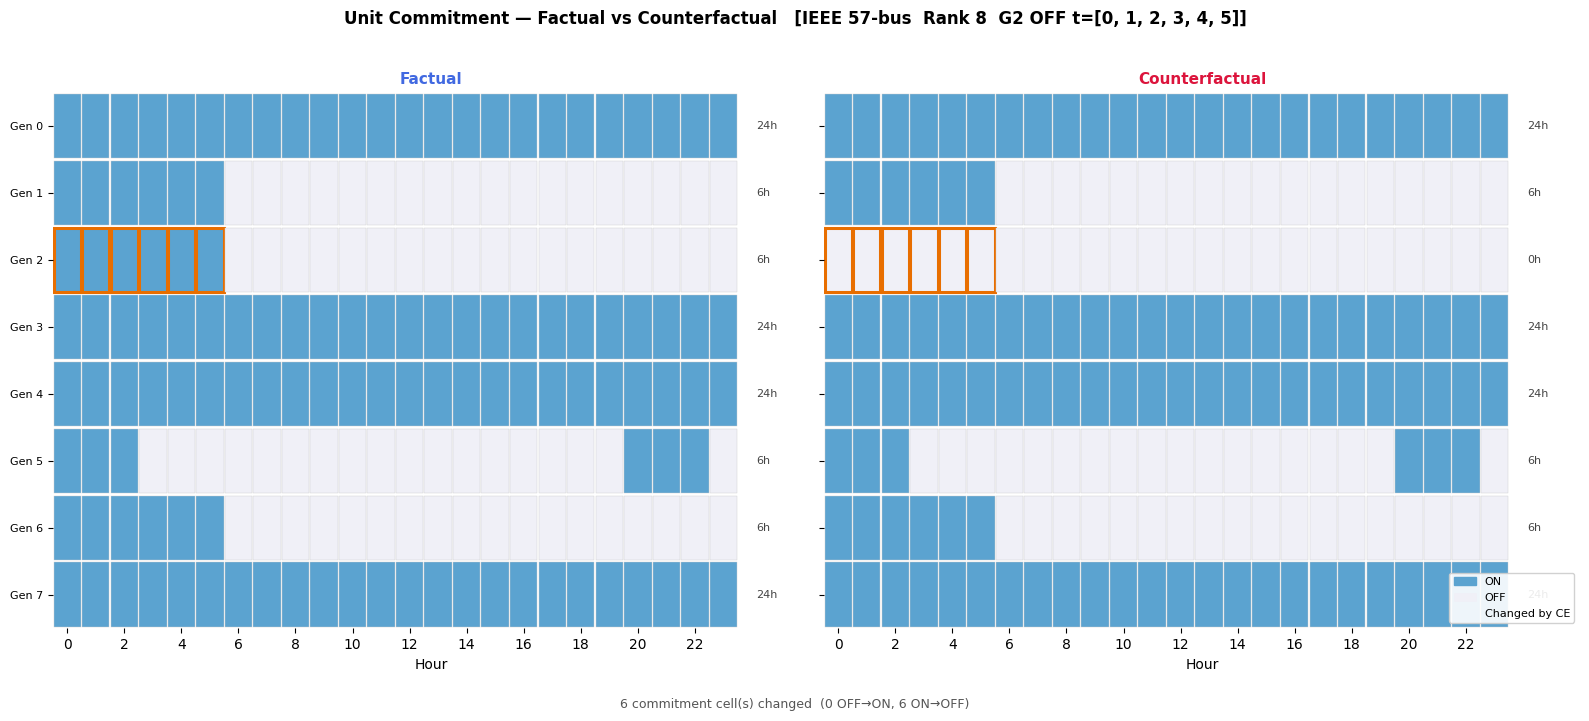


IEEE 57-bus  Rank 8  G2 OFF t=[0, 1, 2, 3, 4, 5] — cost changes:
    G   orig_fuel     Δfuel   orig_nlod    Δno-load         ΔSU         ΔSD
    2       63.70     30.40      756.00       25.46      663.45     1965.67

Rank 9  G6 OFF t=[0, 1, 2, 3, 4, 5]  gap=911249
[NCX it=01] gap=40000 | stop_tol=4.67 | MP_obj=728300 | foil_cost=4705630.96 | opt_cost=4665630.96
[NCX it=02] gap=7.17118e-08 | stop_tol=4.71 | MP_obj=728300 | foil_cost=4705630.96 | opt_cost=4705630.96
  → status: OPTIMAL

IEEE 57-bus — output keys: ['status', 'iters', 'mutables', 'bounds', 'weights', 'z_foil', 'z_opt', 'dTx_foil', 'dTx_opt', 'gap', 'stop_tol', 'mp_details', 'sol_factual', 'sol_foil', 'sol_opt', 'pi_plus_new', 'pi_minus_new', 'curt_cost_new', 'fuel_cost_new', 'no_load_cost_new', 'su_cost_new', 'sd_cost_new']


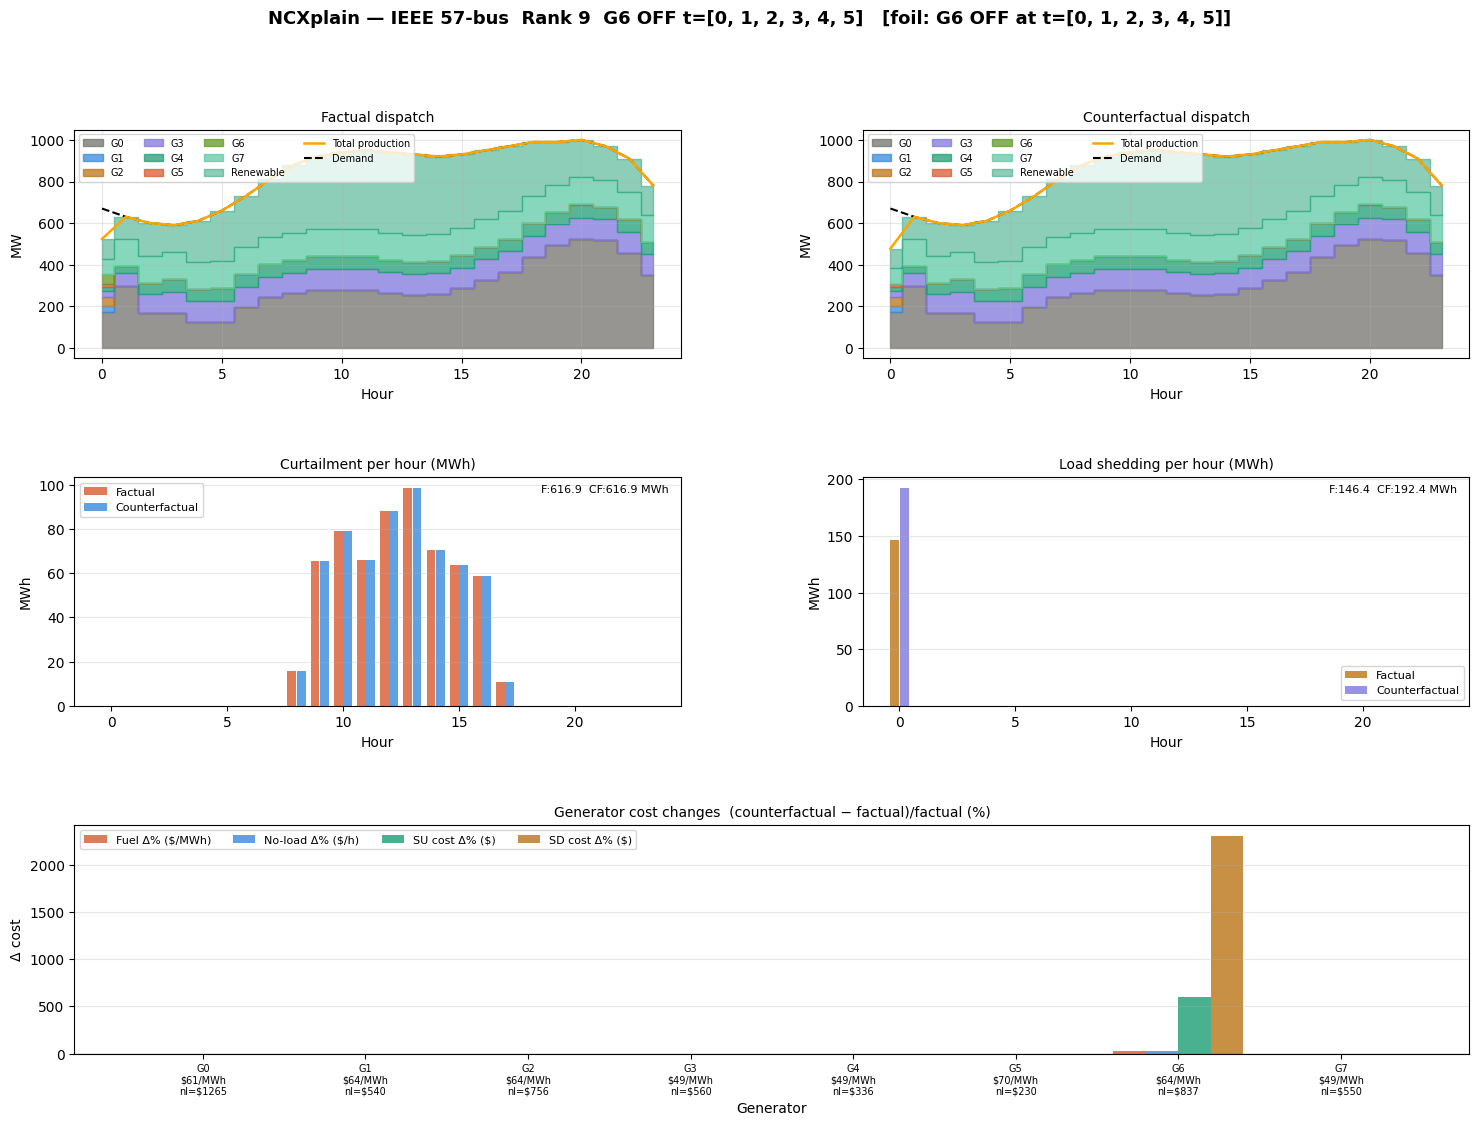

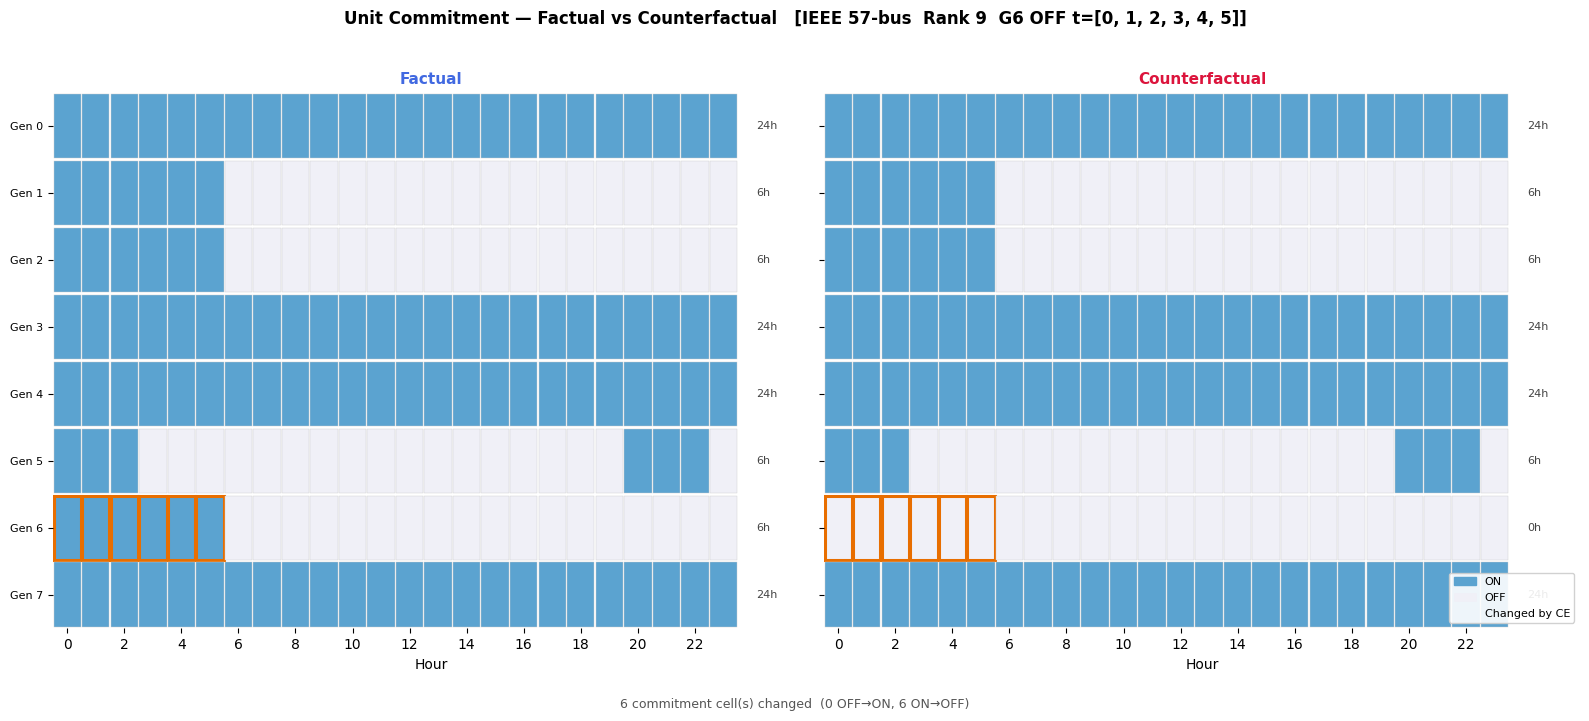


IEEE 57-bus  Rank 9  G6 OFF t=[0, 1, 2, 3, 4, 5] — cost changes:
    G   orig_fuel     Δfuel   orig_nlod    Δno-load         ΔSU         ΔSD
    6       63.70     30.40      837.00       22.89      599.60     2314.79

Rank 10  G7 OFF t=[0, 1, 2, 3]  gap=1499697
[NCX it=01] gap=1.27482e+06 | stop_tol=4.05 | MP_obj=2884.03 | foil_cost=5328664.47 | opt_cost=4053841.86
[NCX it=02] gap=-11.9653 | stop_tol=5.33 | MP_obj=1.0804e+06 | foil_cost=5328664.47 | opt_cost=5328676.43
  → status: OPTIMAL

IEEE 57-bus — output keys: ['status', 'iters', 'mutables', 'bounds', 'weights', 'z_foil', 'z_opt', 'dTx_foil', 'dTx_opt', 'gap', 'stop_tol', 'mp_details', 'sol_factual', 'sol_foil', 'sol_opt', 'pi_plus_new', 'pi_minus_new', 'curt_cost_new', 'fuel_cost_new', 'no_load_cost_new', 'su_cost_new', 'sd_cost_new']


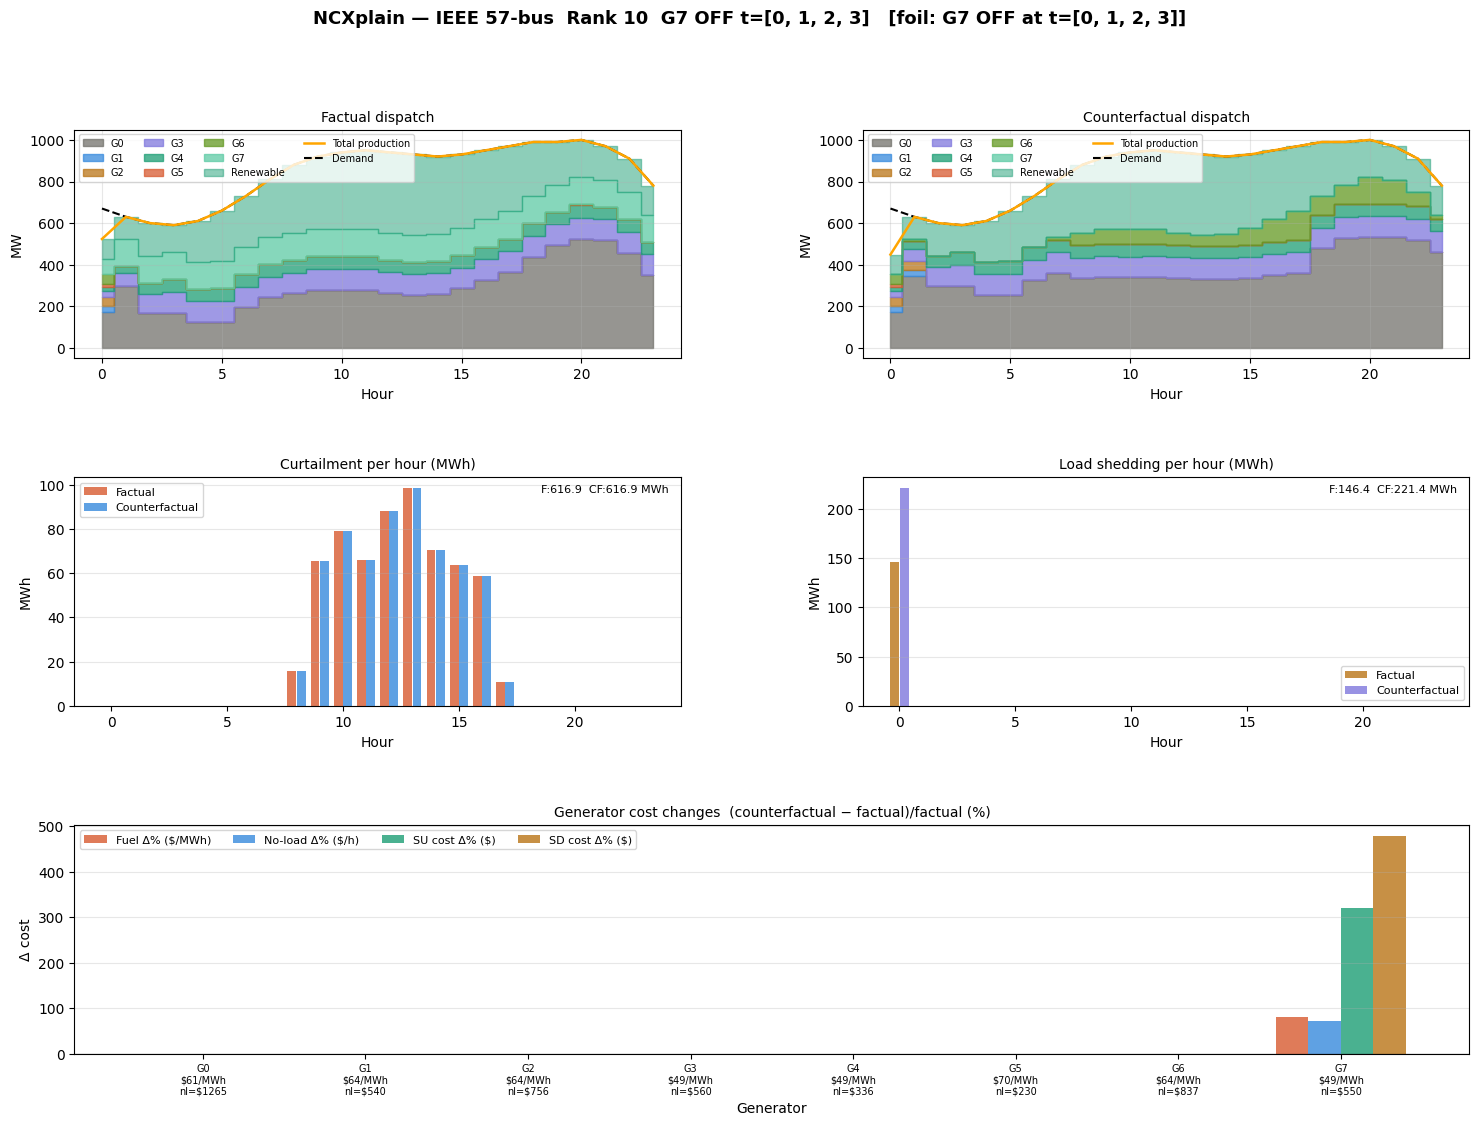

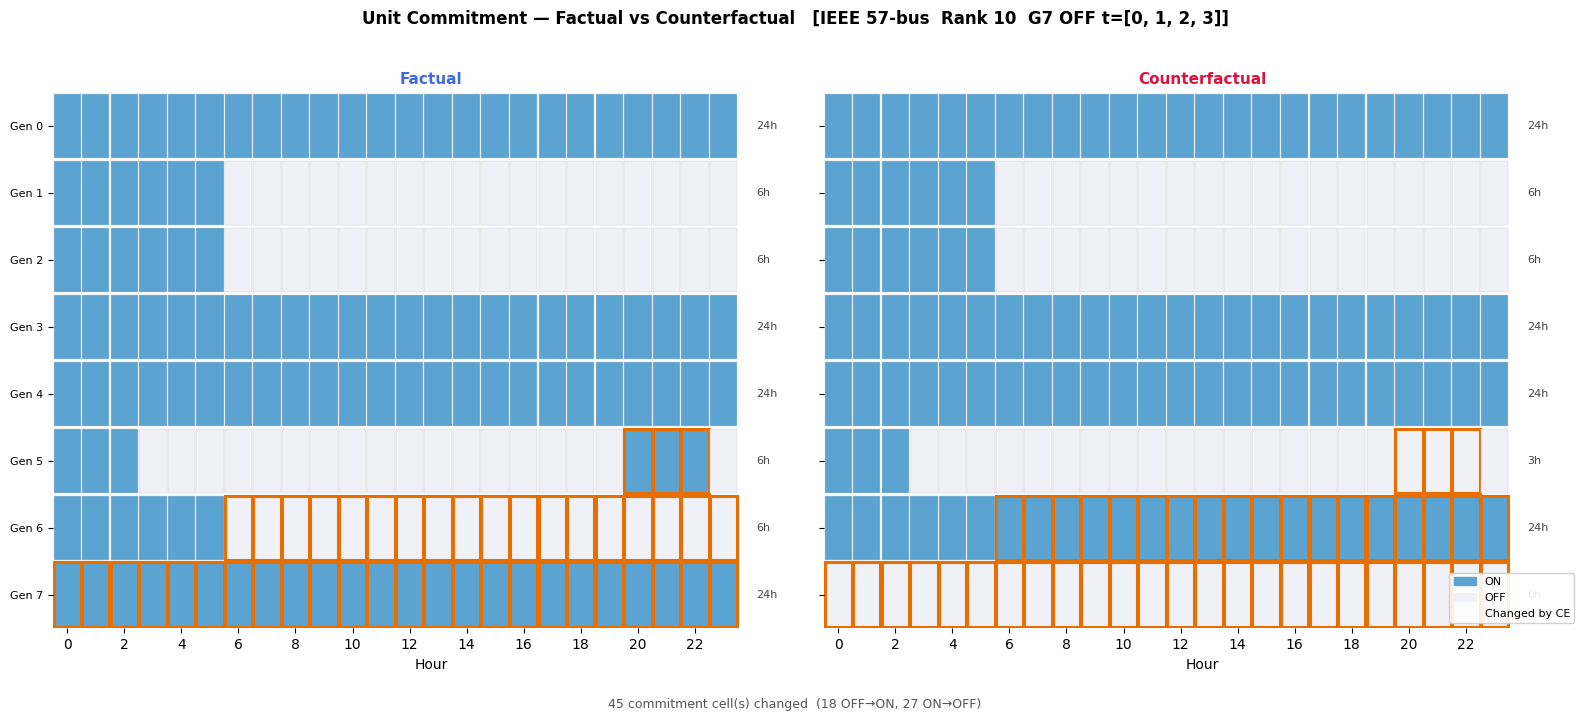


IEEE 57-bus  Rank 10  G7 OFF t=[0, 1, 2, 3] — cost changes:
    G   orig_fuel     Δfuel   orig_nlod    Δno-load         ΔSU         ΔSD
    7       49.00     80.63      550.00       71.73      319.00      479.00

Rank 11  G7 OFF t=[0, 1, 2, 3, 4]  gap=1500707
[NCX it=01] gap=1.31797e+06 | stop_tol=4.01 | MP_obj=2308.78 | foil_cost=5328664.47 | opt_cost=4010697.92
[NCX it=02] gap=5.7742e-08 | stop_tol=5.33 | MP_obj=1.0804e+06 | foil_cost=5328676.43 | opt_cost=5328676.43
  → status: OPTIMAL

IEEE 57-bus — output keys: ['status', 'iters', 'mutables', 'bounds', 'weights', 'z_foil', 'z_opt', 'dTx_foil', 'dTx_opt', 'gap', 'stop_tol', 'mp_details', 'sol_factual', 'sol_foil', 'sol_opt', 'pi_plus_new', 'pi_minus_new', 'curt_cost_new', 'fuel_cost_new', 'no_load_cost_new', 'su_cost_new', 'sd_cost_new']


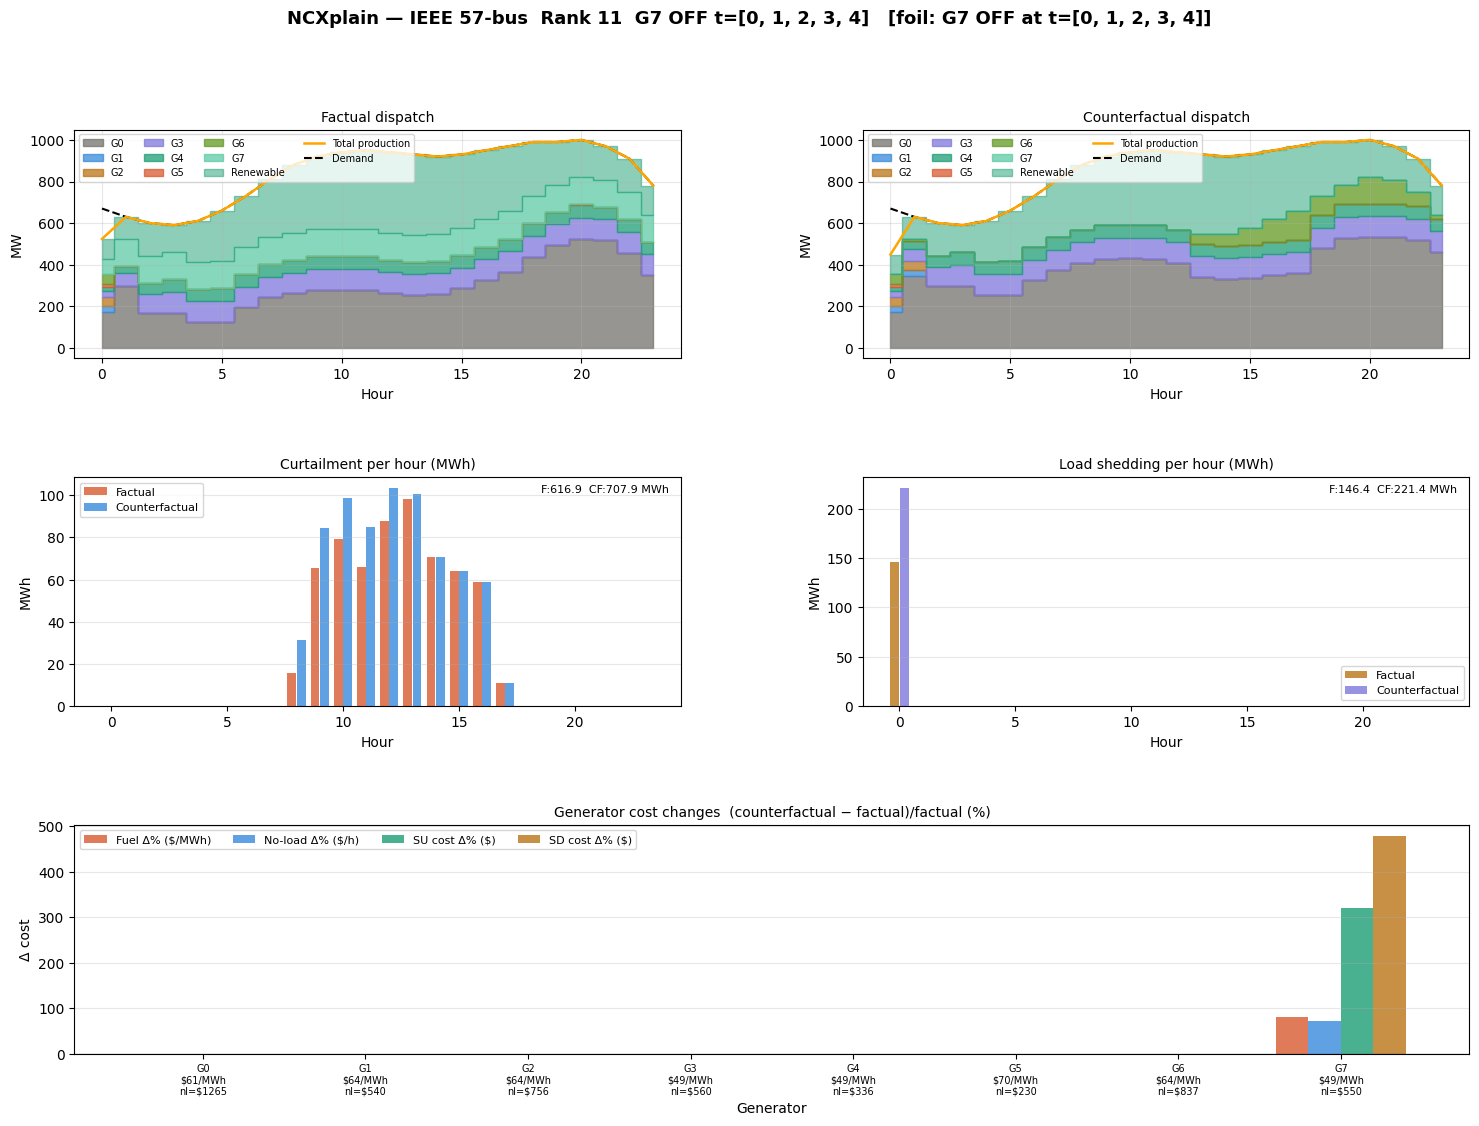

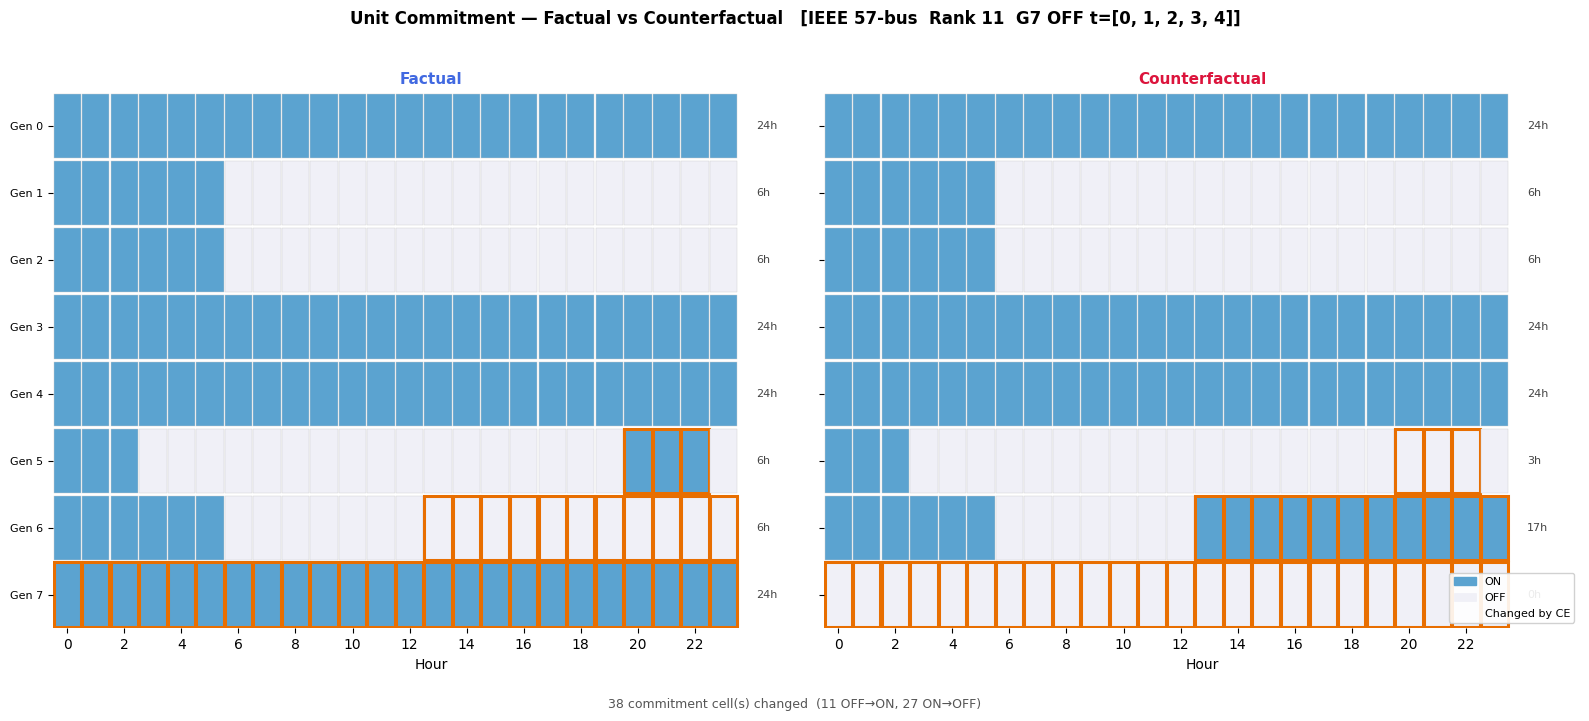


IEEE 57-bus  Rank 11  G7 OFF t=[0, 1, 2, 3, 4] — cost changes:
    G   orig_fuel     Δfuel   orig_nlod    Δno-load         ΔSU         ΔSD
    7       49.00     80.63      550.00       71.73      319.00      479.00

Rank 12  G7 OFF t=[0, 1, 2, 3, 4, 5]  gap=1501717
[NCX it=01] gap=1.34674e+06 | stop_tol=3.98 | MP_obj=1925.28 | foil_cost=5328676.43 | opt_cost=3981935.29
[NCX it=02] gap=877269 | stop_tol=4.52 | MP_obj=485292 | foil_cost=5400158.38 | opt_cost=4522889.83
[NCX it=03] gap=1.08743e+06 | stop_tol=3.48 | MP_obj=31605.3 | foil_cost=4568269.73 | opt_cost=3480840.85
[NCX it=04] gap=250699 | stop_tol=10 | MP_obj=844477 | foil_cost=10269335.99 | opt_cost=10018636.61
[NCX it=05] gap=-0.00016199 | stop_tol=5.11 | MP_obj=1.08042e+06 | foil_cost=5105126.27 | opt_cost=5105126.27
  → status: OPTIMAL

IEEE 57-bus — output keys: ['status', 'iters', 'mutables', 'bounds', 'weights', 'z_foil', 'z_opt', 'dTx_foil', 'dTx_opt', 'gap', 'stop_tol', 'mp_details', 'sol_factual', 'sol_foil', 'sol_opt

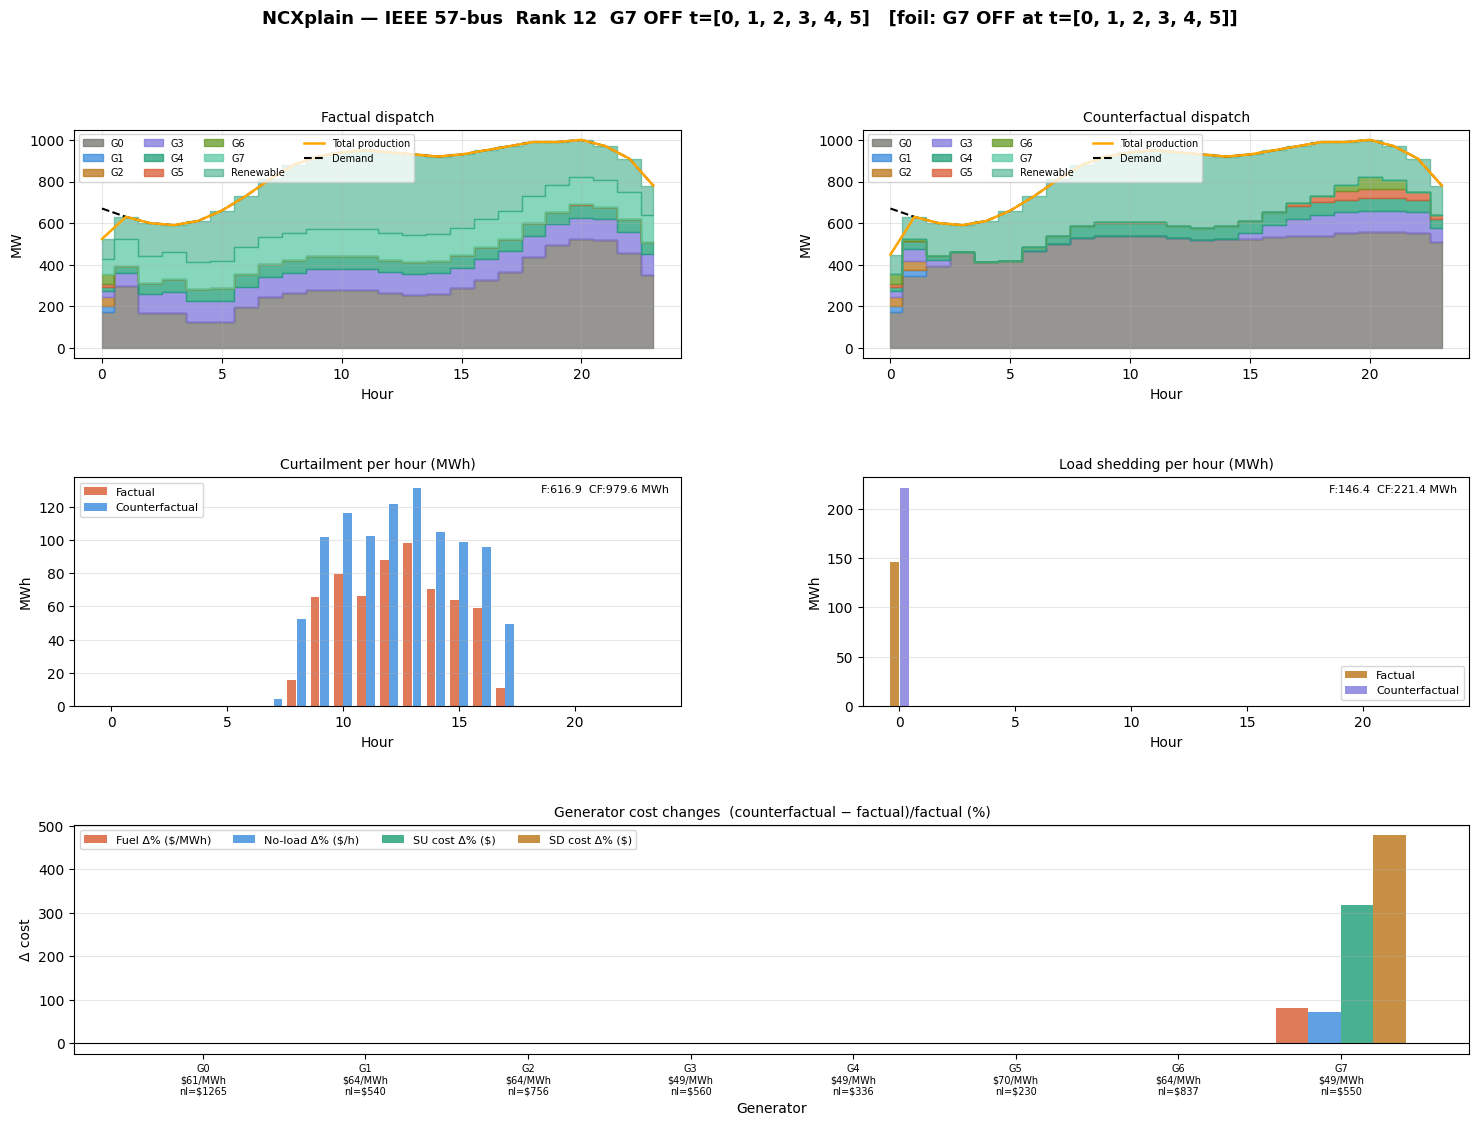

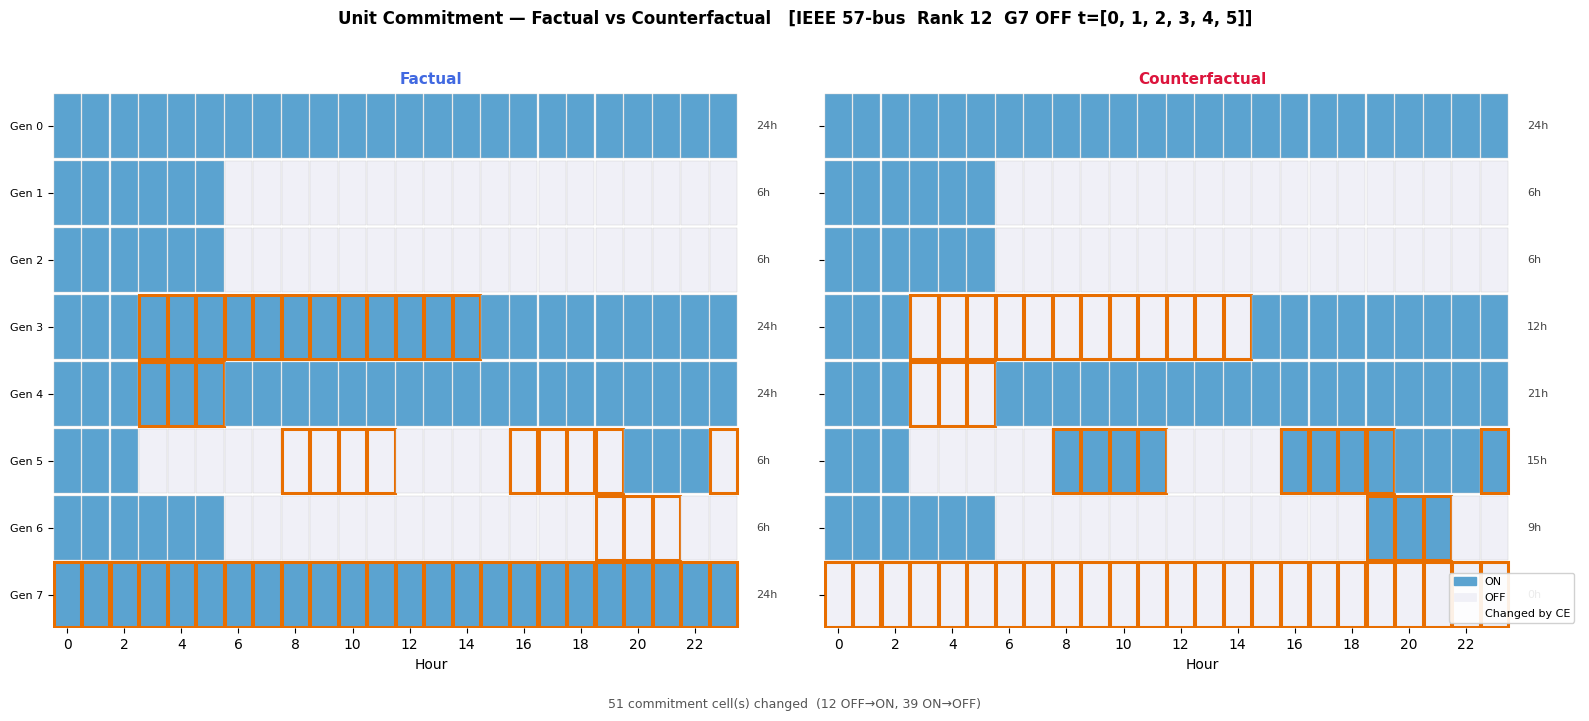


IEEE 57-bus  Rank 12  G7 OFF t=[0, 1, 2, 3, 4, 5] — cost changes:
    G   orig_fuel     Δfuel   orig_nlod    Δno-load         ΔSU         ΔSD
    0       61.00     -0.35     1265.00        0.00        0.00        0.00
    7       49.00     80.63      550.00       71.73      319.00      479.00

Rank 13  G0 OFF t=[0, 1, 2, 3, 4, 5, 6, 7]  gap=4103704
[NCX it=01] gap=3.60749e+06 | stop_tol=4.84 | MP_obj=2325.31 | foil_cost=8446106.34 | opt_cost=4838614.68
[NCX it=02] gap=2.53347e+06 | stop_tol=29 | MP_obj=89200.1 | foil_cost=31575009.11 | opt_cost=29041543.60
[NCX it=03] gap=1.66733e+06 | stop_tol=22.9 | MP_obj=692562 | foil_cost=24590164.11 | opt_cost=22922838.06
[NCX it=04] gap=1.2861e+06 | stop_tol=60.4 | MP_obj=888990 | foil_cost=61698262.47 | opt_cost=60412162.14
[NCX it=05] gap=3.37775e+06 | stop_tol=8.98 | MP_obj=7489.56 | foil_cost=12355052.62 | opt_cost=8977299.85
[NCX it=06] gap=1.12433e+06 | stop_tol=25.8 | MP_obj=1.36176e+06 | foil_cost=26933819.01 | opt_cost=25809484.25
  → 

In [19]:
# ── Cell: run NCXplain for all good 57-bus foil candidates ────────────────

assert candidates_57, "Run Section 2 first for IEEE 57-bus"

results_57 = []
for rank, (gap, foil_g, foil_times, foil_type) in enumerate(candidates_57):
    foil_fn = foil_force_off(foil_g, foil_times) if foil_type == "OFF" \
              else foil_force_on(foil_g, foil_times)

    print(f"\n{'='*60}")
    print(f"Rank {rank}  G{foil_g} {foil_type} t={foil_times}  gap={gap:.0f}")
    print(f"{'='*60}")

    out = run_ncxplain_uc(
        data=DATA_57,
        window_size=int(DATA_57.T),
        per_bus_neutrality=True,
        foil_fn=foil_fn,
        mutables={"gen_costs"},
        bounds={"fuel":    (0, 500),
                "no_load": (0, 5000),
                "su":      (0, 100_000),
                "sd":      (0, 100_000)},
        perturbation_beta=None,
        weights={"gen_costs": 1.0},
        verbose=True,
    )

    results_57.append({
        "rank": rank, "gap": gap,
        "foil_g": foil_g, "foil_times": foil_times, "foil_type": foil_type,
        "status": out["status"], "out": out,
    })
    print(f"  → status: {out['status']}")

    if str(out.get("status", "")).upper() == "OPTIMAL":
        print(f"\nIEEE 57-bus — output keys: {list(out.keys())}")
        plot_ncxplain_results(
            DATA_57, out, label=f"IEEE 57-bus  Rank {rank}  G{foil_g} {foil_type} t={foil_times}",
            foil_g=foil_g, foil_times=foil_times, foil_type=foil_type,
        )

# ── summary ───────────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"IEEE 57-bus  NCXplain summary  ({len(results_57)} foils)")
print(f"{'='*60}")
for r in results_57:
    print(f"  Rank {r['rank']}  G{r['foil_g']} {r['foil_type']}"
          f"  t={r['foil_times']}  gap={r['gap']:.0f}  →  {r['status']}")

---
## Section 4 · Cross-grid comparison


In [20]:
print(f"{'Grid':<18} {'Foil':>24} {'Gap ($)':>12} {'#Flex gens':>12} {'Status':>12}")
print(chr(9472)*82)
for lbl, key, cands_var, out_var in [
    ("IEEE 14-bus",    "14",  candidates_14,  out_14),
    ("IEEE 39-bus",    "39",  candidates_39,  out_39),
    ("IEEE 57-bus",    "57",  candidates_57,  out_57),
]:
    foil_str = f"G{cands_var[0][1]} t={cands_var[0][2]}" if cands_var else "none"
    gap_str  = f"{cands_var[0][0]:.0f}" if cands_var else "—"
    nflex    = len([g for g,gen in enumerate(eval(f"DATA_{key}").gens)
                    if gen.UT<=1 and gen.DT<=1])
    status   = out_var.get("status","—") if out_var else "—"
    print(f"{lbl:<18} {foil_str:>24} {gap_str:>12} {nflex:>12} {status:>12}")


Grid                                   Foil      Gap ($)   #Flex gens       Status
──────────────────────────────────────────────────────────────────────────────────


NameError: name 'out_14' is not defined